# LLM Assistance Disclaimer

Parts of this code were developed with assistance from Large Language Models (specifically GitHub Copilot).
The models helped with implementation details, code structure, and documentation.
While the core ideas and algorithms are based on established research, the LLM assistance
improved code/documentation quality.

## Imports and Setup

In [1]:
# Core imports and configuration
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, ConcatDataset, Subset, TensorDataset
from tqdm import tqdm

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision.utils import make_grid
import torchvision.transforms.functional as F

# MedMNIST
import medmnist
from medmnist import INFO, Evaluator

# Additional imports for DCGAN and FID
import torch.nn.functional as F
from scipy import linalg
from torchvision.models import inception_v3
import random
from sklearn.model_selection import ParameterGrid

import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

# Configuration
DATA_FLAG = 'bloodmnist'
BATCH_SIZE = 128
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Initial seed for hyperparameter tuning
INITIAL_SEED = 42
set_seed(INITIAL_SEED)

print(f"MedMNIST v{medmnist.__version__} @ {medmnist.HOMEPAGE}")
print(f"Using device: {DEVICE}")

MedMNIST v3.0.2 @ https://github.com/MedMNIST/MedMNIST/
Using device: cuda


## Dataset Information and Classes

In [2]:
# Get dataset information
info = INFO[DATA_FLAG]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

# Blood cell type mapping
CELL_TYPES = {
    0: 'Basophil',
    1: 'Eosinophil',
    2: 'Erythroblast',
    3: 'Immature Granulocyte',
    4: 'Lymphocyte',
    5: 'Monocyte',
    6: 'Neutrophil',
    7: 'Platelet'
}

print(f"Dataset: {DATA_FLAG}")
print(f"Task: {task}")
print(f"Number of channels: {n_channels}")
print(f"Number of classes: {n_classes}")
print(f"Image dimensions: 28x28x{n_channels}")
print("\nCell Types:")
for idx, cell_type in CELL_TYPES.items():
    print(f"  {idx}: {cell_type}")

Dataset: bloodmnist
Task: multi-class
Number of channels: 3
Number of classes: 8
Image dimensions: 28x28x3

Cell Types:
  0: Basophil
  1: Eosinophil
  2: Erythroblast
  3: Immature Granulocyte
  4: Lymphocyte
  5: Monocyte
  6: Neutrophil
  7: Platelet


## Data Loading and Preprocessing

In [3]:
# Data preprocessing transforms
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

# Load dataset splits
DataClass = getattr(medmnist, info['python_class'])

train_dataset = DataClass(split='train', transform=data_transform, download=True)
val_dataset = DataClass(split='val', transform=data_transform, download=True)
test_dataset = DataClass(split='test', transform=data_transform, download=True)

# Combine all splits for generative modeling
full_dataset = ConcatDataset([train_dataset, val_dataset, test_dataset])

# Create dataloader
dataloader = DataLoader(
    full_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"Train set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")
print(f"Total dataset size: {len(full_dataset)}")
print(f"Number of batches: {len(dataloader)}")

Using downloaded and verified file: <HOME>\.medmnist\bloodmnist.npz
Using downloaded and verified file: <HOME>\.medmnist\bloodmnist.npz
Using downloaded and verified file: <HOME>\.medmnist\bloodmnist.npz
Train set size: 11959
Validation set size: 1712
Test set size: 3421
Total dataset size: 17092
Number of batches: 134


## Dataset Analysis - Basic Statistics

In [4]:
# Collect all labels for analysis
all_labels = []
all_images = []

print("Collecting dataset statistics...")
for images, labels in tqdm(dataloader, desc="Processing batches"):
    all_labels.extend(labels.flatten().tolist())
    all_images.append(images)

# Convert to numpy for analysis
all_labels = np.array(all_labels)
all_images_tensor = torch.cat(all_images, dim=0)

print(f"\nDataset Statistics:")
print(f"Total samples: {len(all_labels)}")
print(f"Image tensor shape: {all_images_tensor.shape}")
print(f"Image value range: [{all_images_tensor.min():.3f}, {all_images_tensor.max():.3f}]")
print(f"Image mean: {all_images_tensor.mean():.3f}")
print(f"Image std: {all_images_tensor.std():.3f}")

Processing batches: 100%|██████████| 134/134 [00:15<00:00,  8.68it/s]


Dataset Statistics:
Total samples: 17092
Image tensor shape: torch.Size([17092, 3, 28, 28])
Image value range: [-2.036, 2.640]
Image mean: 1.183
Image std: 0.901


## Class Distribution Analysis

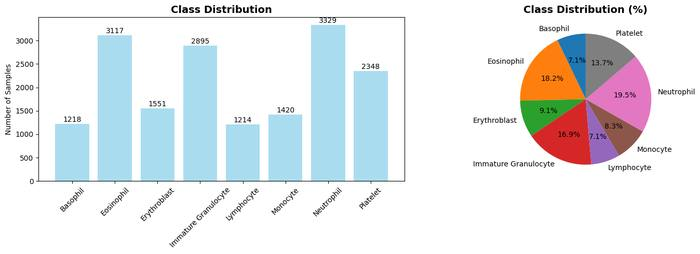


Detailed Class Distribution:
Basophil            :  1218 samples (  7.1%)
Eosinophil          :  3117 samples ( 18.2%)
Erythroblast        :  1551 samples (  9.1%)
Immature Granulocyte:  2895 samples ( 16.9%)
Lymphocyte          :  1214 samples (  7.1%)
Monocyte            :  1420 samples (  8.3%)
Neutrophil          :  3329 samples ( 19.5%)
Platelet            :  2348 samples ( 13.7%)

Class Imbalance Ratio: 2.74:1
Dataset shows significant class imbalance!


In [5]:
# Analyze class distribution
unique_labels, counts = np.unique(all_labels, return_counts=True)
class_distribution = dict(zip(unique_labels, counts))

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot
cell_names = [CELL_TYPES[i] for i in unique_labels]
bars = ax1.bar(cell_names, counts, color='skyblue', alpha=0.7)
ax1.set_title('Class Distribution', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Samples')
ax1.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, count in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(count), ha='center', va='bottom')

# Pie chart
ax2.pie(counts, labels=cell_names, autopct='%1.1f%%', startangle=90)
ax2.set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\nDetailed Class Distribution:")
for label, count in class_distribution.items():
    percentage = (count / len(all_labels)) * 100
    print(f"{CELL_TYPES[label]:20}: {count:5d} samples ({percentage:5.1f}%)")

# Check for class imbalance
max_count = max(counts)
min_count = min(counts)
imbalance_ratio = max_count / min_count
print(f"\nClass Imbalance Ratio: {imbalance_ratio:.2f}:1")
if imbalance_ratio > 2.0:
    print("Dataset shows significant class imbalance!")

### FID Score Implementation

In [ ]:
# Define a custom module that extracts features from InceptionV3
class InceptionV3Features(nn.Module):
    def __init__(self):
        super(InceptionV3Features, self).__init__()
        
        # Load the pretrained InceptionV3 model from torchvision
        inception = inception_v3(pretrained=True)

        # First block includes initial convolution layers and a max pool
        self.block1 = nn.Sequential(
            inception.Conv2d_1a_3x3, inception.Conv2d_2a_3x3,
            inception.Conv2d_2b_3x3,
            nn.MaxPool2d(kernel_size=3, stride=2)
        )

        # Second block continues with more convolutions and another max pool
        self.block2 = nn.Sequential(
            inception.Conv2d_3b_1x1, inception.Conv2d_4a_3x3,
            nn.MaxPool2d(kernel_size=3, stride=2)
        )

        # Third block includes the mixed layers from Inception's architecture
        self.block3 = nn.Sequential(
            inception.Mixed_5b, inception.Mixed_5c, inception.Mixed_5d,
            inception.Mixed_6a, inception.Mixed_6b, inception.Mixed_6c,
            inception.Mixed_6d, inception.Mixed_6e
        )

        # Final block finishes with the last mixed layers and a global average pooling
        self.block4 = nn.Sequential(
            inception.Mixed_7a, inception.Mixed_7b, inception.Mixed_7c,
            nn.AdaptiveAvgPool2d(output_size=(1, 1))
        )

    def forward(self, x):
        # Pass input through each block sequentially
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)

        # Flatten output to (batch_size, feature_dim)
        return x.view(x.size(0), -1)

# Computes mean and covariance of activations from a model
def calculate_activation_statistics(images, model, batch_size=128, dims=2048):
    """Calculate mean and covariance statistics of activations."""
    
    model.eval()  # Set model to evaluation mode
    act = np.empty((len(images), dims))  # Preallocate activation array

    # Process images in batches to save memory
    n_batches = len(images) // batch_size + 1
    for i in range(n_batches):
        start = i * batch_size
        end = min(len(images), start + batch_size)
        if start >= end:
            break

        # Clone batch to avoid modifying original data
        batch = images[start:end].clone()

        # Resize to the size expected by InceptionV3
        batch = F.interpolate(batch, size=(299, 299), mode='bilinear', align_corners=False)

        # Disable gradient tracking for inference
        with torch.no_grad():
            pred = model(batch.to(DEVICE))  # Move batch to the same device as the model

        # Store activations
        pred = pred.cpu().numpy()
        act[start:end] = pred

    # Compute mean and covariance across all activations
    mu = np.mean(act, axis=0)
    sigma = np.cov(act, rowvar=False)
    return mu, sigma

# Computes the Fréchet Inception Distance (FID) given two Gaussians
def calculate_frechet_distance(mu1, sigma1, mu2, sigma2, eps=1e-6):
    """Calculate Frechet Distance between two multivariate Gaussians with improved numerical stability."""
    
    mu1, mu2 = np.atleast_1d(mu1), np.atleast_1d(mu2)
    sigma1, sigma2 = np.atleast_2d(sigma1), np.atleast_2d(sigma2)

    # Check for invalid values in input (NaN or Inf)
    if not (np.isfinite(mu1).all() and np.isfinite(mu2).all() and 
            np.isfinite(sigma1).all() and np.isfinite(sigma2).all()):
        print("WARNING: Input to FID calculation contains NaN or Inf.")
        mu1 = np.nan_to_num(mu1)
        mu2 = np.nan_to_num(mu2)
        sigma1 = np.nan_to_num(sigma1)
        sigma2 = np.nan_to_num(sigma2)

    diff = mu1 - mu2

    # Add small offset to covariance matrices to ensure numerical stability
    offset = np.eye(sigma1.shape[0]) * eps
    sigma1 = sigma1 + offset
    sigma2 = sigma2 + offset

    # Try to compute sqrt of product of covariance matrices
    try:
        covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    except ValueError as e:
        print(f"FID calculation error: {e}")
        offset = np.eye(sigma1.shape[0]) * (eps * 10)
        covmean = linalg.sqrtm((sigma1 + offset).dot(sigma2 + offset))

    # If result has invalid values, retry with more regularization
    if not np.isfinite(covmean).all():
        print("FID calculation produced invalid covmean, adding regularization")
        offset = np.eye(sigma1.shape[0]) * eps
        covmean = linalg.sqrtm((sigma1 + offset).dot(sigma2 + offset))

    # Sometimes numerical errors cause small imaginary parts
    if np.iscomplexobj(covmean):
        if not np.allclose(np.diagonal(covmean).imag, 0, atol=1e-3):
            m = np.max(np.abs(covmean.imag))
            print(f"Imaginary component in covmean: {m}")
        covmean = covmean.real  # Use only the real part

    tr_covmean = np.trace(covmean)

    # Final FID formula
    return (diff.dot(diff) + np.trace(sigma1) + np.trace(sigma2) - 2 * tr_covmean)

# Wrapper to compute the FID score between real and fake image sets
def compute_fid(real_images, fake_images):
    """Compute FID between two sets of images."""

    # Load the modified InceptionV3 model to extract features
    inception_model = InceptionV3Features().to(DEVICE)
    inception_model.eval()

    # Calculate activation statistics for real and fake images
    mu_real, sigma_real = calculate_activation_statistics(real_images, inception_model)
    mu_fake, sigma_fake = calculate_activation_statistics(fake_images, inception_model)

    # Compute and return the final FID score
    fid_value = calculate_frechet_distance(mu_real, sigma_real, mu_fake, sigma_fake)
    return fid_value

### Sample Real Data Points

In [ ]:
def sample_real_data(dataset, n_samples=10000, seed=42):
    """Sample n_samples random data points from the dataset."""

    # Set the random seed for reproducibility
    np.random.seed(seed)

    # Randomly select unique indices from the dataset
    indices = np.random.choice(len(dataset), n_samples, replace=False)

    # Create a sampler to only load the selected indices
    sampler = data.SubsetRandomSampler(indices)

    # Create a DataLoader that will load the selected samples
    loader = data.DataLoader(
        dataset,
        batch_size=n_samples,  # Load everything in a single batch
        sampler=sampler,       # Use our custom sampler
        num_workers=4,         # Use multiple workers for speed
        pin_memory=True if torch.cuda.is_available() else False  # Speed up transfers to GPU
    )

    # Retrieve the first (and only) batch from the loader
    data_iter = iter(loader)
    images, _ = next(data_iter)  # We only need the images, not the labels

    return images  # Return the sampled image tensor

### Generate Samples and Compute FID

In [ ]:
def generate_samples(generator, n_samples=10000, latent_dim=100, batch_size=128, device=torch.device('cuda')):
    """Generate n_samples fake images using the generator."""

    generator.eval()  # Set generator to evaluation mode
    fake_images = []  # List to collect generated batches

    with torch.no_grad():  # Disable gradient tracking to save memory and computation
        for i in range(0, n_samples, batch_size):
            # Adjust batch size for the last iteration if needed
            batch_size_i = min(batch_size, n_samples - i)

            # Generate random latent vectors from a normal distribution
            noise = torch.randn(batch_size_i, latent_dim, 1, 1, device=device)

            # Generate fake images using the generator
            fake_batch = generator(noise)

            # Move to CPU and store
            fake_images.append(fake_batch.cpu())

    # Concatenate all batches into a single tensor
    fake_images = torch.cat(fake_images, dim=0)
    return fake_images

def evaluate_model(generator, real_samples, hyperparams):
    """Evaluate a trained generator by computing FID score."""

    # Generate fake images using the same number of real samples
    fake_samples = generate_samples(
        generator,
        n_samples=len(real_samples),               # Match number of real images
        latent_dim=hyperparams['latent_dim'],      # Get latent space size from hyperparameters
        device=DEVICE                              # Use the correct device (CPU or GPU)
    )

    # Compute FID score between real and generated images
    fid_score = compute_fid(real_samples, fake_samples)

    # Return the FID score and the generated images for possible future inspection
    return fid_score, fake_samples

## VAE - Variational Autoencoder

In [ ]:
class VAE(nn.Module):
    def __init__(self, hidden_dims=[512, 256], latent_dim=128, in_channels=3, img_size=28):
        """
        Variational Autoencoder for BloodMNIST
        
        Args:
            hidden_dims: List of hidden dimensions for the encoder and decoder
            latent_dim: Dimension of the latent space
            in_channels: Number of input channels (e.g., 3 for RGB images)
            img_size: Height/width of input images (assumes square images)
        """
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        self.img_size = img_size
        self.in_channels = in_channels

        # ------------------
        # Build Encoder
        # ------------------

        modules = []
        in_channels_current = in_channels

        # Create convolutional blocks for the encoder
        for h_dim in hidden_dims:
            modules.append(
                nn.Sequential(
                    nn.Conv2d(in_channels_current, h_dim, kernel_size=3, stride=2, padding=1),
                    nn.BatchNorm2d(h_dim),
                    nn.LeakyReLU()
                )
            )
            in_channels_current = h_dim

        self.encoder = nn.Sequential(*modules)

        # Compute the downscaled spatial resolution after all conv layers
        self.encoder_output_dim = self.img_size
        for _ in range(len(hidden_dims)):
            self.encoder_output_dim = self.encoder_output_dim // 2

        # Flattened dimension of the encoder output
        flattened_dim = hidden_dims[-1] * self.encoder_output_dim * self.encoder_output_dim

        # Linear layers to compute mean and log-variance of latent distribution
        self.fc_mu = nn.Linear(flattened_dim, latent_dim)
        self.fc_var = nn.Linear(flattened_dim, latent_dim)

        # ------------------
        # Build Decoder
        # ------------------

        # Linear layer to project latent space back to feature map
        self.decoder_input = nn.Linear(latent_dim, flattened_dim)

        # Reverse the hidden_dims for decoder construction
        modules = []
        hidden_dims.reverse()

        # Create transposed convolutional blocks for upsampling
        for i in range(len(hidden_dims) - 1):
            modules.append(
                nn.Sequential(
                    nn.ConvTranspose2d(hidden_dims[i], hidden_dims[i + 1],
                                       kernel_size=3, stride=2, padding=1, output_padding=1),
                    nn.BatchNorm2d(hidden_dims[i + 1]),
                    nn.LeakyReLU()
                )
            )

        self.decoder = nn.Sequential(*modules)

        # Final layer: one more upsampling + 1x1 convolution to match original channel size
        self.final_layer = nn.Sequential(
            nn.ConvTranspose2d(hidden_dims[-1], hidden_dims[-1],
                               kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(hidden_dims[-1]),
            nn.LeakyReLU(),
            nn.Conv2d(hidden_dims[-1], out_channels=in_channels, kernel_size=3, padding=1),
            nn.Tanh()  # Normalize output to range [-1, 1] assuming input is normalized
        )

    def encode(self, x):
        """Encode input image x into latent space distribution (mu and log_var)"""
        result = self.encoder(x)
        result = torch.flatten(result, start_dim=1)

        mu = self.fc_mu(result)        # Mean of the latent Gaussian
        log_var = self.fc_var(result)  # Log variance
        return mu, log_var

    def decode(self, z):
        """Decode latent vector z back to image space"""
        result = self.decoder_input(z)

        # Reshape into 2D feature map
        result = result.view(-1, self.hidden_dims[0], self.encoder_output_dim, self.encoder_output_dim)

        # Pass through decoder layers
        result = self.decoder(result)
        result = self.final_layer(result)
        return result

    def reparameterize(self, mu, log_var):
        """
        Reparameterization trick to sample from N(mu, var) using standard normal.
        Allows gradient to flow through stochastic node.
        """
        std = torch.exp(0.5 * log_var)         # Standard deviation
        eps = torch.randn_like(std)            # Sample from standard normal
        z = mu + eps * std                     # Sample from latent distribution
        return z

    def forward(self, x):
        """
        Forward pass through the VAE.
        Returns:
            reconstructed image, mean, log variance
        """
        mu, log_var = self.encode(x)           # Encode to latent parameters
        z = self.reparameterize(mu, log_var)   # Sample from latent space
        return self.decode(z), mu, log_var     # Return decoded image and distribution params

    def sample(self, num_samples, device):
        """
        Generate new samples from the latent space.

        Args:
            num_samples: Number of samples to generate
            device: Device to run the generation on
        """
        z = torch.randn(num_samples, self.latent_dim).to(device)
        samples = self.decode(z)
        return samples

    @property
    def hidden_dims(self):
        """
        Property to access the hidden dimensions of the encoder (used in decoder)
        Returned in decoder order (i.e., reversed).
        """
        return list(reversed([module[0].out_channels for module in self.encoder]))

## FlexibleVAE

In [ ]:
import torch
import torch.nn as nn

class FlexibleVAE(nn.Module):
    def __init__(self, hidden_dims=[512, 256], latent_dim=128, in_channels=3, img_size=28):
        super(FlexibleVAE, self).__init__()
        self.latent_dim = latent_dim
        self.in_channels = in_channels
        self.img_size = img_size
        self.hidden_dims = hidden_dims.copy()  # Keep original order for encoder

        # -------------------------
        # Encoder
        # -------------------------
        modules = []
        in_ch = in_channels

        # Build the convolutional layers for the encoder
        for h_dim in hidden_dims:
            modules.append(nn.Sequential(
                nn.Conv2d(in_ch, h_dim, kernel_size=3, stride=2, padding=1),
                nn.BatchNorm2d(h_dim),
                nn.LeakyReLU(inplace=True)
            ))
            in_ch = h_dim  # Update input channels for the next layer
        self.encoder = nn.Sequential(*modules)

        # Compute the output size of the encoder using a dummy input
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, img_size, img_size)
            enc_out = self.encoder(dummy)
        enc_dim = enc_out.view(1, -1).size(1)  # Flattened feature vector size
        self.encoder_output_size = enc_out.shape[2]  # Spatial size (height/width) after convs

        # -------------------------
        # Latent Space
        # -------------------------
        self.fc_mu = nn.Linear(enc_dim, latent_dim)     # Mean of latent distribution
        self.fc_var = nn.Linear(enc_dim, latent_dim)    # Log-variance
        self.decoder_input = nn.Linear(latent_dim, enc_dim)  # Project latent vector back to conv space

        # -------------------------
        # Decoder
        # -------------------------
        self.decoder_hidden_dims = list(reversed(hidden_dims))
        modules = []

        # Build the transposed convolutional layers for the decoder
        for i in range(len(self.decoder_hidden_dims) - 1):
            modules.append(nn.Sequential(
                nn.ConvTranspose2d(
                    self.decoder_hidden_dims[i],
                    self.decoder_hidden_dims[i + 1],
                    kernel_size=4, stride=2, padding=1  # Upsample by factor of 2
                ),
                nn.BatchNorm2d(self.decoder_hidden_dims[i + 1]),
                nn.LeakyReLU(inplace=True)
            ))
        self.decoder = nn.Sequential(*modules)

        # Final layer to return to original number of channels
        self.final_layer = nn.Sequential(
            nn.ConvTranspose2d(
                self.decoder_hidden_dims[-1],
                self.decoder_hidden_dims[-1],
                kernel_size=4, stride=2, padding=1
            ),
            nn.BatchNorm2d(self.decoder_hidden_dims[-1]),
            nn.LeakyReLU(inplace=True),
            nn.Conv2d(self.decoder_hidden_dims[-1], out_channels=in_channels, kernel_size=3, padding=1),
            nn.Tanh()  # Normalize output to range [-1, 1]
        )

    def encode(self, x):
        """Encode input x to latent mean and log-variance"""
        x = self.encoder(x)
        x = torch.flatten(x, start_dim=1)
        mu = self.fc_mu(x)
        log_var = self.fc_var(x)
        return mu, log_var

    def decode(self, z):
        """Decode latent vector z into reconstructed image"""
        x = self.decoder_input(z)

        # Reshape flat vector into convolutional feature map
        x = x.view(-1, self.decoder_hidden_dims[0],
                   self.encoder_output_size, self.encoder_output_size)

        x = self.decoder(x)
        x = self.final_layer(x)

        # Ensure the output has the exact target size (28x28), just in case
        if x.size(2) != self.img_size or x.size(3) != self.img_size:
            x = nn.functional.interpolate(
                x, size=(self.img_size, self.img_size), mode='bilinear', align_corners=False
            )
        return x

    def reparameterize(self, mu, log_var):
        """Sample z from the latent space using the reparameterization trick"""
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)  # Sample from N(0,1)
        return mu + eps * std

    def forward(self, x):
        """Full VAE forward pass: encode -> sample -> decode"""
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        recons = self.decode(z)
        return recons, mu, log_var

    def sample(self, num_samples, device):
        """Generate new images from random latent vectors"""
        z = torch.randn(num_samples, self.latent_dim, device=device)
        return self.decode(z)

    def generate(self, x):
        """Generate reconstructed image from input x (used for inference/visualization)"""
        recons, _, _ = self.forward(x)
        return recons

## vae_loss_function

In [ ]:
def vae_loss_function(recons, input, mu, log_var, beta=1.0):
    """
    VAE loss function: combines reconstruction loss and KL divergence.

    Args:
        recons: Reconstructed images output by the decoder
        input: Original input images
        mu: Mean of the latent Gaussian distribution
        log_var: Log variance of the latent Gaussian distribution
        beta: Scaling factor for the KL divergence (used in β-VAE)
    """

    # ------------------------
    # Reconstruction Loss
    # ------------------------
    # Measures how close the reconstruction is to the input (pixel-wise)
    # Using MSE here, but could also be BCE for binary data
    recons_loss = F.mse_loss(recons, input, reduction='sum')

    # ------------------------
    # KL Divergence
    # ------------------------
    # Regularizes the latent space to follow a standard normal distribution
    # Formula: D_KL(Q(z|x) || P(z)) where P(z) ~ N(0,1)
    kld_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

    # ------------------------
    # Total Loss
    # ------------------------
    # Combines both terms, with optional beta weight on KL (for β-VAE)
    loss = recons_loss + beta * kld_loss

    return loss, recons_loss, kld_loss


## VAE train

In [ ]:
def train_vae(model, dataloader, hyperparams, device, eval_interval=5, patience=5):
    """
    Train the VAE with the given hyperparameters and early stopping.

    Args:
        model: The VAE model to be trained
        dataloader: DataLoader providing training data
        hyperparams: Dictionary of training hyperparameters
        device: Device to use (CPU or GPU)
        eval_interval: Number of epochs between FID evaluations
        patience: Number of evaluations to wait without improvement before stopping early
    """
    # ---------------------------
    # Unpack training hyperparameters
    # ---------------------------
    latent_dim = hyperparams['latent_dim']
    learning_rate = hyperparams['learning_rate']
    beta = hyperparams['beta']
    beta_schedule = hyperparams.get('beta_schedule', None)
    epochs = hyperparams.get('epochs', 150)

    # Adam optimizer
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Track losses for plotting and analysis
    losses = []
    recon_losses = []
    kld_losses = []

    # Variables for early stopping
    best_fid = float('inf')       # Best FID seen so far
    best_model_state = None       # To store the best model
    no_improvement = 0            # Counter for patience

    # Pre-sample a batch of real images for quick FID evaluation
    eval_indices = torch.randperm(len(dataloader.dataset))[:1000]
    eval_data = torch.stack([dataloader.dataset[i][0] for i in eval_indices]).to(device)

    print(f"Starting VAE training with hyperparameters: {hyperparams}")

    # ---------------------------
    # Training loop
    # ---------------------------
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        epoch_recon_loss = 0
        epoch_kld_loss = 0

        # Optionally use beta scheduling (annealing)
        current_beta = beta
        if beta_schedule == 'linear':
            current_beta = beta * min(1.0, epoch / (epochs // 2))  # Gradually ramp up beta

        for i, (real_images, _) in enumerate(dataloader):
            real_images = real_images.to(device)

            # Forward pass
            optimizer.zero_grad()
            recons, mu, log_var = model(real_images)

            # Compute total loss
            loss, recon_loss, kld_loss = vae_loss_function(
                recons, real_images, mu, log_var, beta=current_beta
            )

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            # Accumulate batch losses
            epoch_loss += loss.item()
            epoch_recon_loss += recon_loss.item()
            epoch_kld_loss += kld_loss.item()

        # ---------------------------
        # Logging epoch losses
        # ---------------------------
        avg_loss = epoch_loss / len(dataloader.dataset)
        avg_recon_loss = epoch_recon_loss / len(dataloader.dataset)
        avg_kld_loss = epoch_kld_loss / len(dataloader.dataset)

        losses.append(avg_loss)
        recon_losses.append(avg_recon_loss)
        kld_losses.append(avg_kld_loss)

        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Reconstruction: {avg_recon_loss:.4f} | KLD: {avg_kld_loss:.4f}")

        # ---------------------------
        # Evaluate FID score
        # ---------------------------
        if (epoch+1) % eval_interval == 0 or epoch == 0:
            with torch.no_grad():
                # Generate 16 samples for visualization
                samples = model.sample(16, device)
                samples_normalized = (samples + 1) / 2  # Convert from [-1, 1] to [0, 1]
                grid = make_grid(samples_normalized, nrow=4)

                # Display generated images
                plt.figure(figsize=(8, 8))
                plt.axis("off")
                plt.title(f"VAE Generated Images at Epoch {epoch+1}")
                plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
                plt.show()

            # ---------------------------
            # Compute FID for early stopping
            # ---------------------------
            model.eval()
            with torch.no_grad():
                fake_samples = generate_vae_samples(
                    model,
                    n_samples=len(eval_data),
                    batch_size=128,
                    device=device
                )
                current_fid = compute_fid(eval_data, fake_samples)
            model.train()

            print(f"Epoch {epoch+1} FID: {current_fid:.4f}")

            # Check for improvement
            if current_fid < best_fid:
                best_fid = current_fid
                best_model_state = model.state_dict().copy()
                no_improvement = 0
                print(f"New best FID: {best_fid:.4f}")
            else:
                no_improvement += 1
                print(f"No improvement for {no_improvement} evaluations")

            # Trigger early stopping if necessary
            if no_improvement >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                model.load_state_dict(best_model_state)
                break

    # ---------------------------
    # Restore best model if not already done
    # ---------------------------
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    # Return the trained model and full history of losses
    return model, losses, recon_losses, kld_losses

## generate_vae_samples

In [ ]:
def generate_vae_samples(model, n_samples=10000, batch_size=128, device=torch.device('cuda')):
    """Generate n_samples fake images using the VAE model."""

    model.eval()  # Set model to evaluation mode (disable dropout, batchnorm updates)
    fake_images = []  # List to accumulate generated image batches

    with torch.no_grad():  # Disable gradient computation for efficiency
        for i in range(0, n_samples, batch_size):
            # Determine actual batch size for last iteration
            batch_size_i = min(batch_size, n_samples - i)

            # Generate a batch of fake samples from the VAE's latent space
            fake_batch = model.sample(batch_size_i, device)

            # Move the batch to CPU and store it
            fake_images.append(fake_batch.cpu())

    # Concatenate all generated batches into a single tensor
    fake_images = torch.cat(fake_images, dim=0)

    return fake_images  # Return the full set of generated fake images

## evaluate_vae_model

In [ ]:
def evaluate_vae_model(model, real_samples, device):
    """Evaluate a trained VAE by computing the FID score between real and generated samples."""

    # -----------------------------
    # Step 1: Generate fake samples
    # -----------------------------
    # We match the number of generated samples to the number of real samples
    fake_samples = generate_vae_samples(
        model,
        n_samples=len(real_samples),
        device=device
    )

    # -----------------------------
    # Step 2: Compute FID score
    # -----------------------------
    # FID measures how similar the generated images are to the real ones
    fid_score = compute_fid(real_samples, fake_samples)

    # Return the FID score and the generated samples for further inspection
    return fid_score, fake_samples

### Hyperparameter Tuning

In [ ]:
# ------------------------------------------
# Strategic hyperparameter selection for VAE
# ------------------------------------------

vae_param_grid = {
    'hidden_dims': [
        [512, 256],           # Compact architecture for faster training and fewer parameters
        [1024, 512, 256],     # Balanced/medium architecture
        [2048, 1024, 512],    # Larger architecture with more capacity
    ],
    'latent_dim': [32, 128],         # Exploring both small and high-capacity latent spaces
    'beta': [0.1, 0.5, 1.0],         # Beta controls KL divergence regularization (beta-VAE)
    'learning_rate': [1e-4, 3e-4],   # Common learning rates for stable VAE training
    'beta_schedule': [None],        # No scheduling used here, can be extended if needed
    'epochs': [150]                 # Fixed number of epochs for all runs, as specified
}

# ------------------------------------------
# Generate list of all hyperparameter combinations
# ------------------------------------------
from sklearn.model_selection import ParameterGrid

vae_hyperparameter_combinations = list(ParameterGrid(vae_param_grid))

# Print total number of configurations (should be 3x2x3x2 = 36)
print(f"Total VAE hyperparameter combinations: {len(vae_hyperparameter_combinations)}")

Total VAE hyperparameter combinations: 36


Sampling real data points for VAE evaluation...



VAE Hyperparameter combination 1/5
Configuration: {'beta': 0.1, 'beta_schedule': None, 'epochs': 150, 'hidden_dims': [512, 256], 'latent_dim': 32, 'learning_rate': 0.0001}
Starting VAE training with hyperparameters: {'beta': 0.1, 'beta_schedule': None, 'epochs': 150, 'hidden_dims': [512, 256], 'latent_dim': 32, 'learning_rate': 0.0001}
Epoch [1/150] | Loss: 1463.4736 | Reconstruction: 1454.1490 | KLD: 93.2453


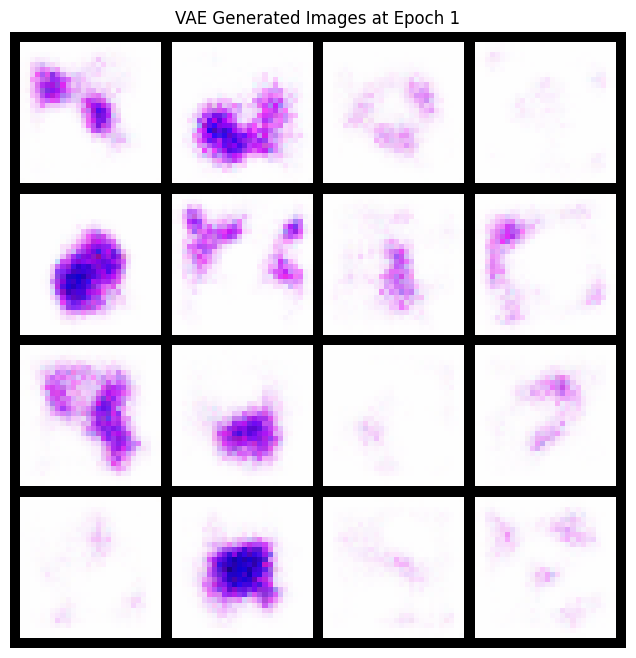

Epoch 1 FID: 323.3551
New best FID: 323.3551
Epoch [2/150] | Loss: 1128.8941 | Reconstruction: 1121.4507 | KLD: 74.4344
Epoch [3/150] | Loss: 1102.4923 | Reconstruction: 1094.7443 | KLD: 77.4800
Epoch [4/150] | Loss: 1090.3409 | Reconstruction: 1082.4395 | KLD: 79.0137
Epoch [5/150] | Loss: 1082.2323 | Reconstruction: 1074.2300 | KLD: 80.0230


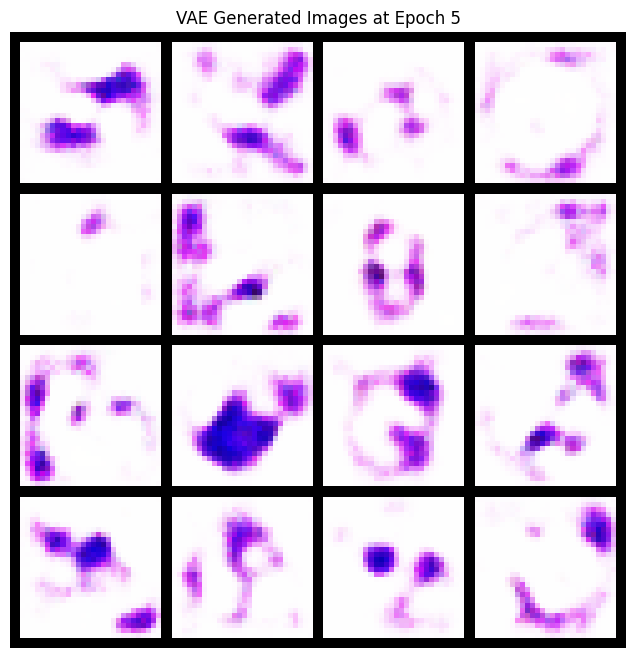

Epoch 5 FID: 232.9418
New best FID: 232.9418
Epoch [6/150] | Loss: 1076.1694 | Reconstruction: 1068.0780 | KLD: 80.9140
Epoch [7/150] | Loss: 1071.8237 | Reconstruction: 1063.7155 | KLD: 81.0821
Epoch [8/150] | Loss: 1068.4591 | Reconstruction: 1060.3381 | KLD: 81.2102
Epoch [9/150] | Loss: 1065.9423 | Reconstruction: 1057.8303 | KLD: 81.1201
Epoch [10/150] | Loss: 1063.7630 | Reconstruction: 1055.6594 | KLD: 81.0360


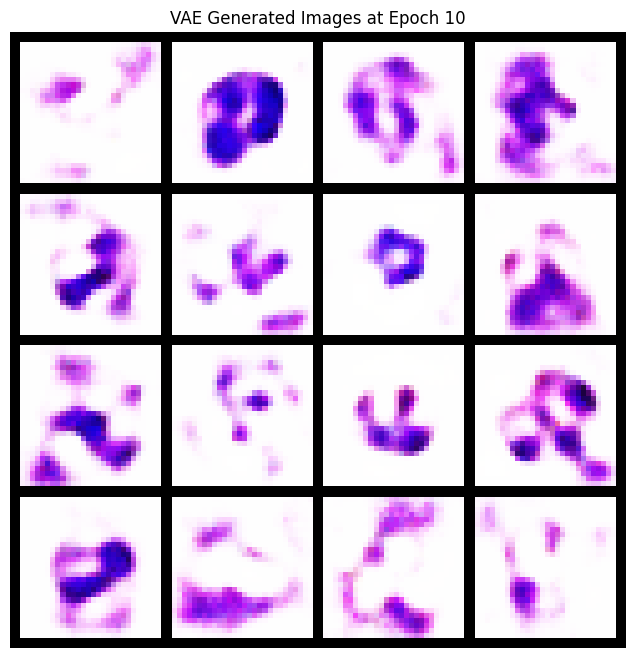

Epoch 10 FID: 204.0923
New best FID: 204.0923
Epoch [11/150] | Loss: 1061.7929 | Reconstruction: 1053.6743 | KLD: 81.1861
Epoch [12/150] | Loss: 1059.6732 | Reconstruction: 1051.5709 | KLD: 81.0229
Epoch [13/150] | Loss: 1058.4874 | Reconstruction: 1050.3746 | KLD: 81.1281
Epoch [14/150] | Loss: 1057.5212 | Reconstruction: 1049.4216 | KLD: 80.9963
Epoch [15/150] | Loss: 1056.4027 | Reconstruction: 1048.2891 | KLD: 81.1365


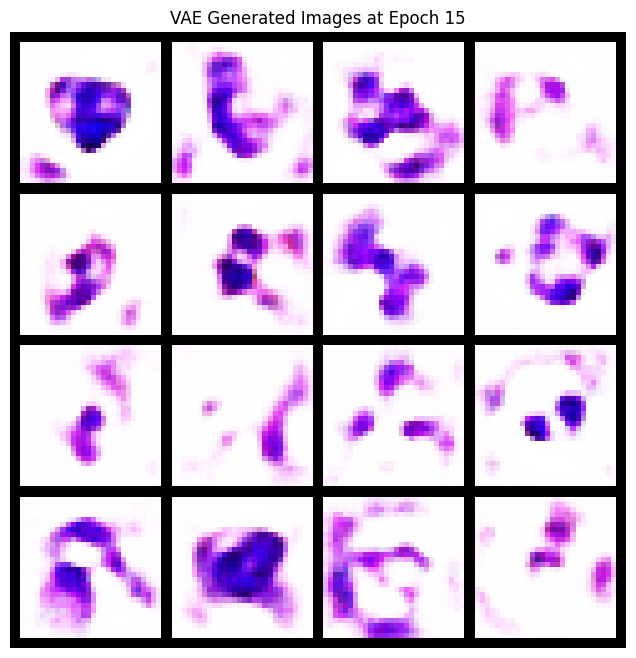

Epoch 15 FID: 194.4367
New best FID: 194.4367
Epoch [16/150] | Loss: 1054.9993 | Reconstruction: 1046.9014 | KLD: 80.9790
Epoch [17/150] | Loss: 1054.2608 | Reconstruction: 1046.1567 | KLD: 81.0409
Epoch [18/150] | Loss: 1053.4826 | Reconstruction: 1045.3728 | KLD: 81.0982
Epoch [19/150] | Loss: 1052.3361 | Reconstruction: 1044.2426 | KLD: 80.9356
Epoch [20/150] | Loss: 1051.7050 | Reconstruction: 1043.6195 | KLD: 80.8548


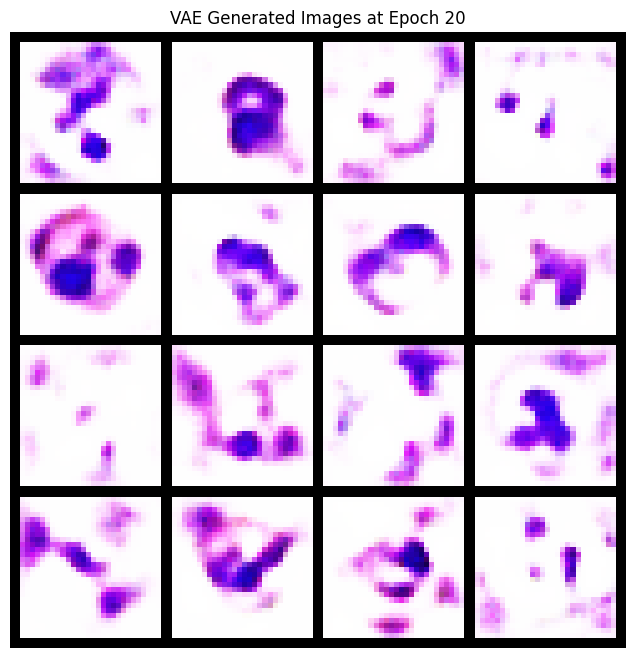

Epoch 20 FID: 185.6196
New best FID: 185.6196
Epoch [21/150] | Loss: 1051.3141 | Reconstruction: 1043.2145 | KLD: 80.9955
Epoch [22/150] | Loss: 1050.5894 | Reconstruction: 1042.4818 | KLD: 81.0761
Epoch [23/150] | Loss: 1049.6162 | Reconstruction: 1041.5320 | KLD: 80.8421
Epoch [24/150] | Loss: 1048.8854 | Reconstruction: 1040.8011 | KLD: 80.8429
Epoch [25/150] | Loss: 1048.5504 | Reconstruction: 1040.4773 | KLD: 80.7313


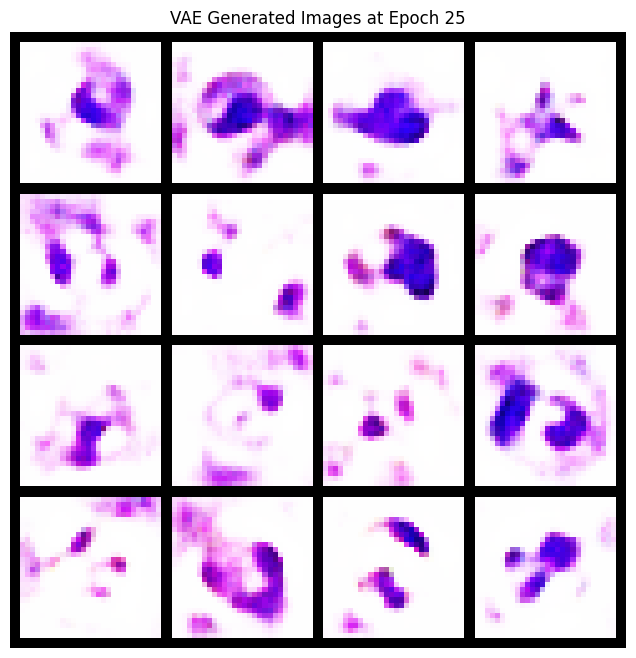

Epoch 25 FID: 183.7782
New best FID: 183.7782
Epoch [26/150] | Loss: 1048.1268 | Reconstruction: 1040.0523 | KLD: 80.7442
Epoch [27/150] | Loss: 1047.4734 | Reconstruction: 1039.3815 | KLD: 80.9181
Epoch [28/150] | Loss: 1046.7783 | Reconstruction: 1038.7078 | KLD: 80.7051
Epoch [29/150] | Loss: 1046.5216 | Reconstruction: 1038.4343 | KLD: 80.8724
Epoch [30/150] | Loss: 1045.9622 | Reconstruction: 1037.8775 | KLD: 80.8467


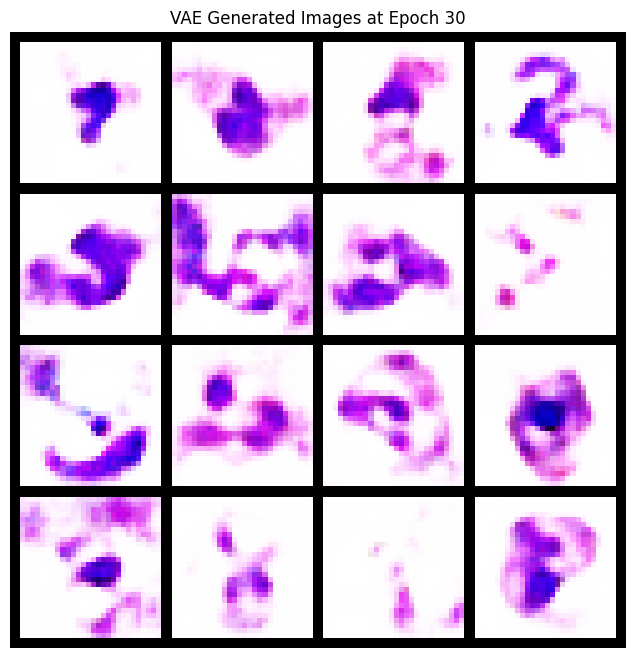

Epoch 30 FID: 182.3990
New best FID: 182.3990
Epoch [31/150] | Loss: 1045.9878 | Reconstruction: 1037.9139 | KLD: 80.7396
Epoch [32/150] | Loss: 1045.3745 | Reconstruction: 1037.2979 | KLD: 80.7656
Epoch [33/150] | Loss: 1045.1726 | Reconstruction: 1037.0728 | KLD: 80.9987
Epoch [34/150] | Loss: 1044.2221 | Reconstruction: 1036.1505 | KLD: 80.7155
Epoch [35/150] | Loss: 1044.1908 | Reconstruction: 1036.1295 | KLD: 80.6137


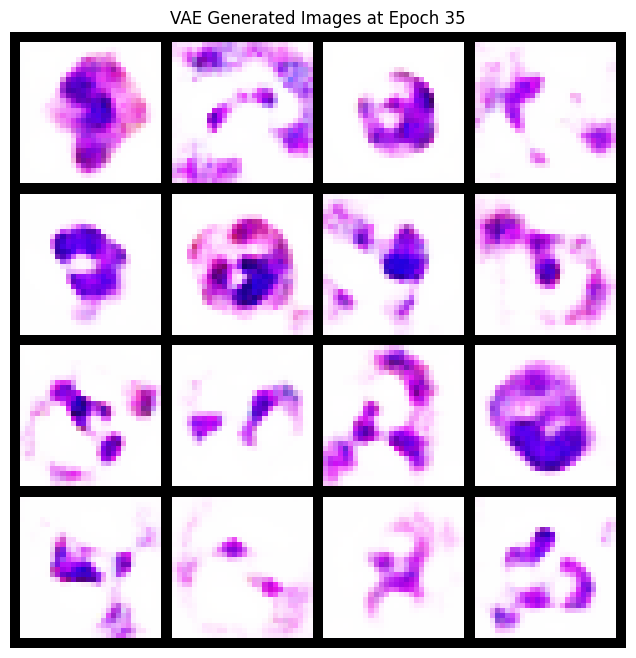

Epoch 35 FID: 178.1552
New best FID: 178.1552
Epoch [36/150] | Loss: 1043.9440 | Reconstruction: 1035.8653 | KLD: 80.7868
Epoch [37/150] | Loss: 1042.7467 | Reconstruction: 1034.6525 | KLD: 80.9426
Epoch [38/150] | Loss: 1042.9749 | Reconstruction: 1034.9081 | KLD: 80.6684
Epoch [39/150] | Loss: 1042.8558 | Reconstruction: 1034.7844 | KLD: 80.7147
Epoch [40/150] | Loss: 1041.6078 | Reconstruction: 1033.5505 | KLD: 80.5729


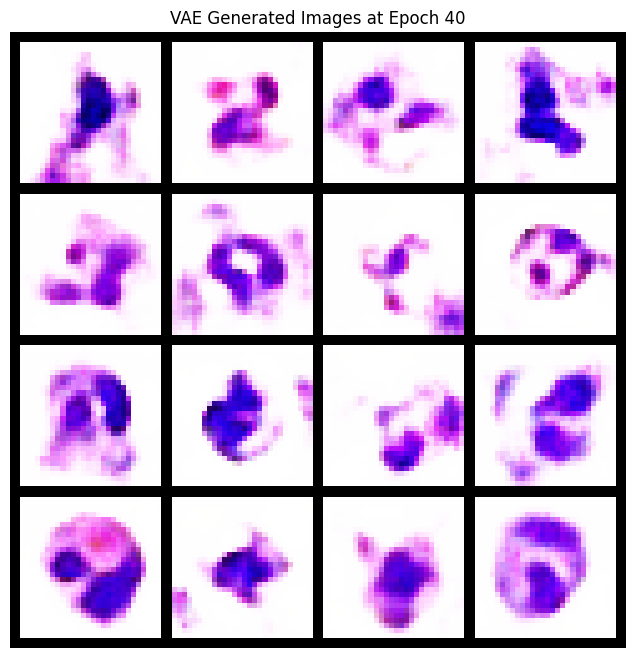

Epoch 40 FID: 178.1338
New best FID: 178.1338
Epoch [41/150] | Loss: 1042.6532 | Reconstruction: 1034.5365 | KLD: 81.1672
Epoch [42/150] | Loss: 1041.4712 | Reconstruction: 1033.3824 | KLD: 80.8883
Epoch [43/150] | Loss: 1040.8128 | Reconstruction: 1032.7395 | KLD: 80.7327
Epoch [44/150] | Loss: 1040.9859 | Reconstruction: 1032.9017 | KLD: 80.8415
Epoch [45/150] | Loss: 1040.0292 | Reconstruction: 1031.9621 | KLD: 80.6710


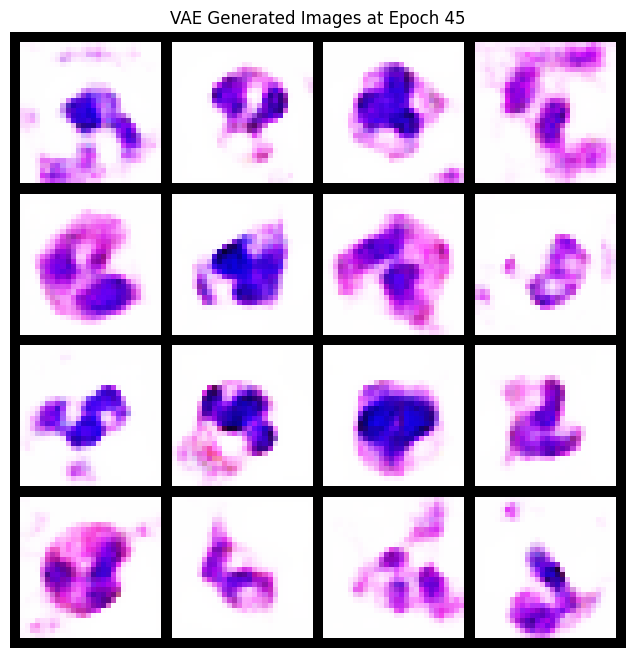

Epoch 45 FID: 175.7659
New best FID: 175.7659
Epoch [46/150] | Loss: 1039.6236 | Reconstruction: 1031.5651 | KLD: 80.5857
Epoch [47/150] | Loss: 1039.9471 | Reconstruction: 1031.8552 | KLD: 80.9194
Epoch [48/150] | Loss: 1039.9063 | Reconstruction: 1031.8083 | KLD: 80.9792
Epoch [49/150] | Loss: 1038.7814 | Reconstruction: 1030.6955 | KLD: 80.8594
Epoch [50/150] | Loss: 1038.9448 | Reconstruction: 1030.8407 | KLD: 81.0416


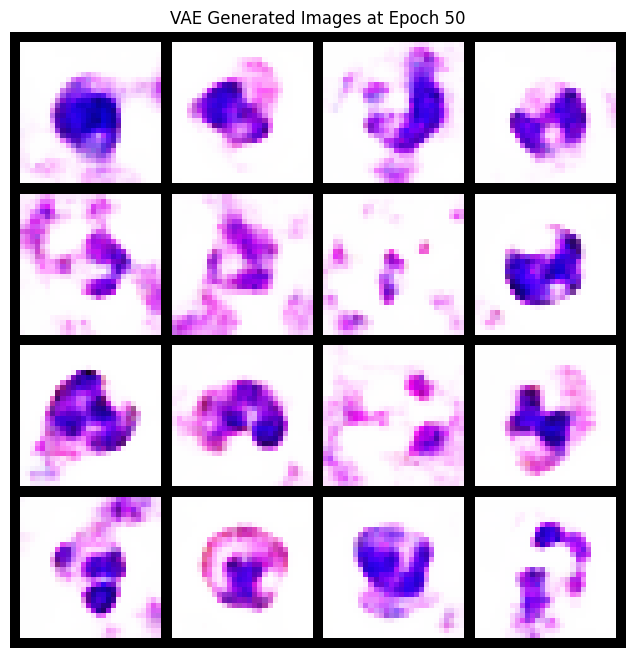

Epoch 50 FID: 177.2943
No improvement for 1 evaluations
Epoch [51/150] | Loss: 1038.4599 | Reconstruction: 1030.3751 | KLD: 80.8481
Epoch [52/150] | Loss: 1037.7146 | Reconstruction: 1029.6346 | KLD: 80.8003
Epoch [53/150] | Loss: 1037.6150 | Reconstruction: 1029.5379 | KLD: 80.7711
Epoch [54/150] | Loss: 1038.5686 | Reconstruction: 1030.4647 | KLD: 81.0393
Epoch [55/150] | Loss: 1037.4364 | Reconstruction: 1029.3226 | KLD: 81.1378


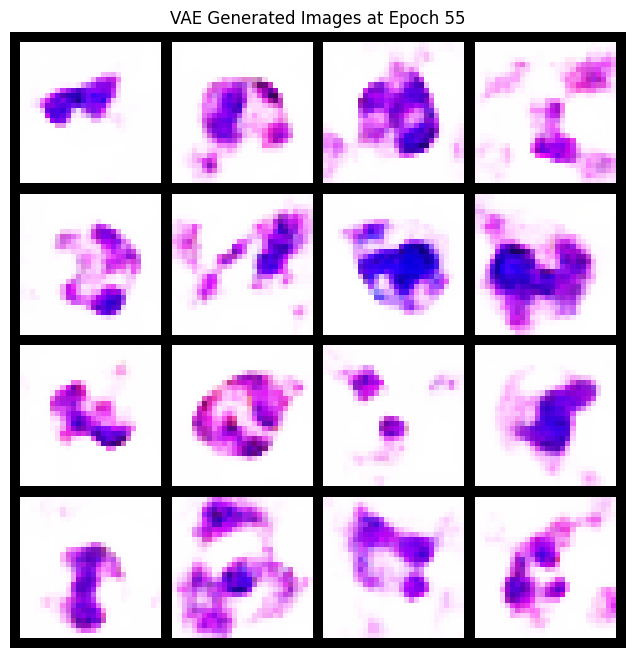

Epoch 55 FID: 176.5545
No improvement for 2 evaluations
Epoch [56/150] | Loss: 1037.1171 | Reconstruction: 1029.0332 | KLD: 80.8382
Epoch [57/150] | Loss: 1037.0252 | Reconstruction: 1028.9151 | KLD: 81.1014
Epoch [58/150] | Loss: 1036.7071 | Reconstruction: 1028.6116 | KLD: 80.9552
Epoch [59/150] | Loss: 1036.2172 | Reconstruction: 1028.1156 | KLD: 81.0161
Epoch [60/150] | Loss: 1036.3704 | Reconstruction: 1028.2801 | KLD: 80.9038


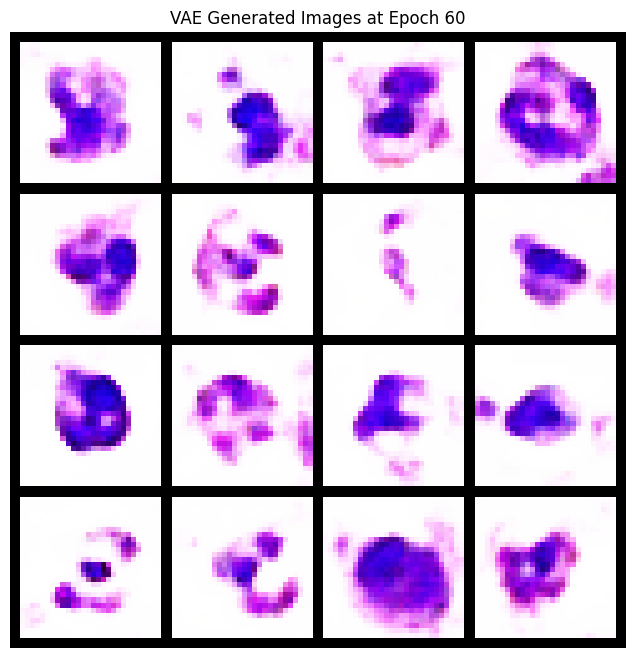

Epoch 60 FID: 173.4440
New best FID: 173.4440
Epoch [61/150] | Loss: 1035.6758 | Reconstruction: 1027.5618 | KLD: 81.1400
Epoch [62/150] | Loss: 1035.8832 | Reconstruction: 1027.7658 | KLD: 81.1738
Epoch [63/150] | Loss: 1035.9331 | Reconstruction: 1027.8254 | KLD: 81.0768
Epoch [64/150] | Loss: 1035.0343 | Reconstruction: 1026.9231 | KLD: 81.1123
Epoch [65/150] | Loss: 1035.2746 | Reconstruction: 1027.1569 | KLD: 81.1773


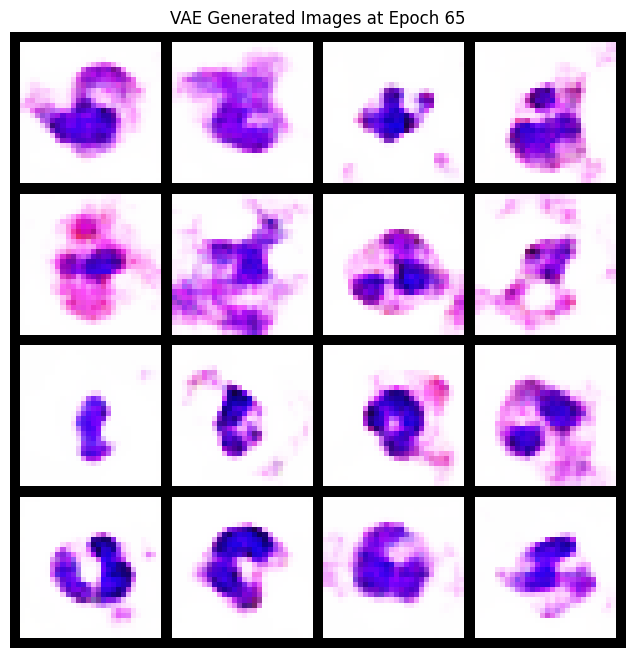

Epoch 65 FID: 174.5762
No improvement for 1 evaluations
Epoch [66/150] | Loss: 1034.6759 | Reconstruction: 1026.5575 | KLD: 81.1841
Epoch [67/150] | Loss: 1034.6946 | Reconstruction: 1026.5706 | KLD: 81.2398
Epoch [68/150] | Loss: 1033.7896 | Reconstruction: 1025.6842 | KLD: 81.0539
Epoch [69/150] | Loss: 1033.9751 | Reconstruction: 1025.8720 | KLD: 81.0315
Epoch [70/150] | Loss: 1033.7724 | Reconstruction: 1025.6673 | KLD: 81.0510


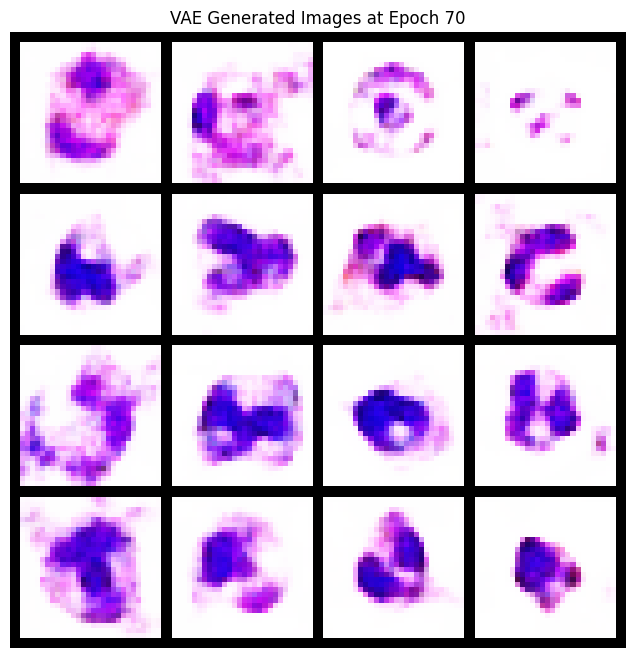

Epoch 70 FID: 176.0730
No improvement for 2 evaluations
Epoch [71/150] | Loss: 1033.6202 | Reconstruction: 1025.5084 | KLD: 81.1185
Epoch [72/150] | Loss: 1033.5593 | Reconstruction: 1025.4402 | KLD: 81.1909
Epoch [73/150] | Loss: 1032.8431 | Reconstruction: 1024.7318 | KLD: 81.1138
Epoch [74/150] | Loss: 1032.5980 | Reconstruction: 1024.4917 | KLD: 81.0628
Epoch [75/150] | Loss: 1032.2190 | Reconstruction: 1024.1278 | KLD: 80.9118


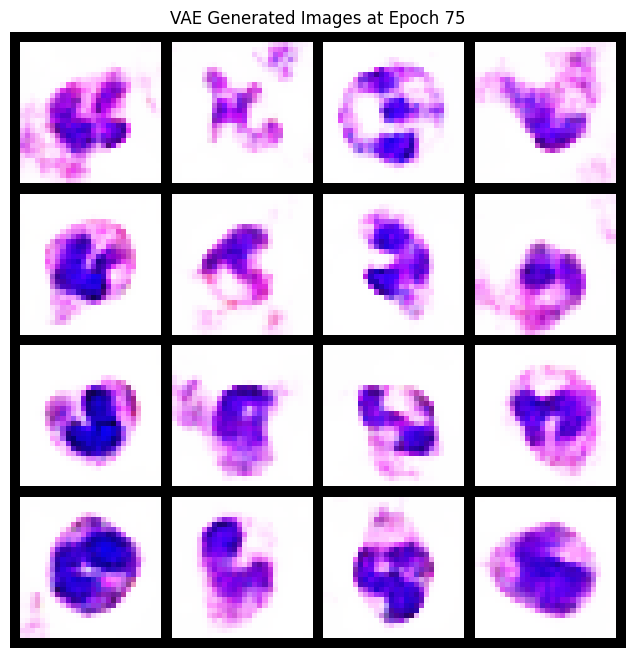

Epoch 75 FID: 173.3709
New best FID: 173.3709
Epoch [76/150] | Loss: 1032.1383 | Reconstruction: 1024.0448 | KLD: 80.9351
Epoch [77/150] | Loss: 1032.5035 | Reconstruction: 1024.3996 | KLD: 81.0390
Epoch [78/150] | Loss: 1032.6229 | Reconstruction: 1024.5022 | KLD: 81.2079
Epoch [79/150] | Loss: 1031.5720 | Reconstruction: 1023.4863 | KLD: 80.8569
Epoch [80/150] | Loss: 1031.6318 | Reconstruction: 1023.5202 | KLD: 81.1160


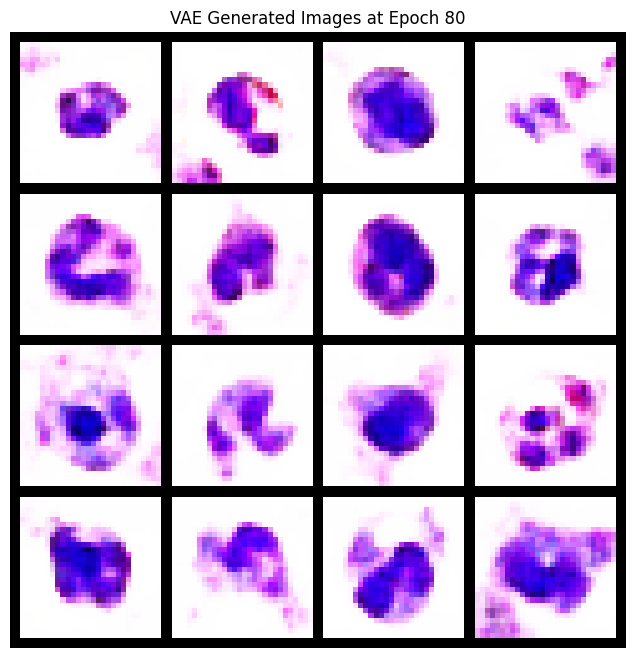

Epoch 80 FID: 171.5881
New best FID: 171.5881
Epoch [81/150] | Loss: 1031.0931 | Reconstruction: 1022.9835 | KLD: 81.0969
Epoch [82/150] | Loss: 1031.5656 | Reconstruction: 1023.4626 | KLD: 81.0308
Epoch [83/150] | Loss: 1031.2398 | Reconstruction: 1023.1213 | KLD: 81.1848
Epoch [84/150] | Loss: 1031.5127 | Reconstruction: 1023.4069 | KLD: 81.0580
Epoch [85/150] | Loss: 1030.9253 | Reconstruction: 1022.8042 | KLD: 81.2107


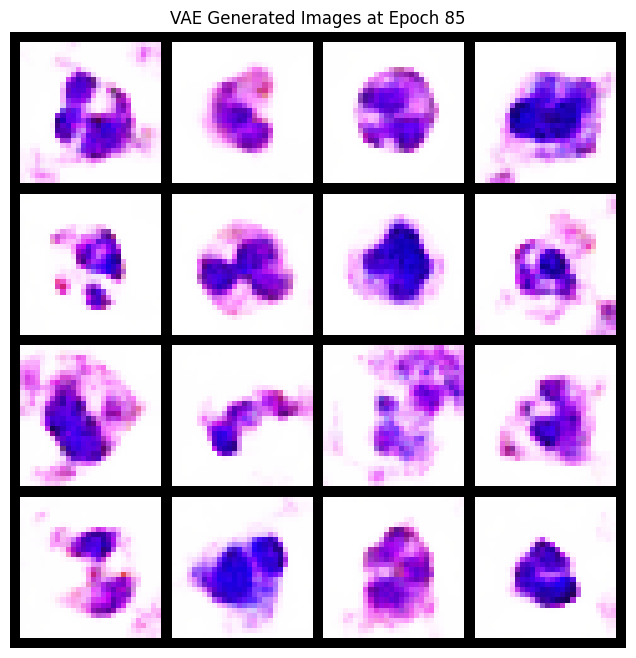

Epoch 85 FID: 174.4079
No improvement for 1 evaluations
Epoch [86/150] | Loss: 1030.8751 | Reconstruction: 1022.7342 | KLD: 81.4084
Epoch [87/150] | Loss: 1030.4032 | Reconstruction: 1022.2972 | KLD: 81.0605
Epoch [88/150] | Loss: 1030.1581 | Reconstruction: 1022.0446 | KLD: 81.1346
Epoch [89/150] | Loss: 1030.3733 | Reconstruction: 1022.2625 | KLD: 81.1078
Epoch [90/150] | Loss: 1029.7929 | Reconstruction: 1021.6846 | KLD: 81.0833


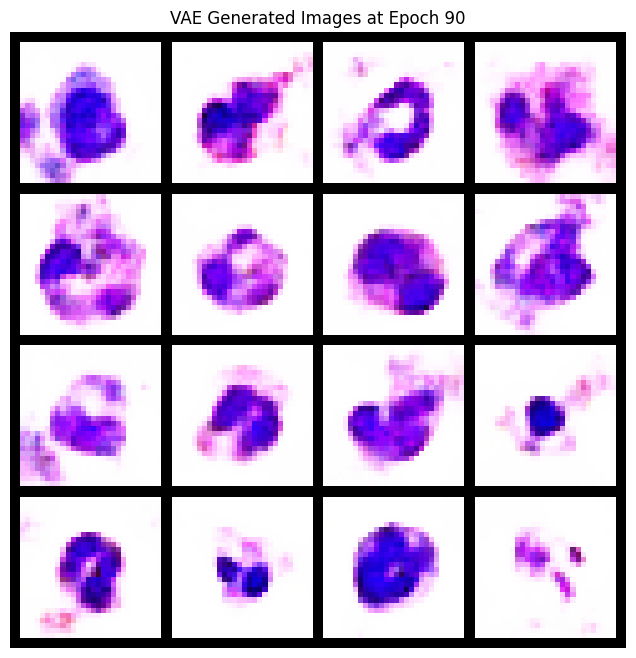

Epoch 90 FID: 174.4128
No improvement for 2 evaluations
Epoch [91/150] | Loss: 1029.6049 | Reconstruction: 1021.4966 | KLD: 81.0834
Epoch [92/150] | Loss: 1029.9110 | Reconstruction: 1021.7999 | KLD: 81.1108
Epoch [93/150] | Loss: 1029.8606 | Reconstruction: 1021.7347 | KLD: 81.2584
Epoch [94/150] | Loss: 1029.2517 | Reconstruction: 1021.1415 | KLD: 81.1021
Epoch [95/150] | Loss: 1029.6986 | Reconstruction: 1021.5708 | KLD: 81.2778


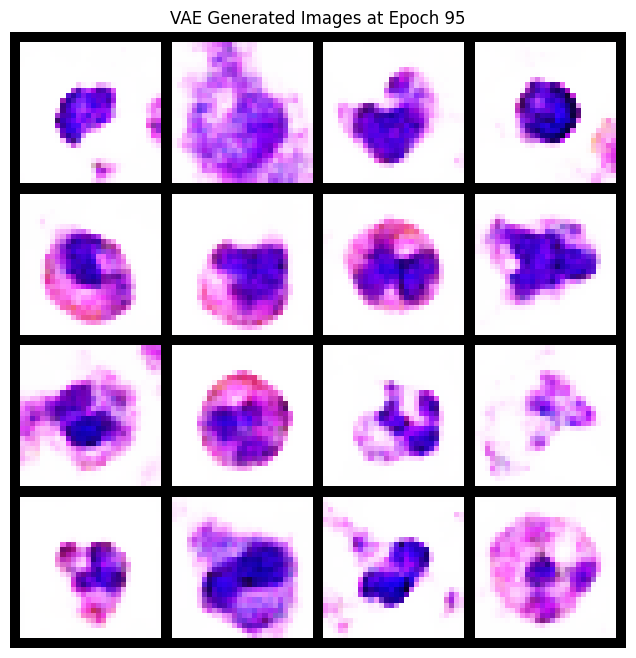

Epoch 95 FID: 174.5691
No improvement for 3 evaluations
Epoch [96/150] | Loss: 1028.7646 | Reconstruction: 1020.6517 | KLD: 81.1293
Epoch [97/150] | Loss: 1028.5787 | Reconstruction: 1020.4748 | KLD: 81.0386
Epoch [98/150] | Loss: 1028.6843 | Reconstruction: 1020.5886 | KLD: 80.9572
Epoch [99/150] | Loss: 1028.5918 | Reconstruction: 1020.4741 | KLD: 81.1773
Epoch [100/150] | Loss: 1028.6102 | Reconstruction: 1020.5027 | KLD: 81.0747


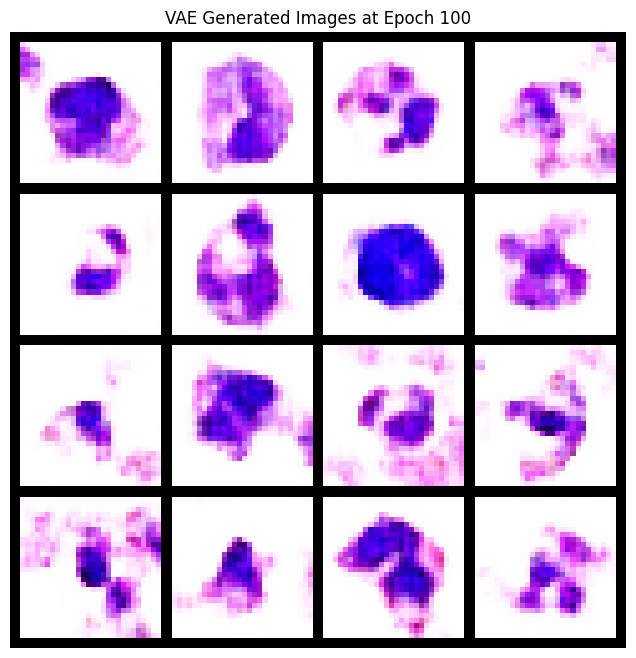

Epoch 100 FID: 174.7439
No improvement for 4 evaluations
Epoch [101/150] | Loss: 1028.6924 | Reconstruction: 1020.5712 | KLD: 81.2122
Epoch [102/150] | Loss: 1028.1783 | Reconstruction: 1020.0661 | KLD: 81.1222
Epoch [103/150] | Loss: 1027.8174 | Reconstruction: 1019.7014 | KLD: 81.1597
Epoch [104/150] | Loss: 1028.2557 | Reconstruction: 1020.1410 | KLD: 81.1474
Epoch [105/150] | Loss: 1027.8923 | Reconstruction: 1019.7754 | KLD: 81.1695


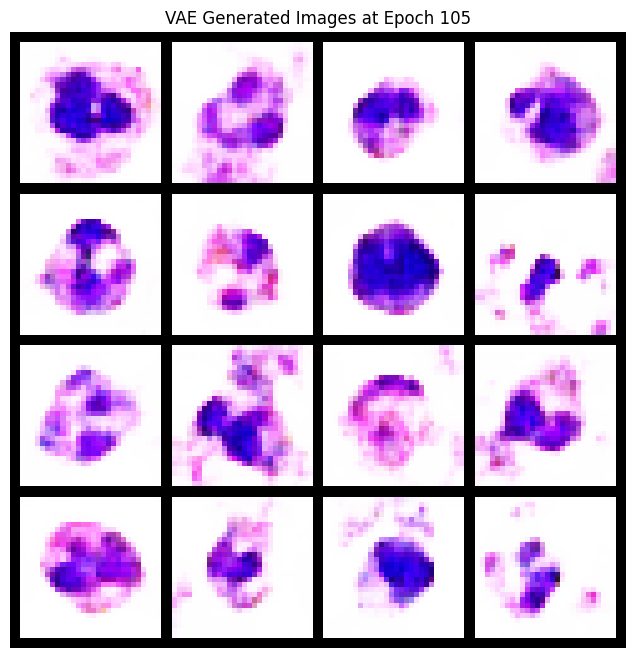

Epoch 105 FID: 175.8532
No improvement for 5 evaluations
Early stopping at epoch 105
VAE FID Score: 165.7407

VAE Hyperparameter combination 2/5
Configuration: {'beta': 0.1, 'beta_schedule': None, 'epochs': 150, 'hidden_dims': [512, 256], 'latent_dim': 32, 'learning_rate': 0.0003}
Starting VAE training with hyperparameters: {'beta': 0.1, 'beta_schedule': None, 'epochs': 150, 'hidden_dims': [512, 256], 'latent_dim': 32, 'learning_rate': 0.0003}
Epoch [1/150] | Loss: 1565.5025 | Reconstruction: 1555.0996 | KLD: 104.0290


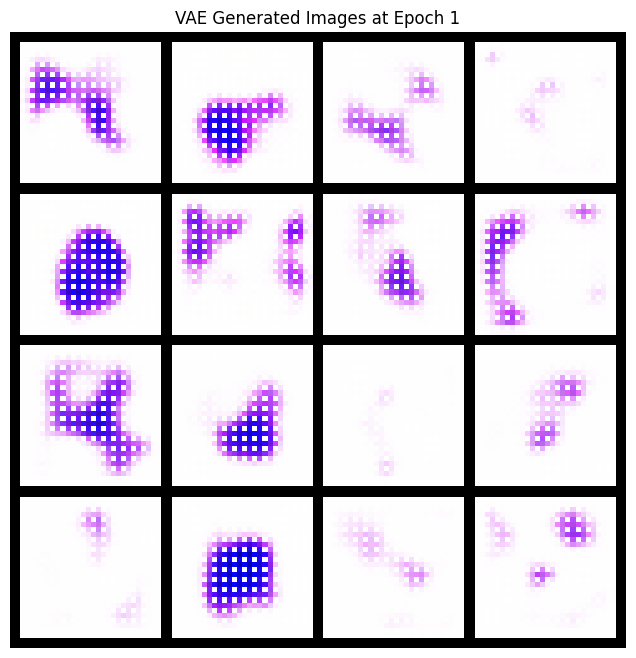

Epoch 1 FID: 347.6037
New best FID: 347.6037
Epoch [2/150] | Loss: 1349.4785 | Reconstruction: 1341.7660 | KLD: 77.1243
Epoch [3/150] | Loss: 1335.4188 | Reconstruction: 1327.7377 | KLD: 76.8116
Epoch [4/150] | Loss: 1328.9965 | Reconstruction: 1321.1288 | KLD: 78.6770
Epoch [5/150] | Loss: 1322.6211 | Reconstruction: 1315.0663 | KLD: 75.5481


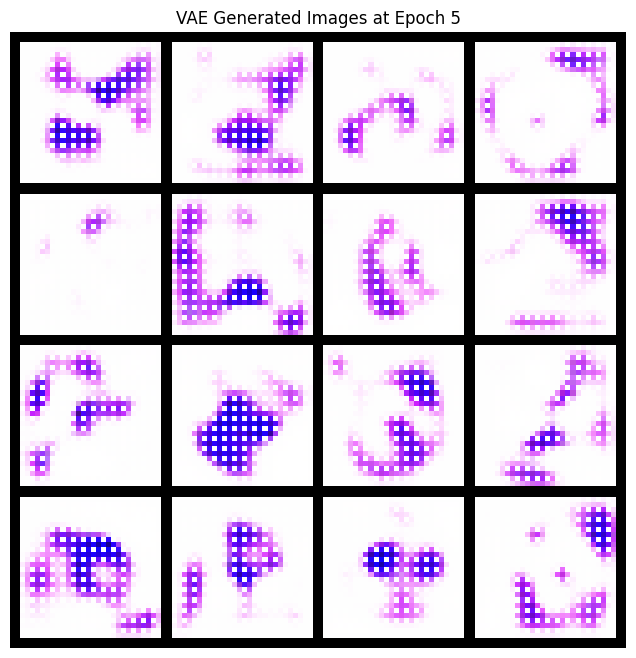

Epoch 5 FID: 308.1359
New best FID: 308.1359
Epoch [6/150] | Loss: 1318.6263 | Reconstruction: 1311.1981 | KLD: 74.2820
Epoch [7/150] | Loss: 1312.5079 | Reconstruction: 1304.8883 | KLD: 76.1963
Epoch [8/150] | Loss: 1263.3393 | Reconstruction: 1255.7246 | KLD: 76.1469
Epoch [9/150] | Loss: 1123.7161 | Reconstruction: 1115.5226 | KLD: 81.9353
Epoch [10/150] | Loss: 1067.1057 | Reconstruction: 1058.5826 | KLD: 85.2316


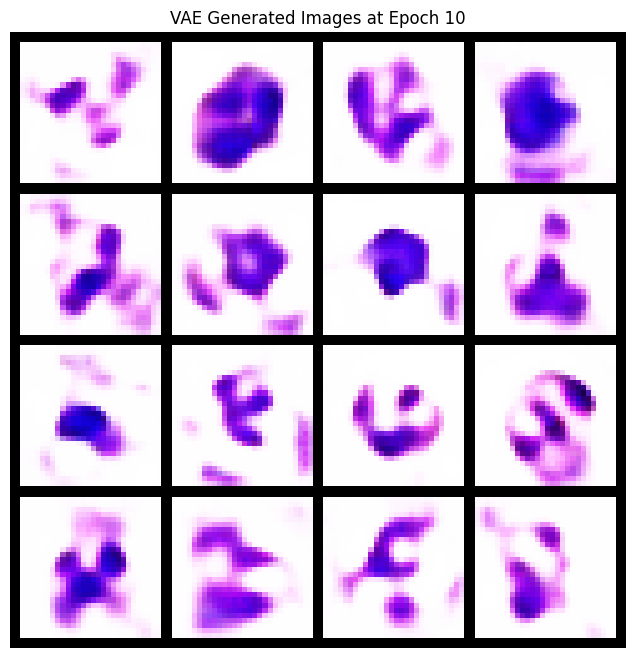

Epoch 10 FID: 192.1311
New best FID: 192.1311
Epoch [11/150] | Loss: 1061.7009 | Reconstruction: 1053.2513 | KLD: 84.4959
Epoch [12/150] | Loss: 1058.8876 | Reconstruction: 1050.5644 | KLD: 83.2319
Epoch [13/150] | Loss: 1057.1930 | Reconstruction: 1048.8941 | KLD: 82.9886
Epoch [14/150] | Loss: 1055.4918 | Reconstruction: 1047.2436 | KLD: 82.4823
Epoch [15/150] | Loss: 1054.6123 | Reconstruction: 1046.3339 | KLD: 82.7837


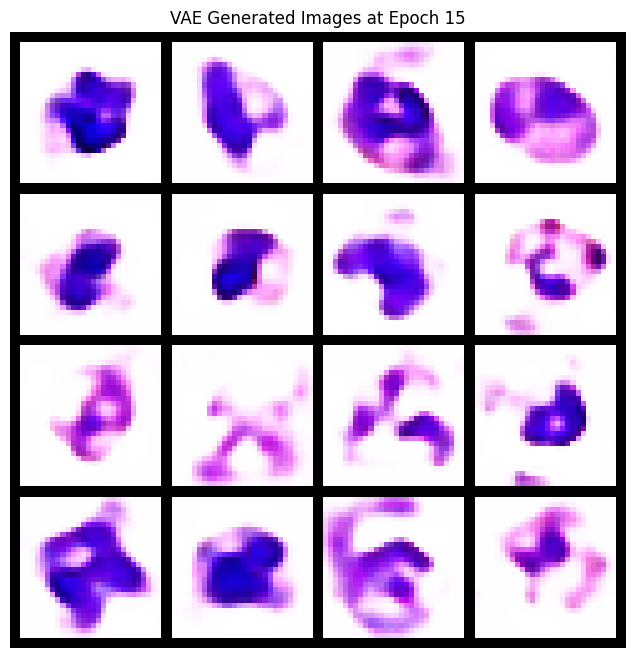

Epoch 15 FID: 185.6807
New best FID: 185.6807
Epoch [16/150] | Loss: 1053.0879 | Reconstruction: 1044.8794 | KLD: 82.0847
Epoch [17/150] | Loss: 1052.2815 | Reconstruction: 1044.0935 | KLD: 81.8800
Epoch [18/150] | Loss: 1050.7784 | Reconstruction: 1042.6564 | KLD: 81.2208
Epoch [19/150] | Loss: 1049.8093 | Reconstruction: 1041.7405 | KLD: 80.6872
Epoch [20/150] | Loss: 1049.0050 | Reconstruction: 1040.9479 | KLD: 80.5716


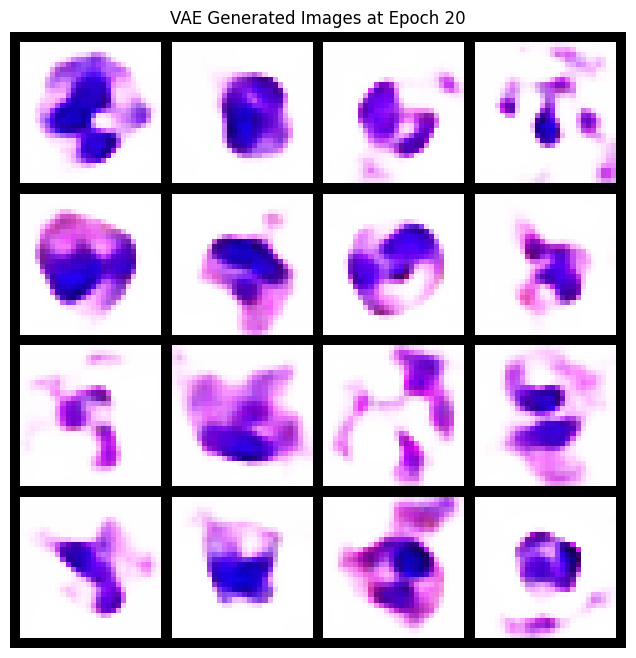

Epoch 20 FID: 183.7935
New best FID: 183.7935
Epoch [21/150] | Loss: 1049.4094 | Reconstruction: 1041.2382 | KLD: 81.7124
Epoch [22/150] | Loss: 1047.6838 | Reconstruction: 1039.5612 | KLD: 81.2267
Epoch [23/150] | Loss: 1047.0937 | Reconstruction: 1039.0077 | KLD: 80.8596
Epoch [24/150] | Loss: 1046.3056 | Reconstruction: 1038.2261 | KLD: 80.7944
Epoch [25/150] | Loss: 1046.6504 | Reconstruction: 1038.5432 | KLD: 81.0719


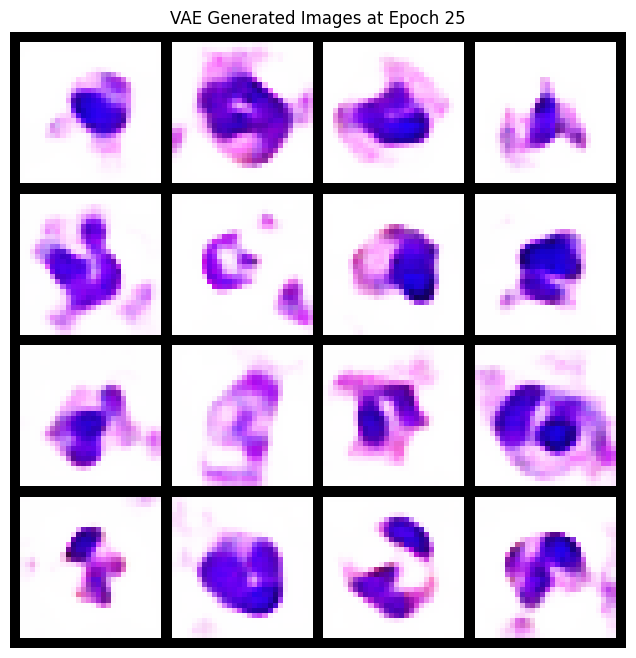

Epoch 25 FID: 180.3966
New best FID: 180.3966
Epoch [26/150] | Loss: 1045.6788 | Reconstruction: 1037.5646 | KLD: 81.1424
Epoch [27/150] | Loss: 1044.7274 | Reconstruction: 1036.6345 | KLD: 80.9291
Epoch [28/150] | Loss: 1044.0810 | Reconstruction: 1036.0021 | KLD: 80.7889
Epoch [29/150] | Loss: 1044.0450 | Reconstruction: 1035.9367 | KLD: 81.0824
Epoch [30/150] | Loss: 1043.2126 | Reconstruction: 1035.1348 | KLD: 80.7789


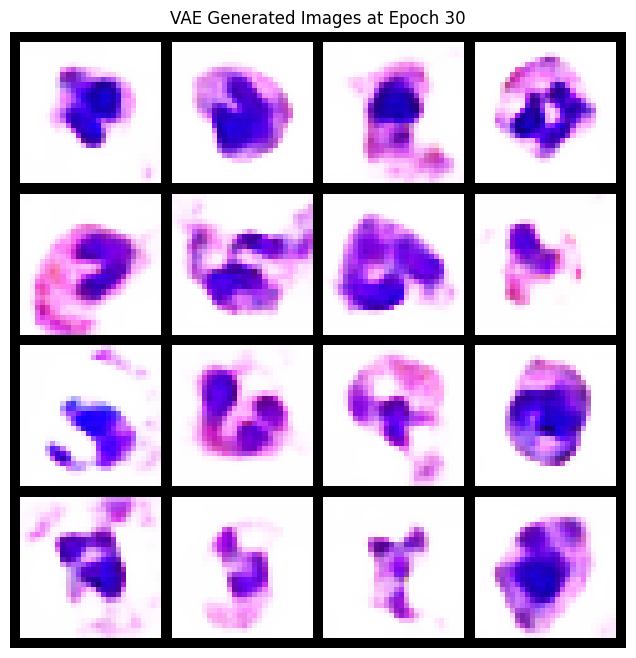

Epoch 30 FID: 179.7401
New best FID: 179.7401
Epoch [31/150] | Loss: 1042.5244 | Reconstruction: 1034.4768 | KLD: 80.4765
Epoch [32/150] | Loss: 1042.2482 | Reconstruction: 1034.1964 | KLD: 80.5178
Epoch [33/150] | Loss: 1042.3901 | Reconstruction: 1034.2705 | KLD: 81.1957
Epoch [34/150] | Loss: 1041.6445 | Reconstruction: 1033.5594 | KLD: 80.8517
Epoch [35/150] | Loss: 1040.9200 | Reconstruction: 1032.8578 | KLD: 80.6226


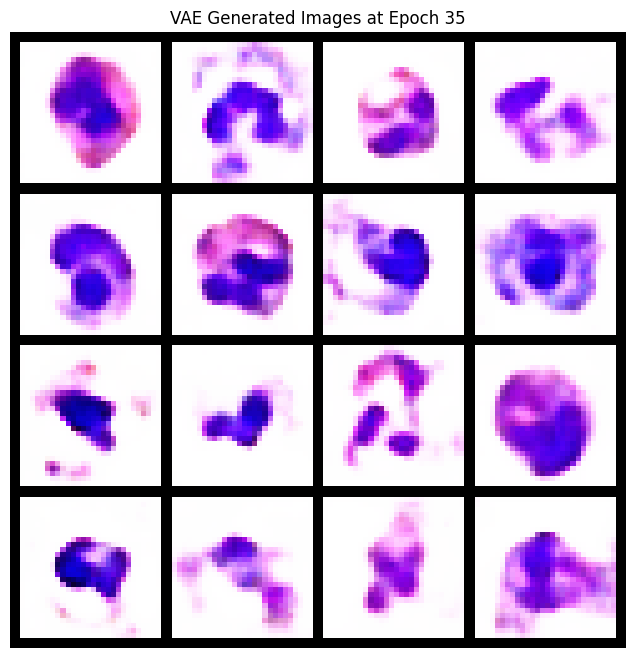

Epoch 35 FID: 175.8621
New best FID: 175.8621
Epoch [36/150] | Loss: 1040.5472 | Reconstruction: 1032.5055 | KLD: 80.4180
Epoch [37/150] | Loss: 1039.6780 | Reconstruction: 1031.6195 | KLD: 80.5851
Epoch [38/150] | Loss: 1040.0735 | Reconstruction: 1032.0224 | KLD: 80.5109
Epoch [39/150] | Loss: 1039.7802 | Reconstruction: 1031.7079 | KLD: 80.7228
Epoch [40/150] | Loss: 1038.5411 | Reconstruction: 1030.5291 | KLD: 80.1200


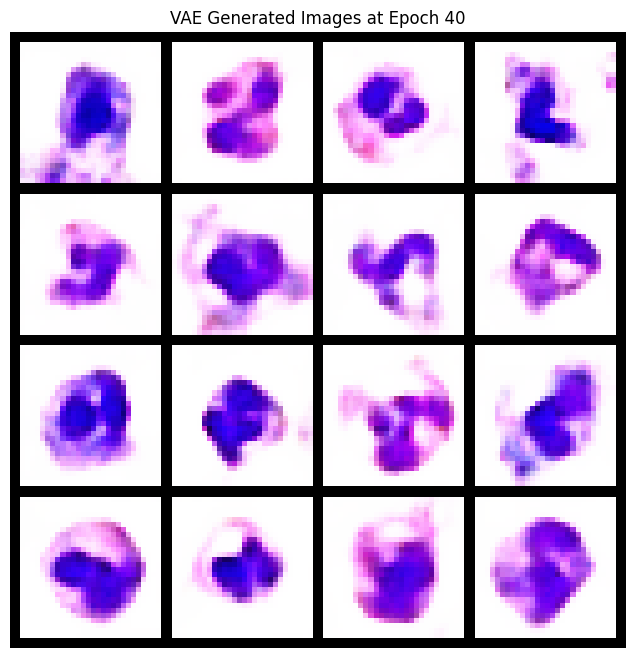

Epoch 40 FID: 175.4404
New best FID: 175.4404
Epoch [41/150] | Loss: 1038.8781 | Reconstruction: 1030.8102 | KLD: 80.6793
Epoch [42/150] | Loss: 1038.3949 | Reconstruction: 1030.3553 | KLD: 80.3952
Epoch [43/150] | Loss: 1037.3959 | Reconstruction: 1029.3792 | KLD: 80.1672
Epoch [44/150] | Loss: 1037.4813 | Reconstruction: 1029.4416 | KLD: 80.3978
Epoch [45/150] | Loss: 1037.1130 | Reconstruction: 1029.0939 | KLD: 80.1914


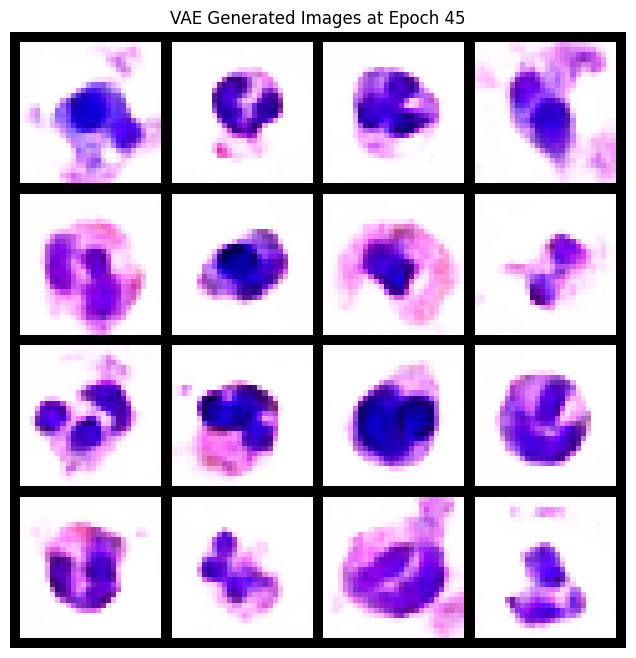

Epoch 45 FID: 177.6133
No improvement for 1 evaluations
Epoch [46/150] | Loss: 1036.8000 | Reconstruction: 1028.7618 | KLD: 80.3820
Epoch [47/150] | Loss: 1036.7795 | Reconstruction: 1028.7300 | KLD: 80.4953
Epoch [48/150] | Loss: 1036.1582 | Reconstruction: 1028.1190 | KLD: 80.3924
Epoch [49/150] | Loss: 1035.9490 | Reconstruction: 1027.9004 | KLD: 80.4859
Epoch [50/150] | Loss: 1035.4537 | Reconstruction: 1027.4321 | KLD: 80.2166


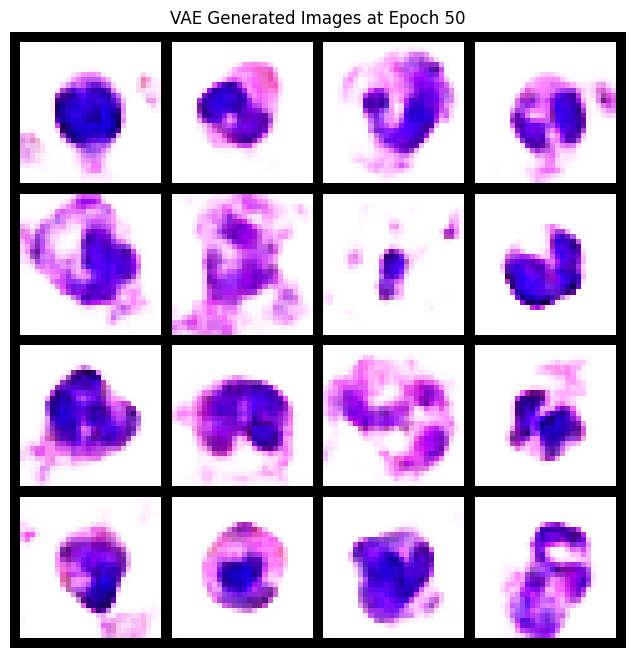

Epoch 50 FID: 180.5094
No improvement for 2 evaluations
Epoch [51/150] | Loss: 1035.0679 | Reconstruction: 1027.0410 | KLD: 80.2686
Epoch [52/150] | Loss: 1035.0468 | Reconstruction: 1027.0304 | KLD: 80.1640
Epoch [53/150] | Loss: 1033.9117 | Reconstruction: 1025.9382 | KLD: 79.7342
Epoch [54/150] | Loss: 1034.6727 | Reconstruction: 1026.6622 | KLD: 80.1056
Epoch [55/150] | Loss: 1034.1047 | Reconstruction: 1026.0656 | KLD: 80.3913


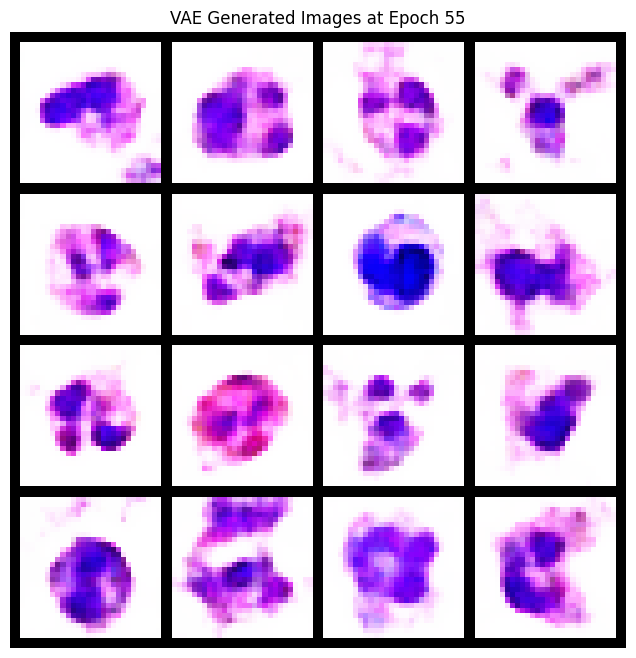

Epoch 55 FID: 177.4179
No improvement for 3 evaluations
Epoch [56/150] | Loss: 1033.5320 | Reconstruction: 1025.5421 | KLD: 79.8993
Epoch [57/150] | Loss: 1033.9307 | Reconstruction: 1025.9148 | KLD: 80.1598
Epoch [58/150] | Loss: 1033.9041 | Reconstruction: 1025.8541 | KLD: 80.5006
Epoch [59/150] | Loss: 1032.9871 | Reconstruction: 1024.9973 | KLD: 79.8974
Epoch [60/150] | Loss: 1033.5116 | Reconstruction: 1025.4726 | KLD: 80.3894


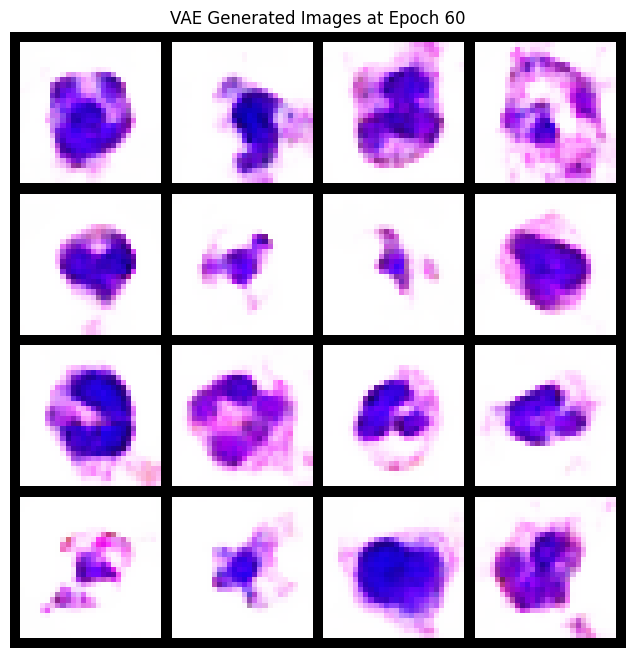

Epoch 60 FID: 173.8153
New best FID: 173.8153
Epoch [61/150] | Loss: 1032.1013 | Reconstruction: 1024.0941 | KLD: 80.0728
Epoch [62/150] | Loss: 1032.1380 | Reconstruction: 1024.1580 | KLD: 79.8006
Epoch [63/150] | Loss: 1032.3203 | Reconstruction: 1024.3336 | KLD: 79.8676
Epoch [64/150] | Loss: 1031.6918 | Reconstruction: 1023.6974 | KLD: 79.9435
Epoch [65/150] | Loss: 1031.9754 | Reconstruction: 1023.9743 | KLD: 80.0111


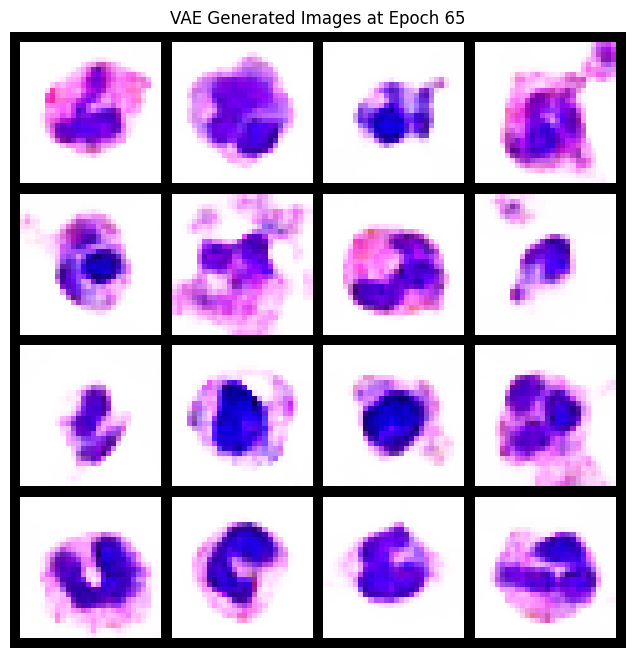

Epoch 65 FID: 173.7503
New best FID: 173.7503
Epoch [66/150] | Loss: 1031.6762 | Reconstruction: 1023.6539 | KLD: 80.2232
Epoch [67/150] | Loss: 1030.9442 | Reconstruction: 1022.9660 | KLD: 79.7822
Epoch [68/150] | Loss: 1030.5530 | Reconstruction: 1022.5943 | KLD: 79.5874
Epoch [69/150] | Loss: 1030.7794 | Reconstruction: 1022.8050 | KLD: 79.7440
Epoch [70/150] | Loss: 1030.3889 | Reconstruction: 1022.4095 | KLD: 79.7939


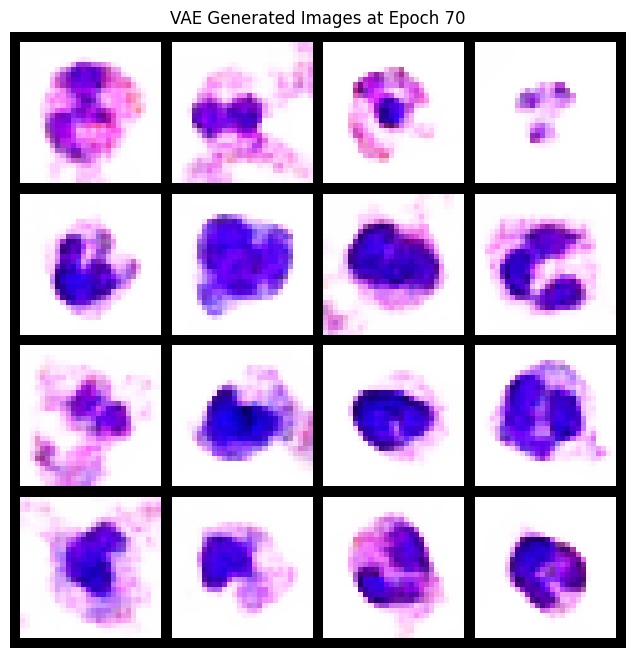

Epoch 70 FID: 174.6083
No improvement for 1 evaluations
Epoch [71/150] | Loss: 1030.1653 | Reconstruction: 1022.2112 | KLD: 79.5414
Epoch [72/150] | Loss: 1030.2362 | Reconstruction: 1022.2638 | KLD: 79.7237
Epoch [73/150] | Loss: 1029.5431 | Reconstruction: 1021.5882 | KLD: 79.5489
Epoch [74/150] | Loss: 1029.1579 | Reconstruction: 1021.2228 | KLD: 79.3509
Epoch [75/150] | Loss: 1028.6586 | Reconstruction: 1020.7235 | KLD: 79.3512


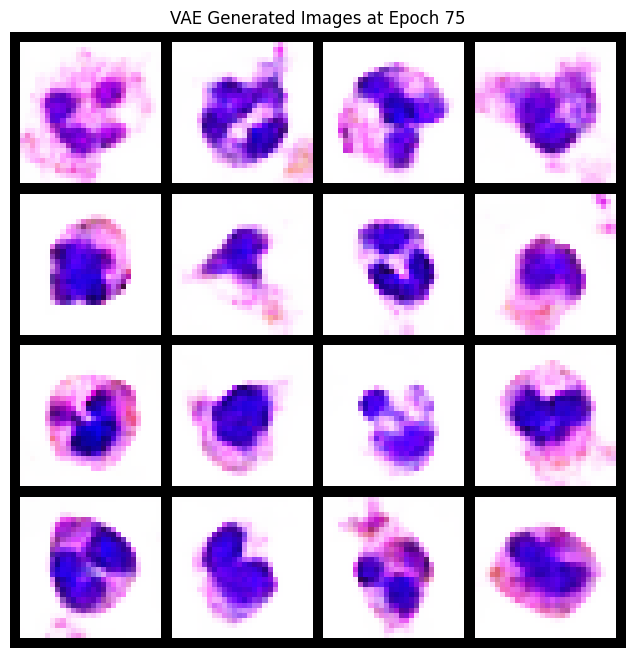

Epoch 75 FID: 173.8455
No improvement for 2 evaluations
Epoch [76/150] | Loss: 1028.5280 | Reconstruction: 1020.6164 | KLD: 79.1159
Epoch [77/150] | Loss: 1029.9022 | Reconstruction: 1021.9414 | KLD: 79.6085
Epoch [78/150] | Loss: 1028.9346 | Reconstruction: 1020.9769 | KLD: 79.5770
Epoch [79/150] | Loss: 1028.0655 | Reconstruction: 1020.1519 | KLD: 79.1355
Epoch [80/150] | Loss: 1028.0311 | Reconstruction: 1020.1112 | KLD: 79.1988


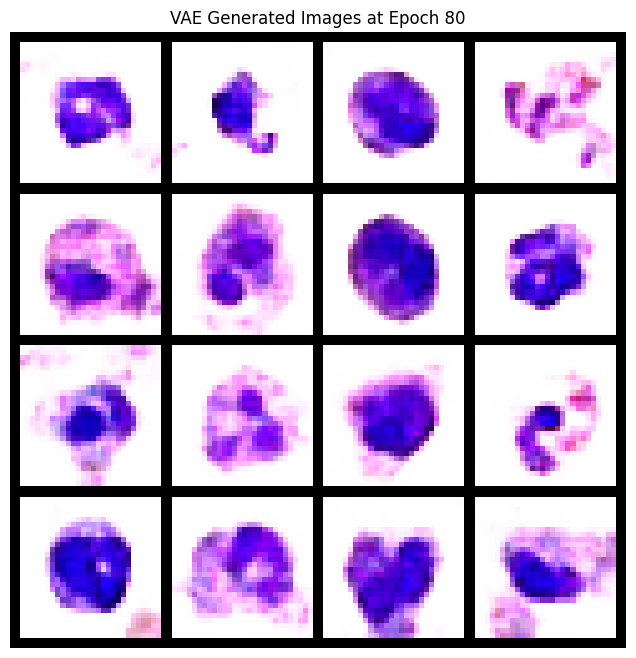

Epoch 80 FID: 170.7502
New best FID: 170.7502
Epoch [81/150] | Loss: 1027.5477 | Reconstruction: 1019.6384 | KLD: 79.0938
Epoch [82/150] | Loss: 1028.0205 | Reconstruction: 1020.0966 | KLD: 79.2393
Epoch [83/150] | Loss: 1027.9201 | Reconstruction: 1020.0002 | KLD: 79.1980
Epoch [84/150] | Loss: 1028.5853 | Reconstruction: 1020.6452 | KLD: 79.4011
Epoch [85/150] | Loss: 1028.0906 | Reconstruction: 1020.1454 | KLD: 79.4528


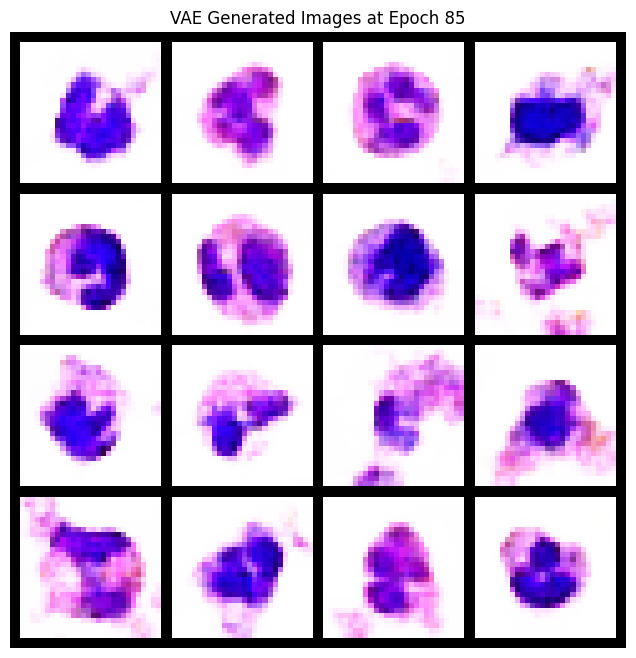

Epoch 85 FID: 174.0895
No improvement for 1 evaluations
Epoch [86/150] | Loss: 1027.4181 | Reconstruction: 1019.4639 | KLD: 79.5420
Epoch [87/150] | Loss: 1027.1734 | Reconstruction: 1019.2607 | KLD: 79.1263
Epoch [88/150] | Loss: 1026.8908 | Reconstruction: 1018.9801 | KLD: 79.1060
Epoch [89/150] | Loss: 1026.7366 | Reconstruction: 1018.8238 | KLD: 79.1274
Epoch [90/150] | Loss: 1026.5167 | Reconstruction: 1018.6183 | KLD: 78.9842


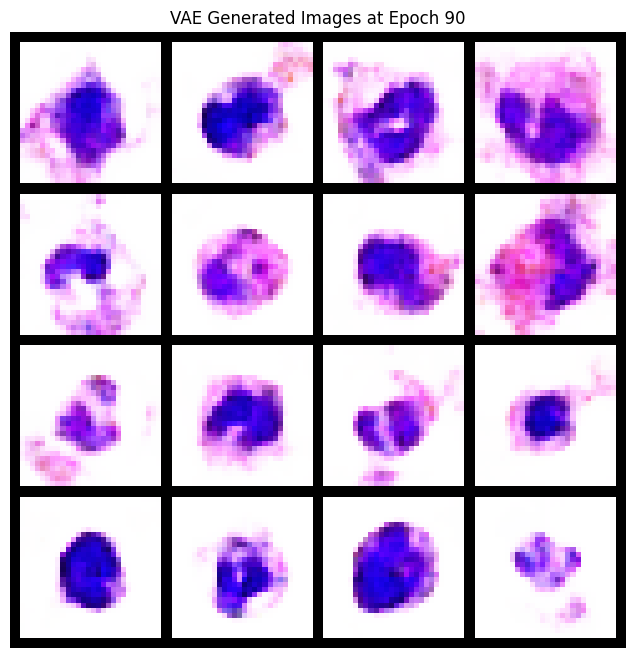

Epoch 90 FID: 172.7460
No improvement for 2 evaluations
Epoch [91/150] | Loss: 1026.4822 | Reconstruction: 1018.5721 | KLD: 79.1005
Epoch [92/150] | Loss: 1026.2432 | Reconstruction: 1018.3548 | KLD: 78.8836
Epoch [93/150] | Loss: 1026.4095 | Reconstruction: 1018.5117 | KLD: 78.9784
Epoch [94/150] | Loss: 1025.9374 | Reconstruction: 1018.0519 | KLD: 78.8550
Epoch [95/150] | Loss: 1025.8756 | Reconstruction: 1017.9739 | KLD: 79.0161


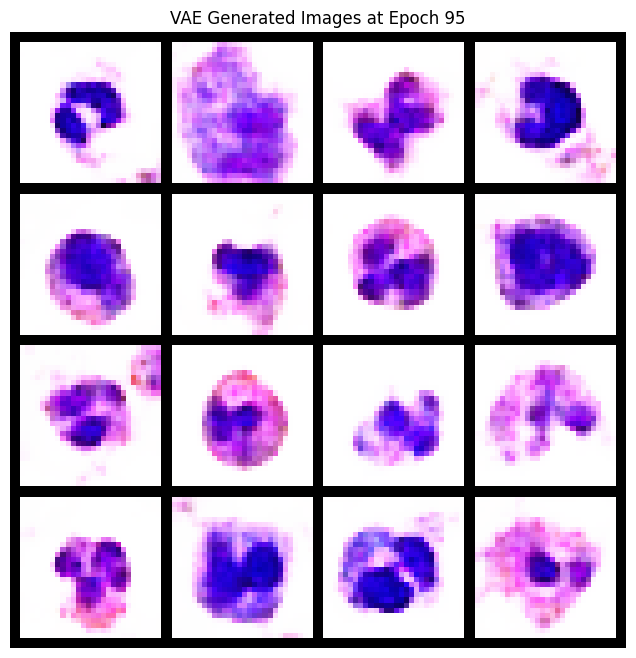

Epoch 95 FID: 170.9052
No improvement for 3 evaluations
Epoch [96/150] | Loss: 1025.6332 | Reconstruction: 1017.7360 | KLD: 78.9719
Epoch [97/150] | Loss: 1025.3893 | Reconstruction: 1017.5214 | KLD: 78.6793
Epoch [98/150] | Loss: 1025.2099 | Reconstruction: 1017.3439 | KLD: 78.6602
Epoch [99/150] | Loss: 1025.7473 | Reconstruction: 1017.8500 | KLD: 78.9726
Epoch [100/150] | Loss: 1025.3469 | Reconstruction: 1017.4506 | KLD: 78.9633


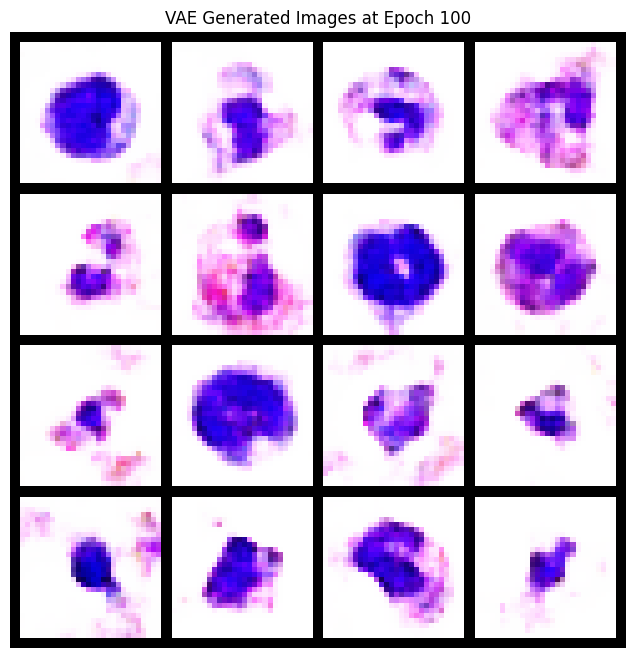

Epoch 100 FID: 169.9198
New best FID: 169.9198
Epoch [101/150] | Loss: 1025.1980 | Reconstruction: 1017.3156 | KLD: 78.8241
Epoch [102/150] | Loss: 1024.9496 | Reconstruction: 1017.0686 | KLD: 78.8108
Epoch [103/150] | Loss: 1024.8132 | Reconstruction: 1016.9289 | KLD: 78.8432
Epoch [104/150] | Loss: 1024.9147 | Reconstruction: 1017.0219 | KLD: 78.9284
Epoch [105/150] | Loss: 1024.8995 | Reconstruction: 1017.0131 | KLD: 78.8635


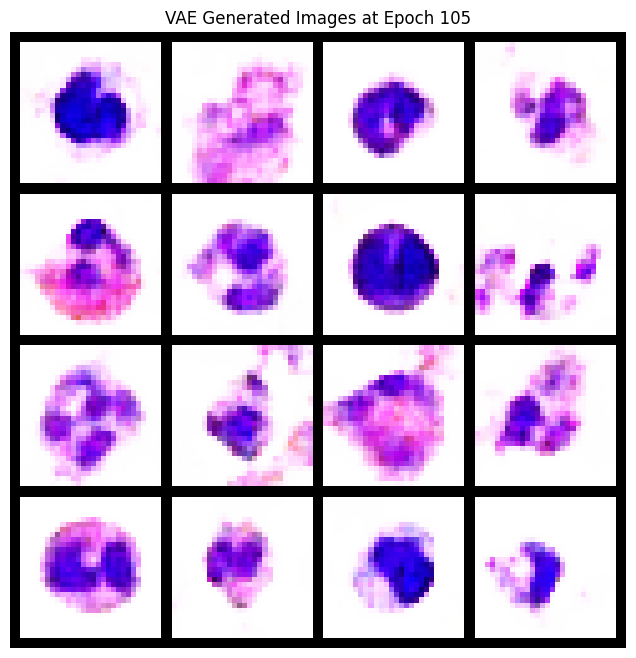

Epoch 105 FID: 171.1914
No improvement for 1 evaluations
Epoch [106/150] | Loss: 1024.7497 | Reconstruction: 1016.8656 | KLD: 78.8402
Epoch [107/150] | Loss: 1024.5197 | Reconstruction: 1016.6383 | KLD: 78.8137
Epoch [108/150] | Loss: 1024.2843 | Reconstruction: 1016.4060 | KLD: 78.7836
Epoch [109/150] | Loss: 1024.0396 | Reconstruction: 1016.1784 | KLD: 78.6119
Epoch [110/150] | Loss: 1023.9819 | Reconstruction: 1016.1235 | KLD: 78.5840


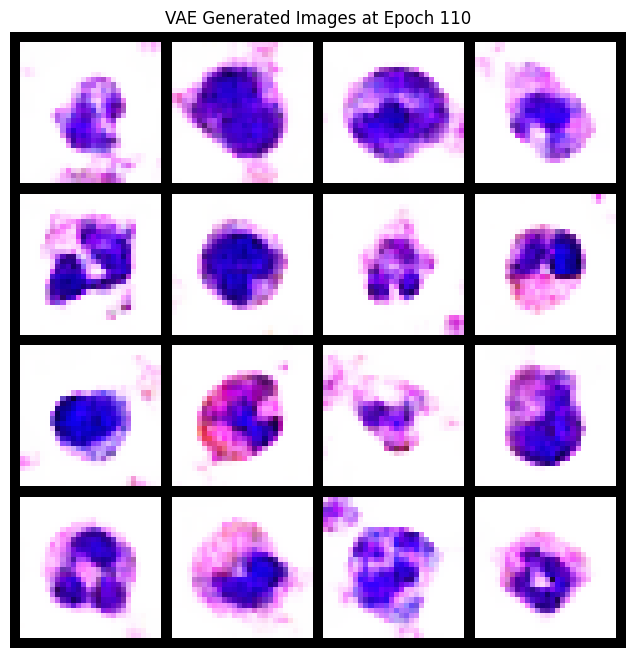

Epoch 110 FID: 172.2730
No improvement for 2 evaluations
Epoch [111/150] | Loss: 1024.2410 | Reconstruction: 1016.3749 | KLD: 78.6619
Epoch [112/150] | Loss: 1023.8843 | Reconstruction: 1016.0109 | KLD: 78.7334
Epoch [113/150] | Loss: 1023.7838 | Reconstruction: 1015.9213 | KLD: 78.6250
Epoch [114/150] | Loss: 1023.8237 | Reconstruction: 1015.9766 | KLD: 78.4704
Epoch [115/150] | Loss: 1023.4475 | Reconstruction: 1015.6055 | KLD: 78.4203


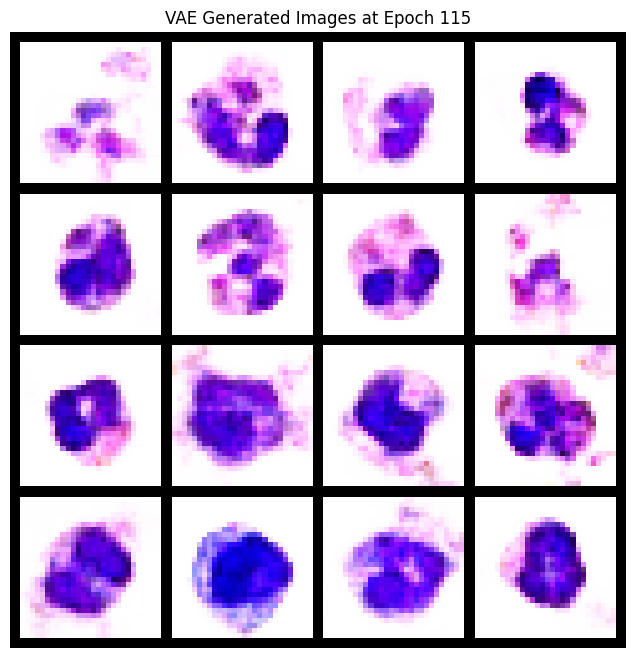

Epoch 115 FID: 168.8412
New best FID: 168.8412
Epoch [116/150] | Loss: 1023.6107 | Reconstruction: 1015.7564 | KLD: 78.5432
Epoch [117/150] | Loss: 1023.2860 | Reconstruction: 1015.4254 | KLD: 78.6056
Epoch [118/150] | Loss: 1023.2239 | Reconstruction: 1015.3726 | KLD: 78.5127
Epoch [119/150] | Loss: 1023.2253 | Reconstruction: 1015.3576 | KLD: 78.6773
Epoch [120/150] | Loss: 1023.1173 | Reconstruction: 1015.2929 | KLD: 78.2436


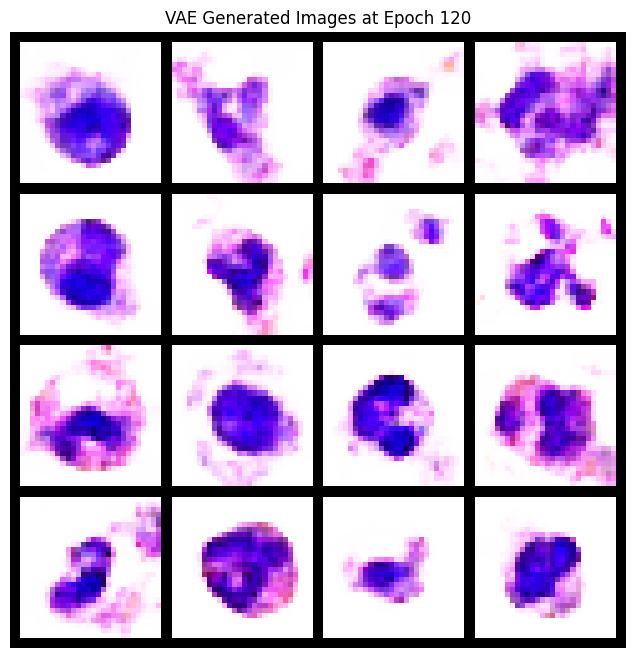

Epoch 120 FID: 171.2831
No improvement for 1 evaluations
Epoch [121/150] | Loss: 1022.6787 | Reconstruction: 1014.8343 | KLD: 78.4441
Epoch [122/150] | Loss: 1022.7803 | Reconstruction: 1014.9334 | KLD: 78.4688
Epoch [123/150] | Loss: 1022.6799 | Reconstruction: 1014.8427 | KLD: 78.3718
Epoch [124/150] | Loss: 1022.6735 | Reconstruction: 1014.8378 | KLD: 78.3572
Epoch [125/150] | Loss: 1022.8934 | Reconstruction: 1015.0341 | KLD: 78.5921


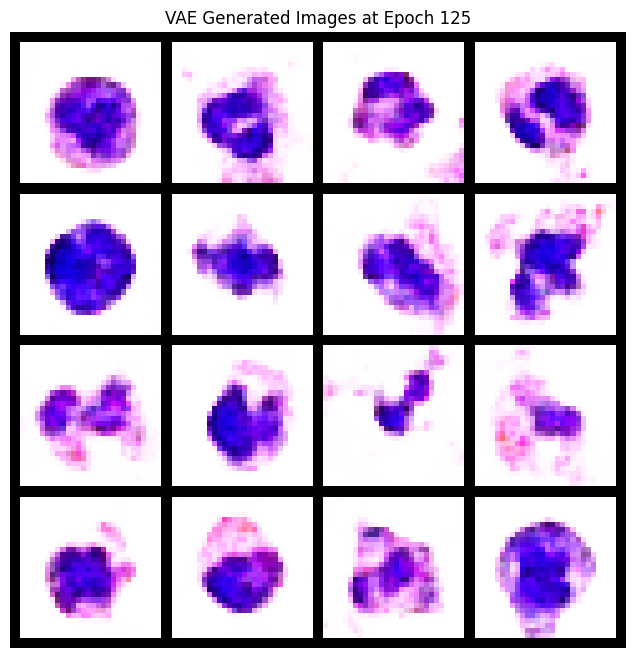

Epoch 125 FID: 169.8730
No improvement for 2 evaluations
Epoch [126/150] | Loss: 1022.5338 | Reconstruction: 1014.6877 | KLD: 78.4614
Epoch [127/150] | Loss: 1023.5643 | Reconstruction: 1015.6951 | KLD: 78.6920
Epoch [128/150] | Loss: 1022.7888 | Reconstruction: 1014.9444 | KLD: 78.4438
Epoch [129/150] | Loss: 1022.2003 | Reconstruction: 1014.3719 | KLD: 78.2841
Epoch [130/150] | Loss: 1022.0671 | Reconstruction: 1014.2286 | KLD: 78.3845


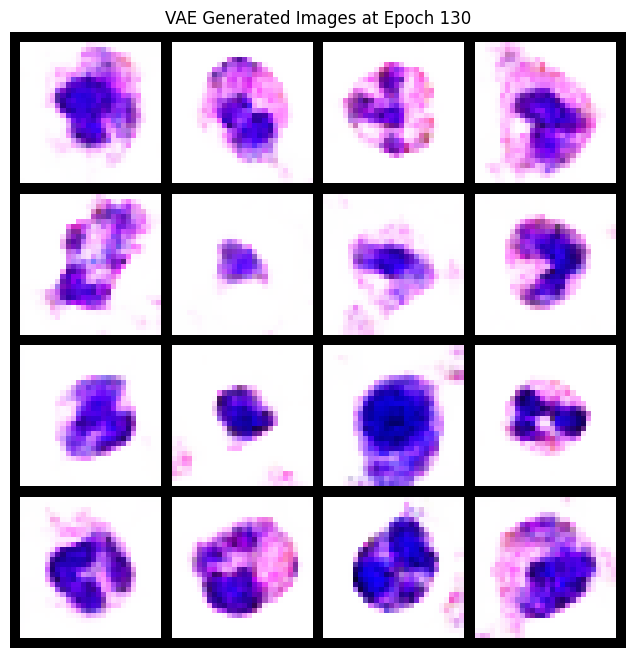

Epoch 130 FID: 171.1071
No improvement for 3 evaluations
Epoch [131/150] | Loss: 1021.9343 | Reconstruction: 1014.1105 | KLD: 78.2378
Epoch [132/150] | Loss: 1021.8868 | Reconstruction: 1014.0596 | KLD: 78.2722
Epoch [133/150] | Loss: 1022.0252 | Reconstruction: 1014.1965 | KLD: 78.2873
Epoch [134/150] | Loss: 1022.0636 | Reconstruction: 1014.2300 | KLD: 78.3355
Epoch [135/150] | Loss: 1021.8968 | Reconstruction: 1014.0725 | KLD: 78.2428


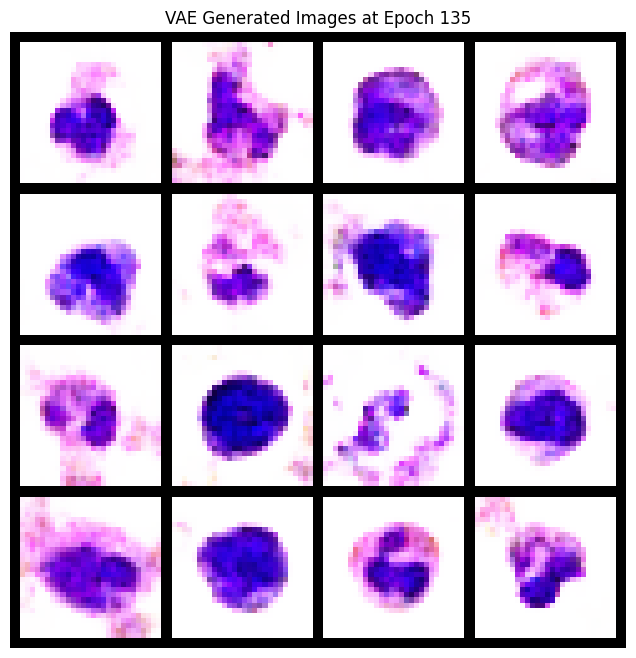

Epoch 135 FID: 173.6186
No improvement for 4 evaluations
Epoch [136/150] | Loss: 1021.6576 | Reconstruction: 1013.8203 | KLD: 78.3730
Epoch [137/150] | Loss: 1021.7375 | Reconstruction: 1013.9170 | KLD: 78.2051
Epoch [138/150] | Loss: 1021.8039 | Reconstruction: 1013.9901 | KLD: 78.1379
Epoch [139/150] | Loss: 1021.6538 | Reconstruction: 1013.8399 | KLD: 78.1385
Epoch [140/150] | Loss: 1021.2812 | Reconstruction: 1013.4701 | KLD: 78.1108


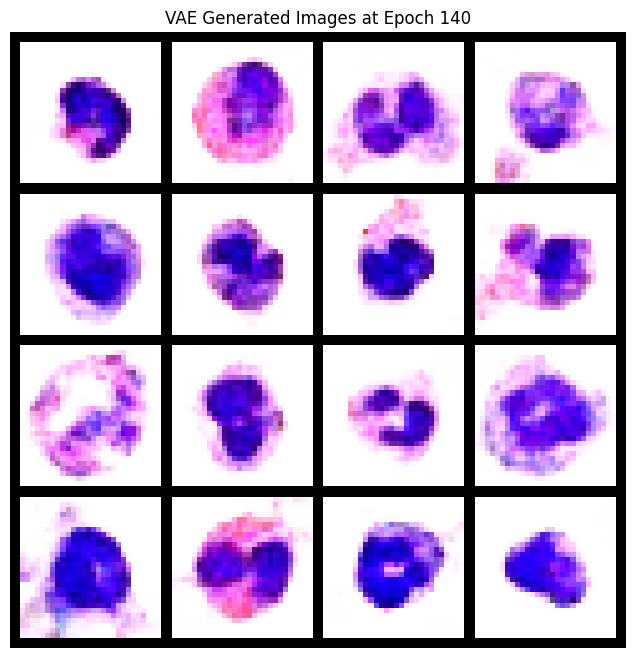

Epoch 140 FID: 170.1386
No improvement for 5 evaluations
Early stopping at epoch 140
VAE FID Score: 161.2908

VAE Hyperparameter combination 3/5
Configuration: {'beta': 0.1, 'beta_schedule': None, 'epochs': 150, 'hidden_dims': [512, 256], 'latent_dim': 128, 'learning_rate': 0.0001}
Starting VAE training with hyperparameters: {'beta': 0.1, 'beta_schedule': None, 'epochs': 150, 'hidden_dims': [512, 256], 'latent_dim': 128, 'learning_rate': 0.0001}
Epoch [1/150] | Loss: 1698.9207 | Reconstruction: 1678.7134 | KLD: 202.0738


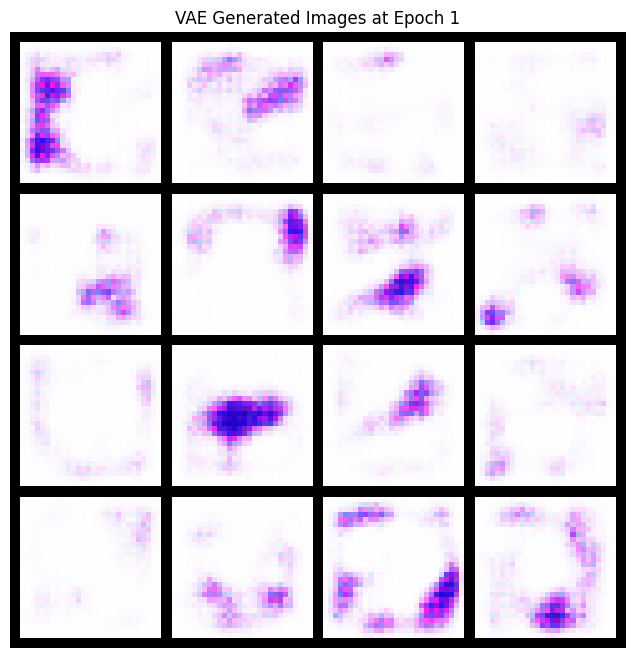

Epoch 1 FID: 343.8531
New best FID: 343.8531
Epoch [2/150] | Loss: 1137.3221 | Reconstruction: 1123.2605 | KLD: 140.6162
Epoch [3/150] | Loss: 1109.5503 | Reconstruction: 1094.7772 | KLD: 147.7305
Epoch [4/150] | Loss: 1095.9125 | Reconstruction: 1080.6912 | KLD: 152.2129
Epoch [5/150] | Loss: 1086.1602 | Reconstruction: 1070.6454 | KLD: 155.1478


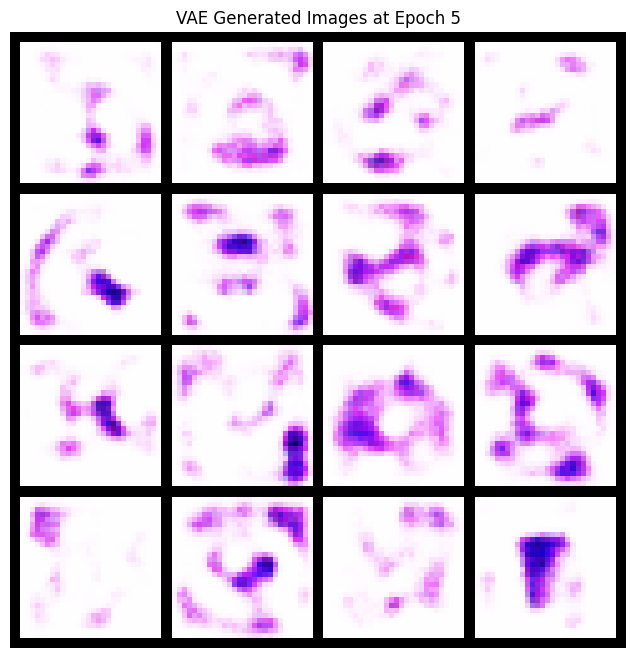

Epoch 5 FID: 240.0253
New best FID: 240.0253
Epoch [6/150] | Loss: 1079.6436 | Reconstruction: 1063.9162 | KLD: 157.2740
Epoch [7/150] | Loss: 1074.3067 | Reconstruction: 1058.4122 | KLD: 158.9443
Epoch [8/150] | Loss: 1070.9450 | Reconstruction: 1054.9534 | KLD: 159.9158
Epoch [9/150] | Loss: 1067.3164 | Reconstruction: 1051.3333 | KLD: 159.8305
Epoch [10/150] | Loss: 1064.2944 | Reconstruction: 1048.2705 | KLD: 160.2384


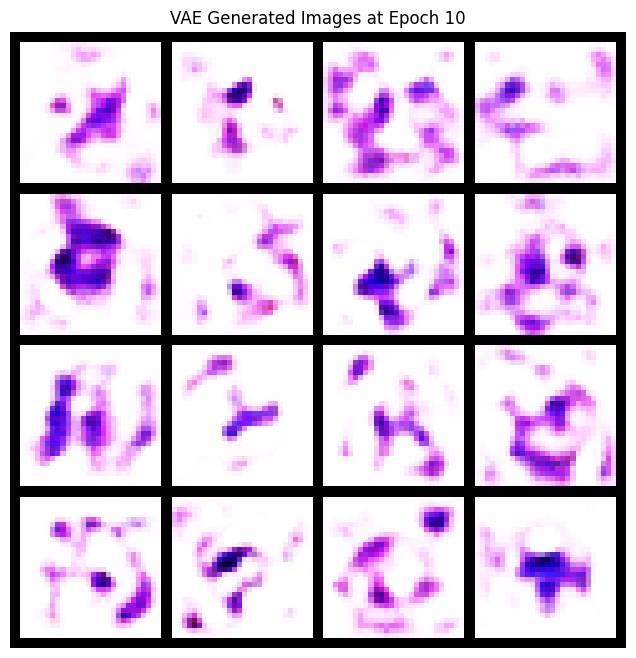

Epoch 10 FID: 210.2800
New best FID: 210.2800
Epoch [11/150] | Loss: 1062.0908 | Reconstruction: 1046.0198 | KLD: 160.7108
Epoch [12/150] | Loss: 1060.1586 | Reconstruction: 1044.0440 | KLD: 161.1455
Epoch [13/150] | Loss: 1057.8987 | Reconstruction: 1041.8337 | KLD: 160.6499
Epoch [14/150] | Loss: 1056.5394 | Reconstruction: 1040.4432 | KLD: 160.9623
Epoch [15/150] | Loss: 1055.2102 | Reconstruction: 1039.1345 | KLD: 160.7577


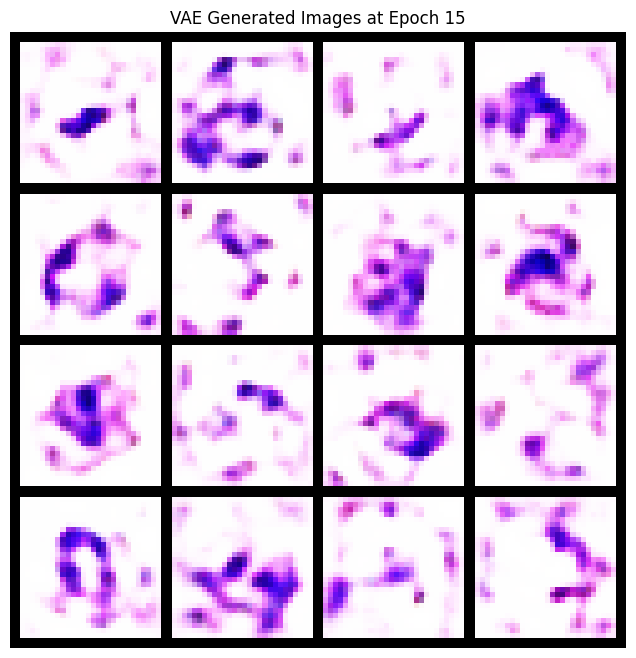

Epoch 15 FID: 200.6798
New best FID: 200.6798
Epoch [16/150] | Loss: 1054.0607 | Reconstruction: 1037.9754 | KLD: 160.8530
Epoch [17/150] | Loss: 1052.5887 | Reconstruction: 1036.5049 | KLD: 160.8377
Epoch [18/150] | Loss: 1051.5038 | Reconstruction: 1035.4611 | KLD: 160.4268
Epoch [19/150] | Loss: 1050.7038 | Reconstruction: 1034.6649 | KLD: 160.3882
Epoch [20/150] | Loss: 1050.0161 | Reconstruction: 1033.9695 | KLD: 160.4663


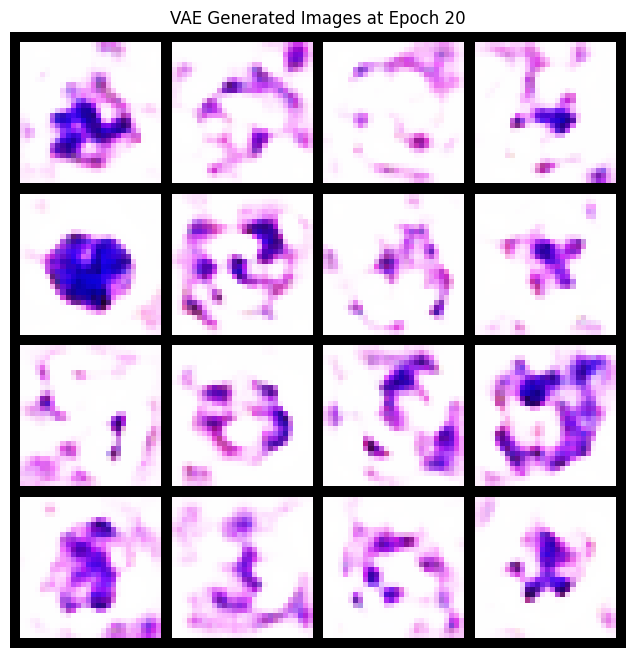

Epoch 20 FID: 197.7466
New best FID: 197.7466
Epoch [21/150] | Loss: 1048.7663 | Reconstruction: 1032.7546 | KLD: 160.1165
Epoch [22/150] | Loss: 1048.5312 | Reconstruction: 1032.5266 | KLD: 160.0463
Epoch [23/150] | Loss: 1047.2633 | Reconstruction: 1031.2410 | KLD: 160.2228
Epoch [24/150] | Loss: 1047.0162 | Reconstruction: 1031.0524 | KLD: 159.6379
Epoch [25/150] | Loss: 1045.9504 | Reconstruction: 1030.0061 | KLD: 159.4427


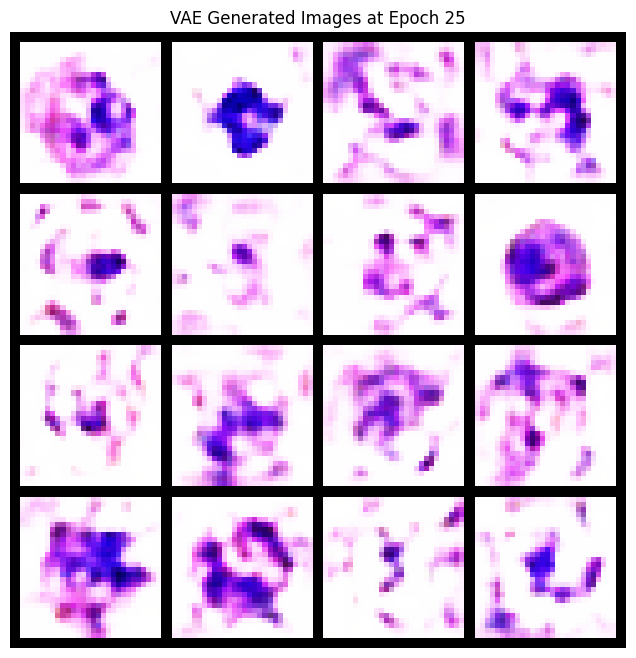

Epoch 25 FID: 192.8384
New best FID: 192.8384
Epoch [26/150] | Loss: 1045.6939 | Reconstruction: 1029.7624 | KLD: 159.3141
Epoch [27/150] | Loss: 1045.0194 | Reconstruction: 1029.0618 | KLD: 159.5757
Epoch [28/150] | Loss: 1044.8284 | Reconstruction: 1028.9009 | KLD: 159.2754
Epoch [29/150] | Loss: 1044.0087 | Reconstruction: 1028.1100 | KLD: 158.9869
Epoch [30/150] | Loss: 1043.4293 | Reconstruction: 1027.5231 | KLD: 159.0628


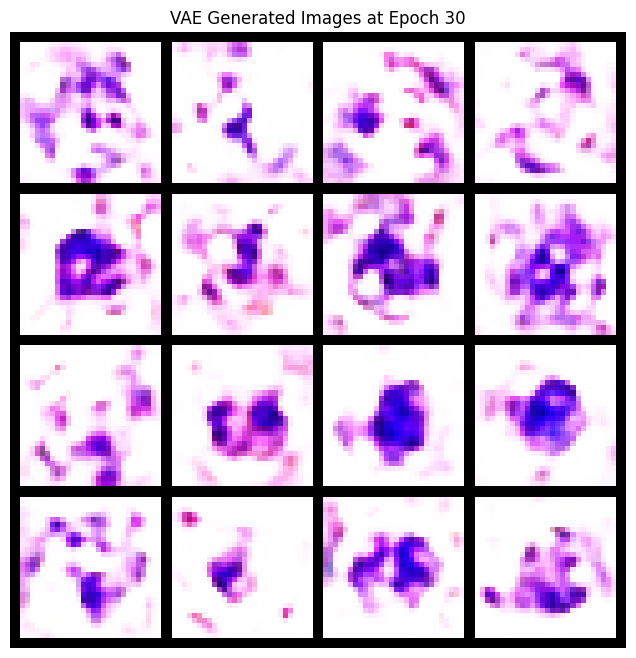

Epoch 30 FID: 190.6887
New best FID: 190.6887
Epoch [31/150] | Loss: 1043.0015 | Reconstruction: 1027.1217 | KLD: 158.7981
Epoch [32/150] | Loss: 1043.0904 | Reconstruction: 1027.1925 | KLD: 158.9786
Epoch [33/150] | Loss: 1042.3907 | Reconstruction: 1026.5355 | KLD: 158.5526
Epoch [34/150] | Loss: 1042.6503 | Reconstruction: 1026.7270 | KLD: 159.2327
Epoch [35/150] | Loss: 1041.4553 | Reconstruction: 1025.5960 | KLD: 158.5929


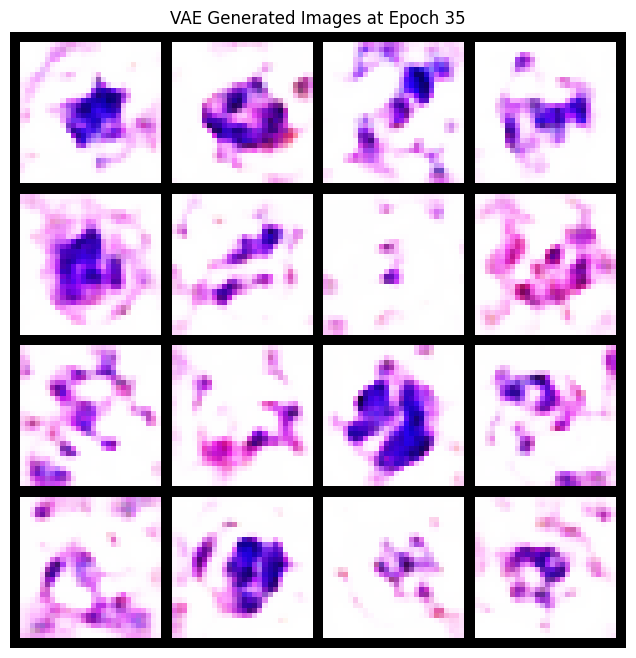

Epoch 35 FID: 185.3762
New best FID: 185.3762
Epoch [36/150] | Loss: 1041.1621 | Reconstruction: 1025.2805 | KLD: 158.8161
Epoch [37/150] | Loss: 1040.5811 | Reconstruction: 1024.7437 | KLD: 158.3744
Epoch [38/150] | Loss: 1040.4065 | Reconstruction: 1024.5597 | KLD: 158.4682
Epoch [39/150] | Loss: 1039.7705 | Reconstruction: 1023.9594 | KLD: 158.1112
Epoch [40/150] | Loss: 1040.2449 | Reconstruction: 1024.4156 | KLD: 158.2931


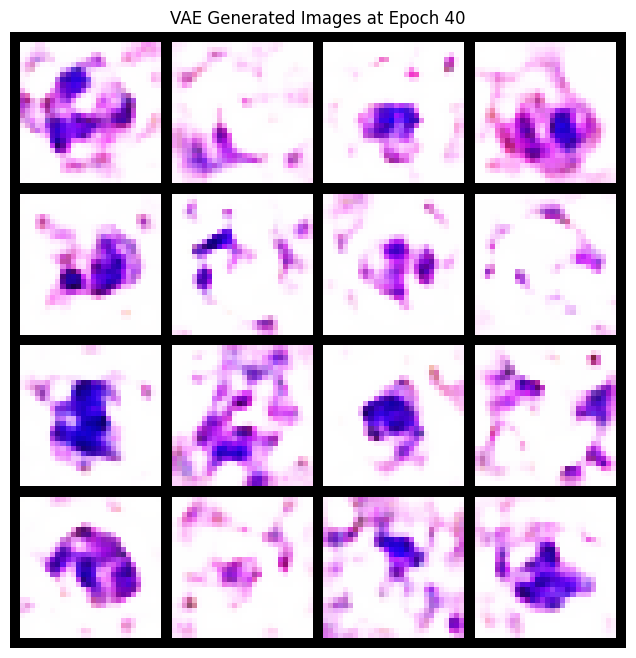

Epoch 40 FID: 182.2982
New best FID: 182.2982
Epoch [41/150] | Loss: 1039.6755 | Reconstruction: 1023.8395 | KLD: 158.3595
Epoch [42/150] | Loss: 1039.1431 | Reconstruction: 1023.3419 | KLD: 158.0122
Epoch [43/150] | Loss: 1038.7331 | Reconstruction: 1022.9085 | KLD: 158.2458
Epoch [44/150] | Loss: 1038.5439 | Reconstruction: 1022.7801 | KLD: 157.6384
Epoch [45/150] | Loss: 1038.3535 | Reconstruction: 1022.5870 | KLD: 157.6653


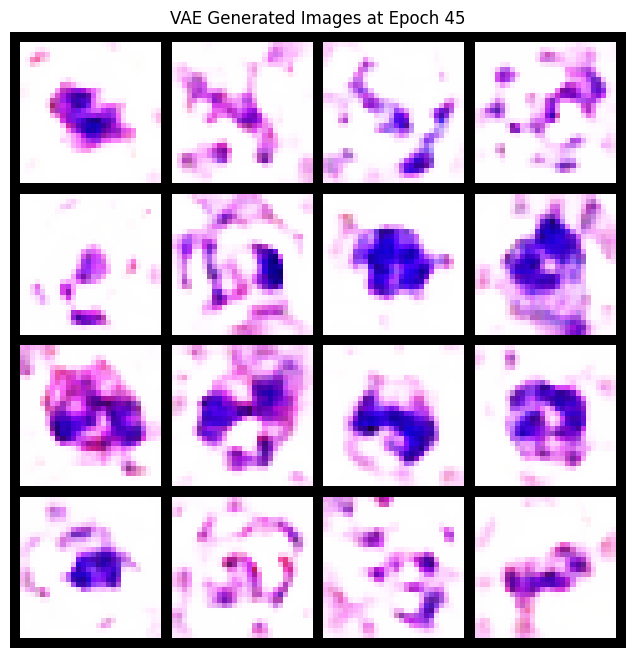

Epoch 45 FID: 180.4167
New best FID: 180.4167
Epoch [46/150] | Loss: 1038.0125 | Reconstruction: 1022.2409 | KLD: 157.7160
Epoch [47/150] | Loss: 1038.2658 | Reconstruction: 1022.4816 | KLD: 157.8425
Epoch [48/150] | Loss: 1037.4962 | Reconstruction: 1021.7250 | KLD: 157.7122
Epoch [49/150] | Loss: 1037.3855 | Reconstruction: 1021.6278 | KLD: 157.5774
Epoch [50/150] | Loss: 1037.1269 | Reconstruction: 1021.3723 | KLD: 157.5464


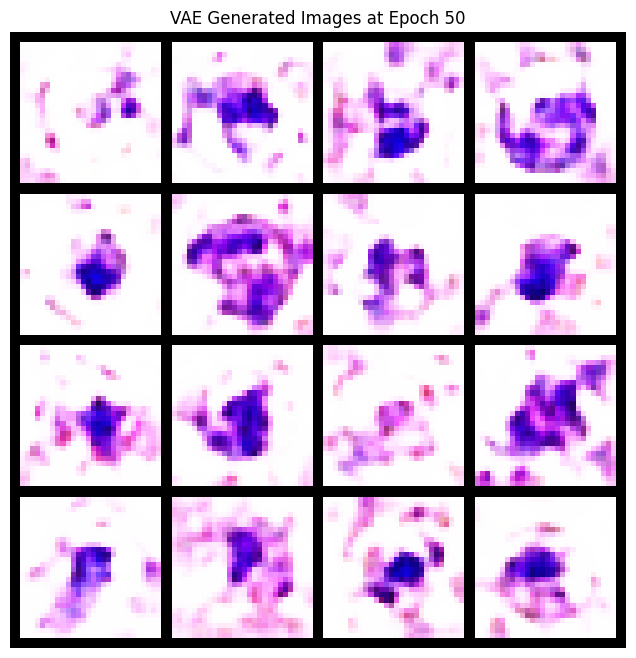

Epoch 50 FID: 180.4117
New best FID: 180.4117
Epoch [51/150] | Loss: 1036.7303 | Reconstruction: 1020.9790 | KLD: 157.5135
Epoch [52/150] | Loss: 1036.4673 | Reconstruction: 1020.7166 | KLD: 157.5072
Epoch [53/150] | Loss: 1036.3249 | Reconstruction: 1020.6054 | KLD: 157.1952
Epoch [54/150] | Loss: 1036.1091 | Reconstruction: 1020.3656 | KLD: 157.4357
Epoch [55/150] | Loss: 1035.6858 | Reconstruction: 1019.9583 | KLD: 157.2741


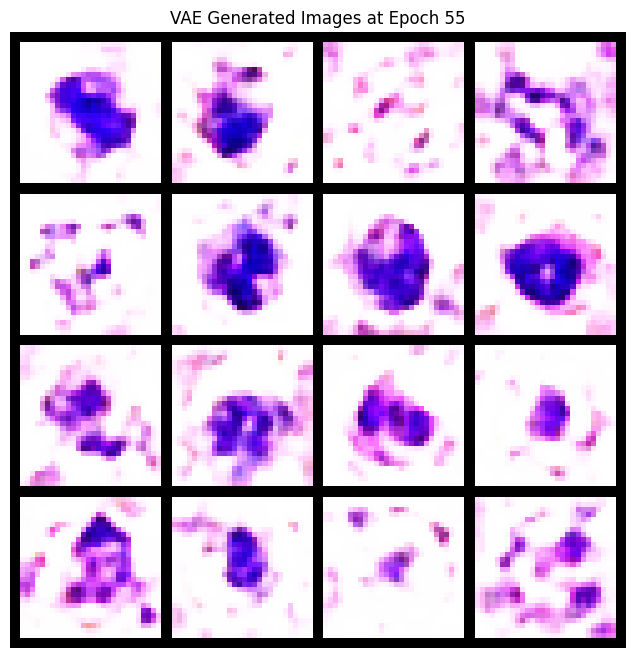

Epoch 55 FID: 181.1841
No improvement for 1 evaluations
Epoch [56/150] | Loss: 1035.9500 | Reconstruction: 1020.2412 | KLD: 157.0888
Epoch [57/150] | Loss: 1036.0912 | Reconstruction: 1020.3545 | KLD: 157.3668
Epoch [58/150] | Loss: 1035.2118 | Reconstruction: 1019.4883 | KLD: 157.2341
Epoch [59/150] | Loss: 1035.2791 | Reconstruction: 1019.5841 | KLD: 156.9492
Epoch [60/150] | Loss: 1035.1139 | Reconstruction: 1019.4230 | KLD: 156.9091


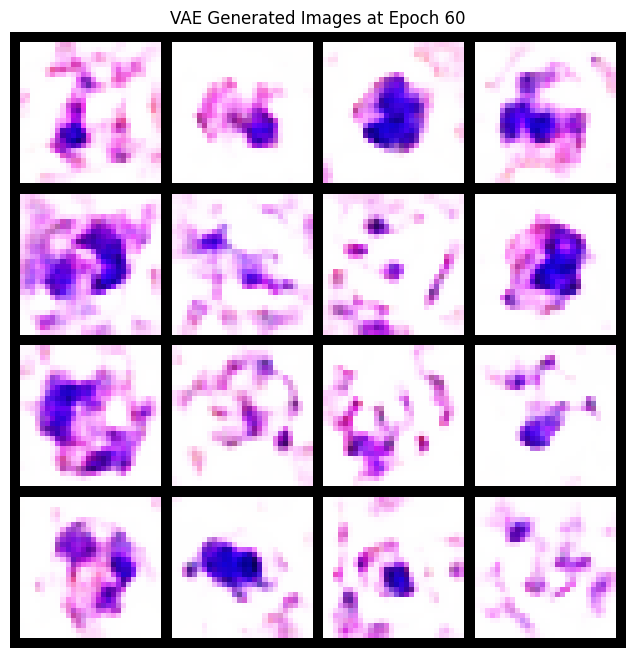

Epoch 60 FID: 176.6930
New best FID: 176.6930
Epoch [61/150] | Loss: 1034.7717 | Reconstruction: 1019.0910 | KLD: 156.8070
Epoch [62/150] | Loss: 1034.3826 | Reconstruction: 1018.7292 | KLD: 156.5346
Epoch [63/150] | Loss: 1034.4626 | Reconstruction: 1018.8242 | KLD: 156.3845
Epoch [64/150] | Loss: 1034.2795 | Reconstruction: 1018.6268 | KLD: 156.5269
Epoch [65/150] | Loss: 1033.9181 | Reconstruction: 1018.2495 | KLD: 156.6869


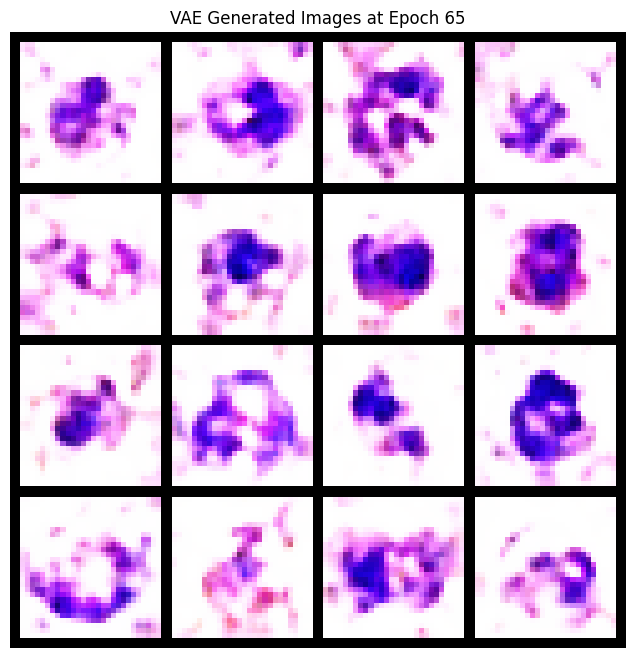

Epoch 65 FID: 178.4776
No improvement for 1 evaluations
Epoch [66/150] | Loss: 1034.3324 | Reconstruction: 1018.6665 | KLD: 156.6588
Epoch [67/150] | Loss: 1033.6375 | Reconstruction: 1017.9930 | KLD: 156.4454
Epoch [68/150] | Loss: 1034.0736 | Reconstruction: 1018.4060 | KLD: 156.6756
Epoch [69/150] | Loss: 1033.2721 | Reconstruction: 1017.6364 | KLD: 156.3569
Epoch [70/150] | Loss: 1033.3390 | Reconstruction: 1017.7337 | KLD: 156.0526


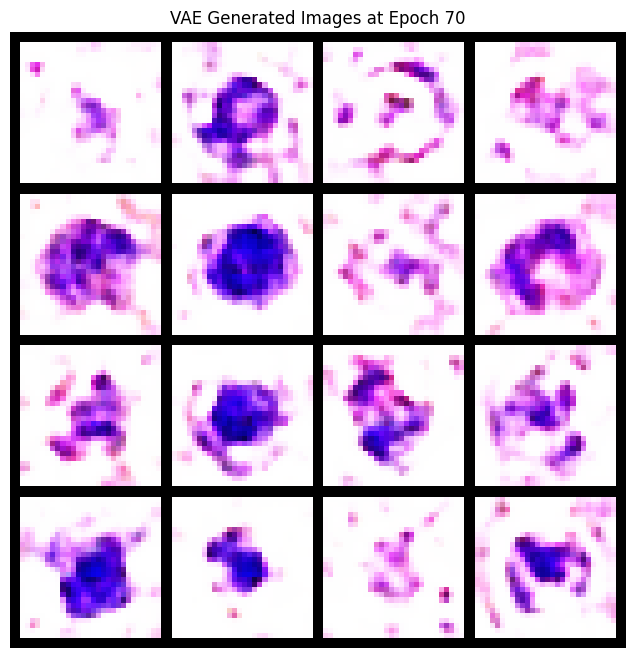

Epoch 70 FID: 179.2935
No improvement for 2 evaluations
Epoch [71/150] | Loss: 1032.9653 | Reconstruction: 1017.3709 | KLD: 155.9446
Epoch [72/150] | Loss: 1033.0539 | Reconstruction: 1017.4517 | KLD: 156.0214
Epoch [73/150] | Loss: 1032.5303 | Reconstruction: 1016.9404 | KLD: 155.8985
Epoch [74/150] | Loss: 1032.6980 | Reconstruction: 1017.1114 | KLD: 155.8652
Epoch [75/150] | Loss: 1032.7059 | Reconstruction: 1017.1077 | KLD: 155.9815


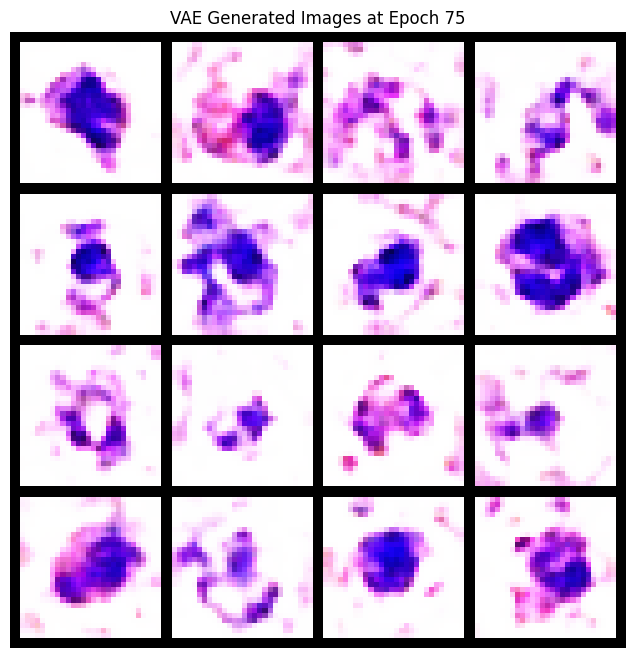

Epoch 75 FID: 175.5831
New best FID: 175.5831
Epoch [76/150] | Loss: 1032.4637 | Reconstruction: 1016.8972 | KLD: 155.6653
Epoch [77/150] | Loss: 1032.1358 | Reconstruction: 1016.5657 | KLD: 155.7007
Epoch [78/150] | Loss: 1031.9586 | Reconstruction: 1016.4077 | KLD: 155.5088
Epoch [79/150] | Loss: 1032.3112 | Reconstruction: 1016.7402 | KLD: 155.7107
Epoch [80/150] | Loss: 1032.4998 | Reconstruction: 1016.9443 | KLD: 155.5544


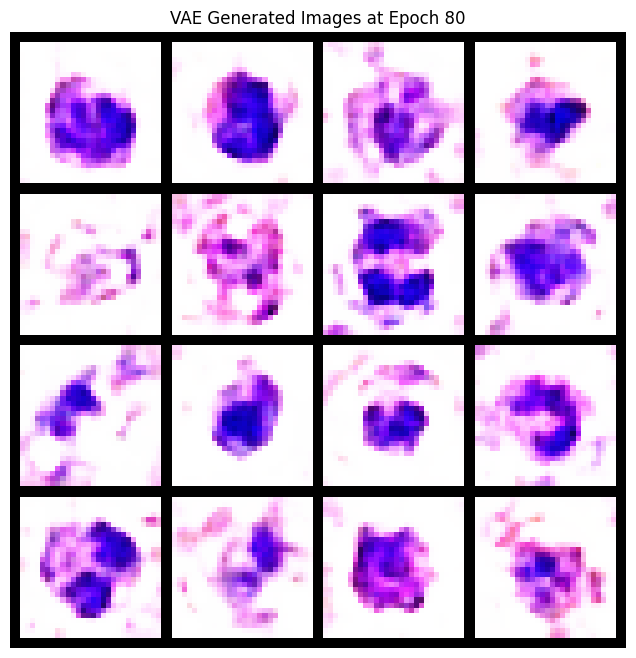

Epoch 80 FID: 176.8249
No improvement for 1 evaluations
Epoch [81/150] | Loss: 1031.7357 | Reconstruction: 1016.1971 | KLD: 155.3859
Epoch [82/150] | Loss: 1031.7940 | Reconstruction: 1016.2713 | KLD: 155.2264
Epoch [83/150] | Loss: 1031.4652 | Reconstruction: 1015.9312 | KLD: 155.3402
Epoch [84/150] | Loss: 1031.3329 | Reconstruction: 1015.8196 | KLD: 155.1328
Epoch [85/150] | Loss: 1031.3435 | Reconstruction: 1015.7991 | KLD: 155.4441


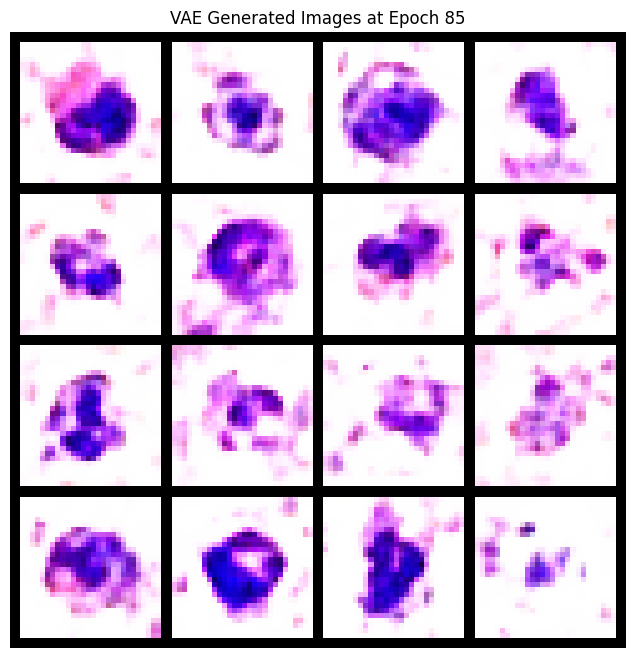

Epoch 85 FID: 178.5766
No improvement for 2 evaluations
Epoch [86/150] | Loss: 1031.2368 | Reconstruction: 1015.7150 | KLD: 155.2185
Epoch [87/150] | Loss: 1031.1046 | Reconstruction: 1015.6111 | KLD: 154.9351
Epoch [88/150] | Loss: 1031.0677 | Reconstruction: 1015.5514 | KLD: 155.1627
Epoch [89/150] | Loss: 1031.0339 | Reconstruction: 1015.5337 | KLD: 155.0021
Epoch [90/150] | Loss: 1030.2839 | Reconstruction: 1014.8223 | KLD: 154.6156


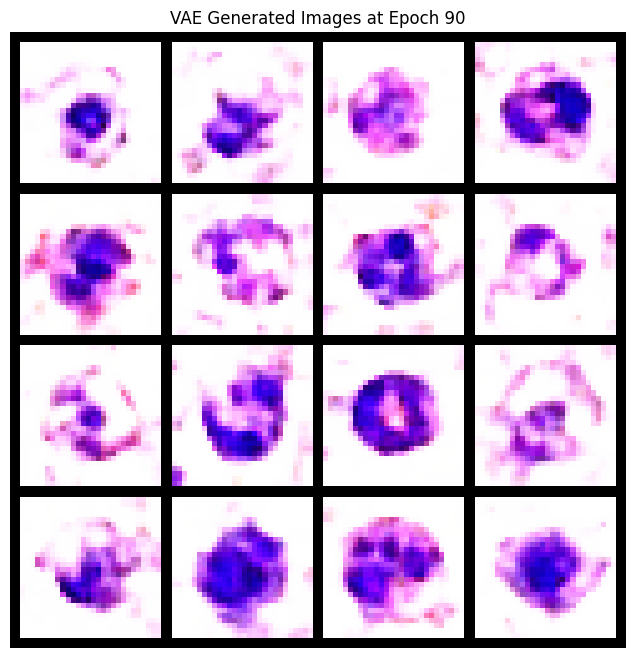

Epoch 90 FID: 181.9164
No improvement for 3 evaluations
Epoch [91/150] | Loss: 1030.3589 | Reconstruction: 1014.9146 | KLD: 154.4428
Epoch [92/150] | Loss: 1030.4050 | Reconstruction: 1014.9422 | KLD: 154.6281
Epoch [93/150] | Loss: 1030.3036 | Reconstruction: 1014.8532 | KLD: 154.5045
Epoch [94/150] | Loss: 1030.2268 | Reconstruction: 1014.8133 | KLD: 154.1355
Epoch [95/150] | Loss: 1030.2694 | Reconstruction: 1014.8363 | KLD: 154.3310


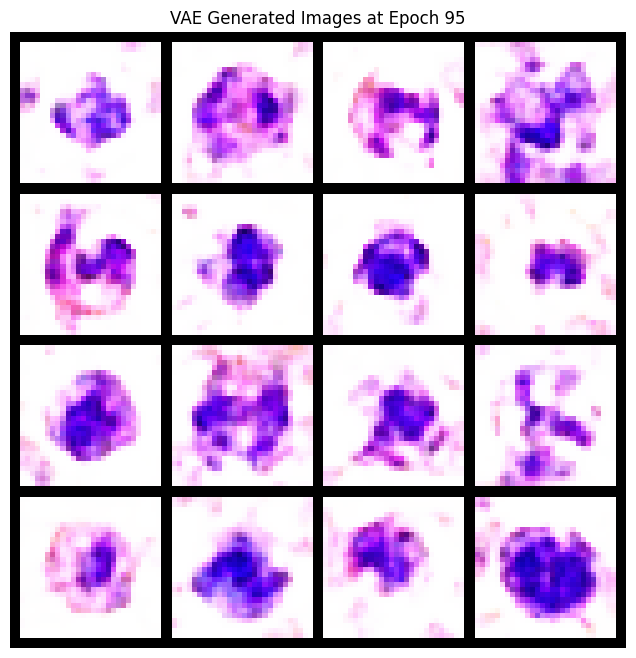

Epoch 95 FID: 177.6149
No improvement for 4 evaluations
Epoch [96/150] | Loss: 1030.1994 | Reconstruction: 1014.7481 | KLD: 154.5140
Epoch [97/150] | Loss: 1029.5940 | Reconstruction: 1014.2019 | KLD: 153.9213
Epoch [98/150] | Loss: 1029.8027 | Reconstruction: 1014.3897 | KLD: 154.1298
Epoch [99/150] | Loss: 1030.0732 | Reconstruction: 1014.6524 | KLD: 154.2087
Epoch [100/150] | Loss: 1029.9367 | Reconstruction: 1014.5310 | KLD: 154.0568


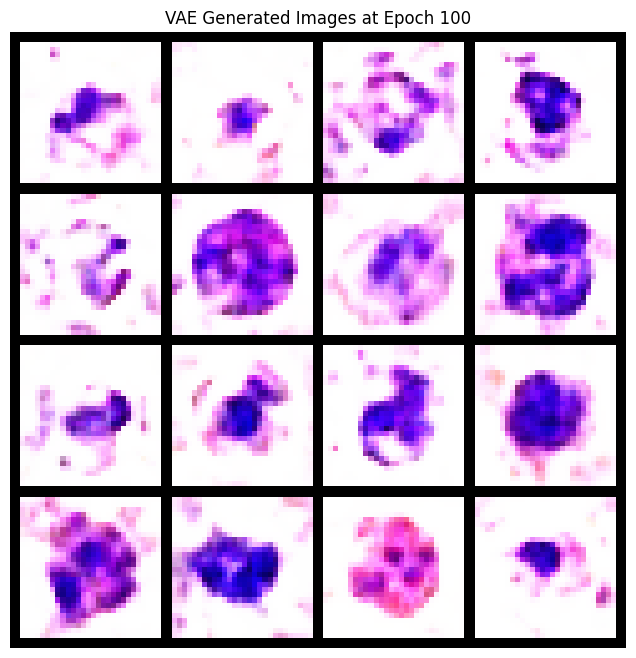

Epoch 100 FID: 176.2123
No improvement for 5 evaluations
Early stopping at epoch 100
VAE FID Score: 159.3400

VAE Hyperparameter combination 4/5
Configuration: {'beta': 0.1, 'beta_schedule': None, 'epochs': 150, 'hidden_dims': [512, 256], 'latent_dim': 128, 'learning_rate': 0.0003}
Starting VAE training with hyperparameters: {'beta': 0.1, 'beta_schedule': None, 'epochs': 150, 'hidden_dims': [512, 256], 'latent_dim': 128, 'learning_rate': 0.0003}
Epoch [1/150] | Loss: 1699.6521 | Reconstruction: 1672.8577 | KLD: 267.9437


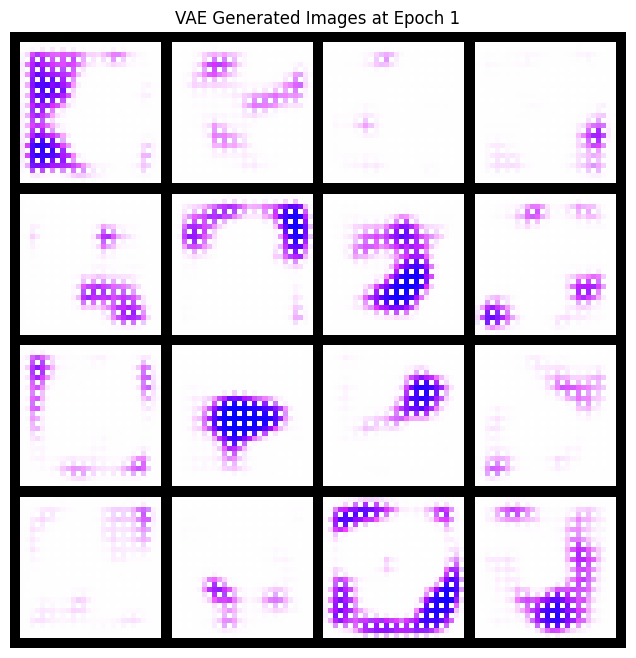

Epoch 1 FID: 351.2549
New best FID: 351.2549
Epoch [2/150] | Loss: 1368.5490 | Reconstruction: 1355.8169 | KLD: 127.3209
Epoch [3/150] | Loss: 1347.5621 | Reconstruction: 1334.7512 | KLD: 128.1092
Epoch [4/150] | Loss: 1323.8616 | Reconstruction: 1310.4412 | KLD: 134.2039
Epoch [5/150] | Loss: 1266.8468 | Reconstruction: 1253.0918 | KLD: 137.5504


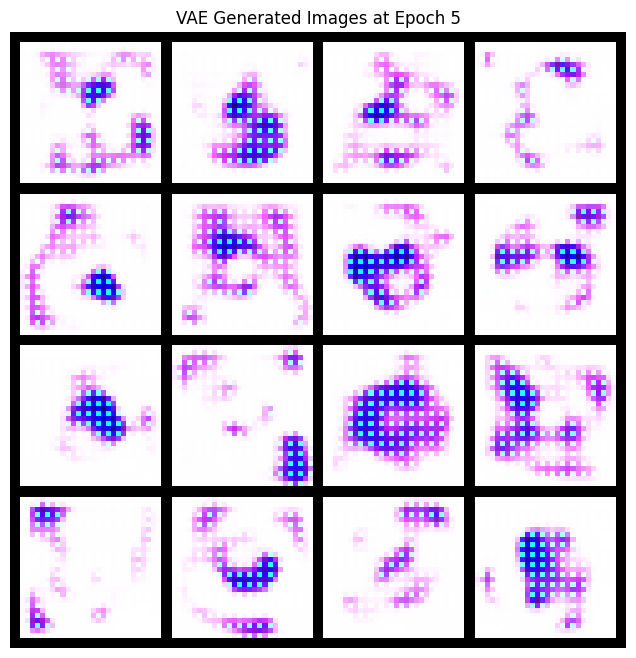

Epoch 5 FID: 317.4079
New best FID: 317.4079
Epoch [6/150] | Loss: 1258.8149 | Reconstruction: 1245.8417 | KLD: 129.7314
Epoch [7/150] | Loss: 1253.5638 | Reconstruction: 1240.8546 | KLD: 127.0927
Epoch [8/150] | Loss: 1251.7084 | Reconstruction: 1238.9964 | KLD: 127.1196
Epoch [9/150] | Loss: 1249.0517 | Reconstruction: 1236.2242 | KLD: 128.2749
Epoch [10/150] | Loss: 1246.0939 | Reconstruction: 1233.4883 | KLD: 126.0566


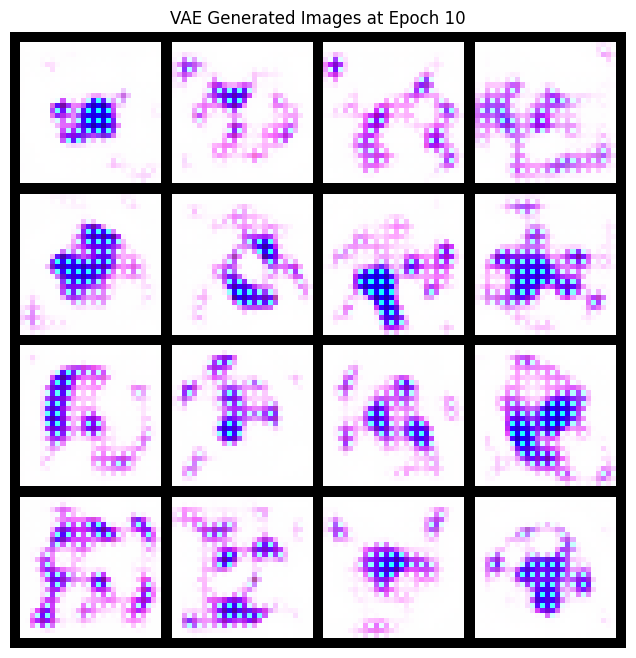

Epoch 10 FID: 323.8874
No improvement for 1 evaluations
Epoch [11/150] | Loss: 1118.7982 | Reconstruction: 1105.4286 | KLD: 133.6968
Epoch [12/150] | Loss: 1073.3284 | Reconstruction: 1059.3213 | KLD: 140.0709
Epoch [13/150] | Loss: 1067.4583 | Reconstruction: 1053.2768 | KLD: 141.8146
Epoch [14/150] | Loss: 1057.1133 | Reconstruction: 1042.8944 | KLD: 142.1890
Epoch [15/150] | Loss: 1053.4709 | Reconstruction: 1039.2051 | KLD: 142.6578


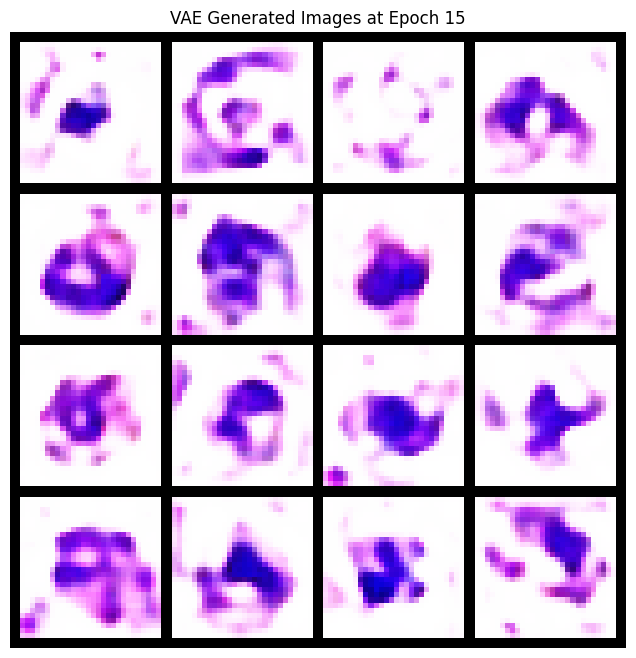

Epoch 15 FID: 177.2683
New best FID: 177.2683
Epoch [16/150] | Loss: 1052.7125 | Reconstruction: 1038.3048 | KLD: 144.0771
Epoch [17/150] | Loss: 1050.2923 | Reconstruction: 1035.9509 | KLD: 143.4134
Epoch [18/150] | Loss: 1049.2089 | Reconstruction: 1034.8522 | KLD: 143.5672
Epoch [19/150] | Loss: 1048.2218 | Reconstruction: 1033.8242 | KLD: 143.9762
Epoch [20/150] | Loss: 1047.8015 | Reconstruction: 1033.3101 | KLD: 144.9147


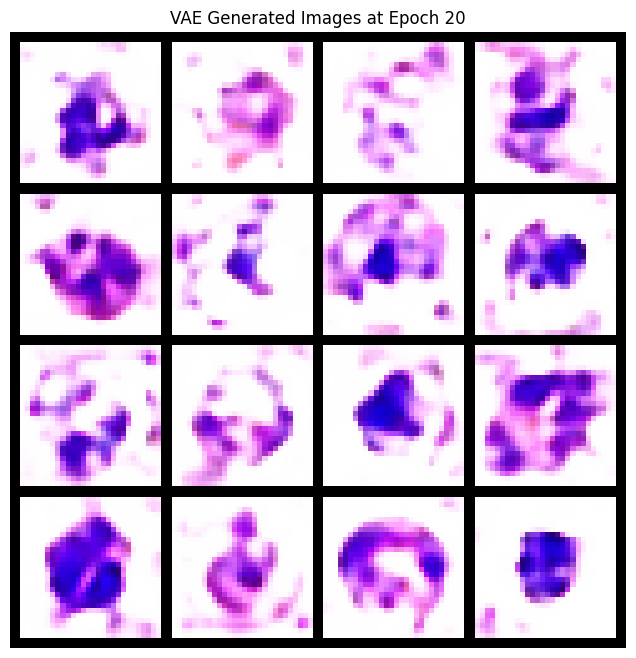

Epoch 20 FID: 171.8449
New best FID: 171.8449
Epoch [21/150] | Loss: 1046.2156 | Reconstruction: 1031.7546 | KLD: 144.6098
Epoch [22/150] | Loss: 1045.8082 | Reconstruction: 1031.4236 | KLD: 143.8463
Epoch [23/150] | Loss: 1044.0334 | Reconstruction: 1029.6621 | KLD: 143.7125
Epoch [24/150] | Loss: 1044.2442 | Reconstruction: 1029.8128 | KLD: 144.3140
Epoch [25/150] | Loss: 1043.2559 | Reconstruction: 1028.8228 | KLD: 144.3308


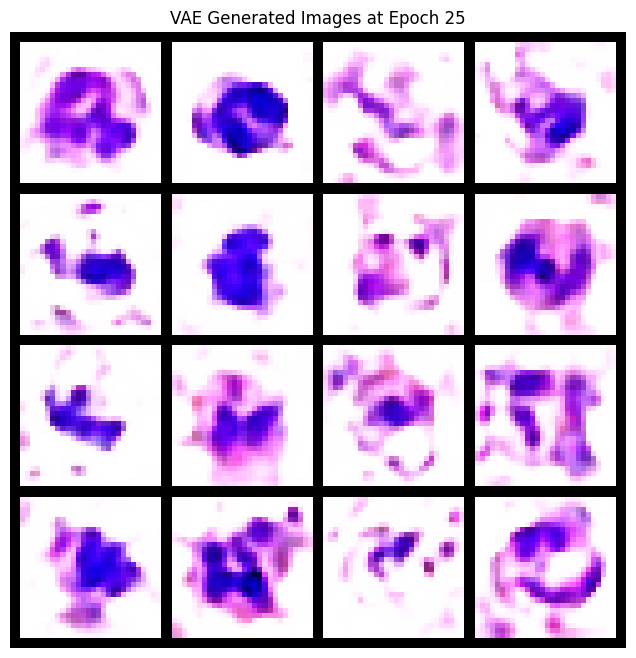

Epoch 25 FID: 166.5899
New best FID: 166.5899
Epoch [26/150] | Loss: 1043.4909 | Reconstruction: 1028.9534 | KLD: 145.3754
Epoch [27/150] | Loss: 1042.4269 | Reconstruction: 1027.8878 | KLD: 145.3902
Epoch [28/150] | Loss: 1042.2665 | Reconstruction: 1027.7156 | KLD: 145.5089
Epoch [29/150] | Loss: 1041.7201 | Reconstruction: 1027.1647 | KLD: 145.5538
Epoch [30/150] | Loss: 1040.9277 | Reconstruction: 1026.4029 | KLD: 145.2476


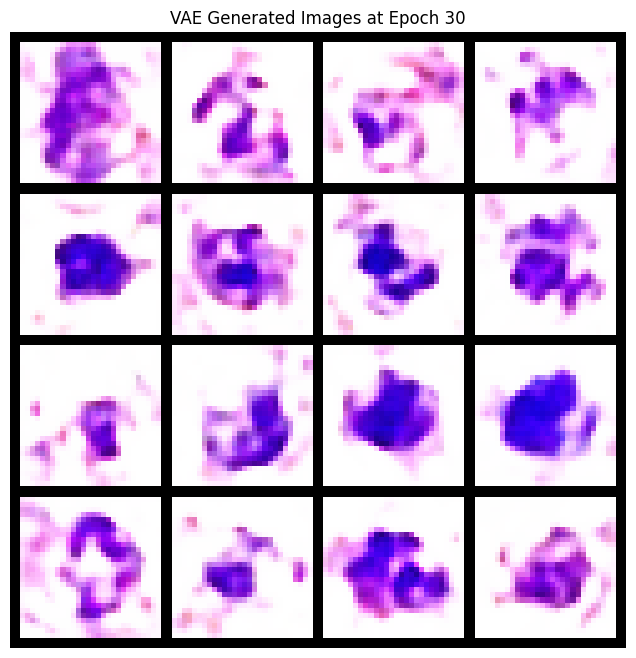

Epoch 30 FID: 165.0514
New best FID: 165.0514
Epoch [31/150] | Loss: 1039.9540 | Reconstruction: 1025.4299 | KLD: 145.2409
Epoch [32/150] | Loss: 1040.9970 | Reconstruction: 1026.3591 | KLD: 146.3791
Epoch [33/150] | Loss: 1039.8348 | Reconstruction: 1025.3100 | KLD: 145.2484
Epoch [34/150] | Loss: 1040.7359 | Reconstruction: 1025.9548 | KLD: 147.8106
Epoch [35/150] | Loss: 1039.1012 | Reconstruction: 1024.5247 | KLD: 145.7658


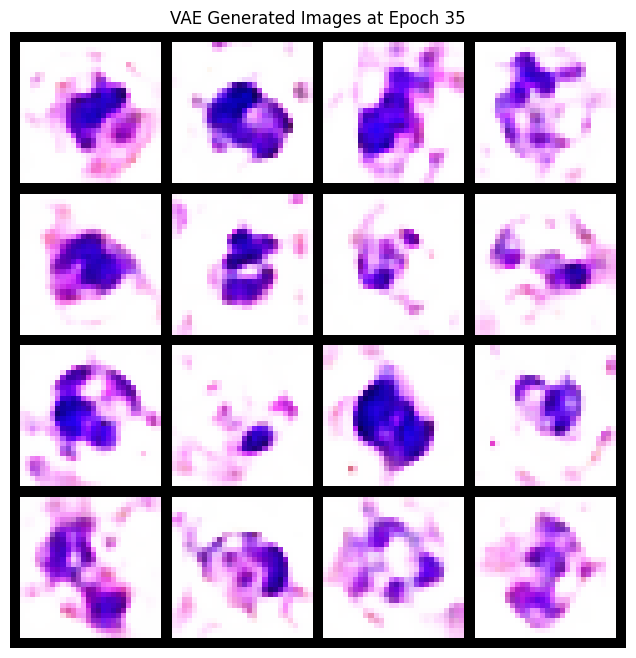

Epoch 35 FID: 163.0523
New best FID: 163.0523
Epoch [36/150] | Loss: 1039.5274 | Reconstruction: 1024.7826 | KLD: 147.4485
Epoch [37/150] | Loss: 1037.7147 | Reconstruction: 1023.1988 | KLD: 145.1592
Epoch [38/150] | Loss: 1037.9591 | Reconstruction: 1023.3694 | KLD: 145.8974
Epoch [39/150] | Loss: 1037.1241 | Reconstruction: 1022.5905 | KLD: 145.3359
Epoch [40/150] | Loss: 1037.4775 | Reconstruction: 1022.8997 | KLD: 145.7785


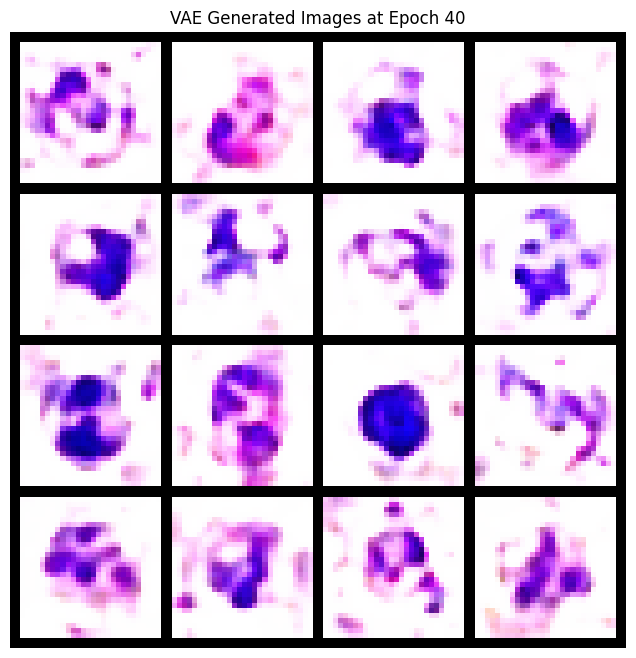

Epoch 40 FID: 163.5587
No improvement for 1 evaluations
Epoch [41/150] | Loss: 1037.8290 | Reconstruction: 1023.0995 | KLD: 147.2945
Epoch [42/150] | Loss: 1036.9051 | Reconstruction: 1022.3052 | KLD: 145.9991
Epoch [43/150] | Loss: 1036.2932 | Reconstruction: 1021.6863 | KLD: 146.0696
Epoch [44/150] | Loss: 1035.8490 | Reconstruction: 1021.2616 | KLD: 145.8740
Epoch [45/150] | Loss: 1035.6387 | Reconstruction: 1021.0490 | KLD: 145.8968


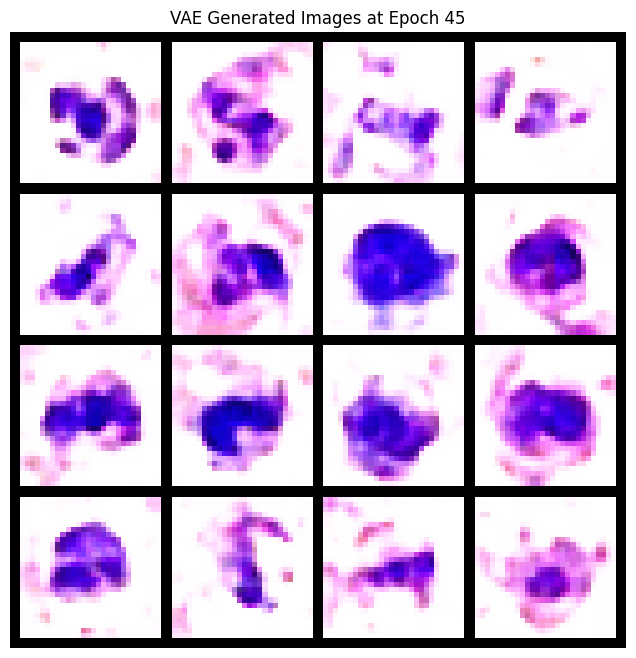

Epoch 45 FID: 164.1054
No improvement for 2 evaluations
Epoch [46/150] | Loss: 1035.2265 | Reconstruction: 1020.6620 | KLD: 145.6457
Epoch [47/150] | Loss: 1035.1890 | Reconstruction: 1020.6179 | KLD: 145.7107
Epoch [48/150] | Loss: 1034.8866 | Reconstruction: 1020.2936 | KLD: 145.9304
Epoch [49/150] | Loss: 1034.5740 | Reconstruction: 1019.9911 | KLD: 145.8295
Epoch [50/150] | Loss: 1034.5554 | Reconstruction: 1019.9591 | KLD: 145.9623


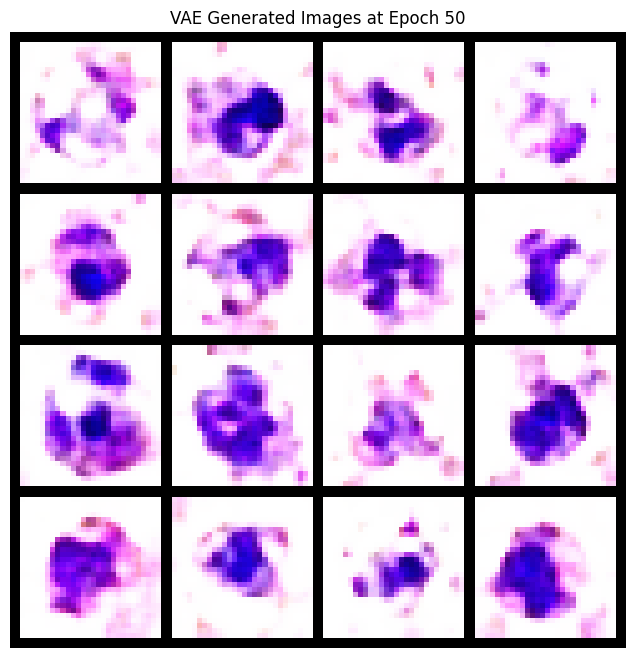

Epoch 50 FID: 166.8861
No improvement for 3 evaluations
Epoch [51/150] | Loss: 1034.2046 | Reconstruction: 1019.6179 | KLD: 145.8667
Epoch [52/150] | Loss: 1033.4278 | Reconstruction: 1018.8886 | KLD: 145.3914
Epoch [53/150] | Loss: 1033.4039 | Reconstruction: 1018.8547 | KLD: 145.4918
Epoch [54/150] | Loss: 1033.0811 | Reconstruction: 1018.5156 | KLD: 145.6550
Epoch [55/150] | Loss: 1032.7124 | Reconstruction: 1018.1764 | KLD: 145.3599


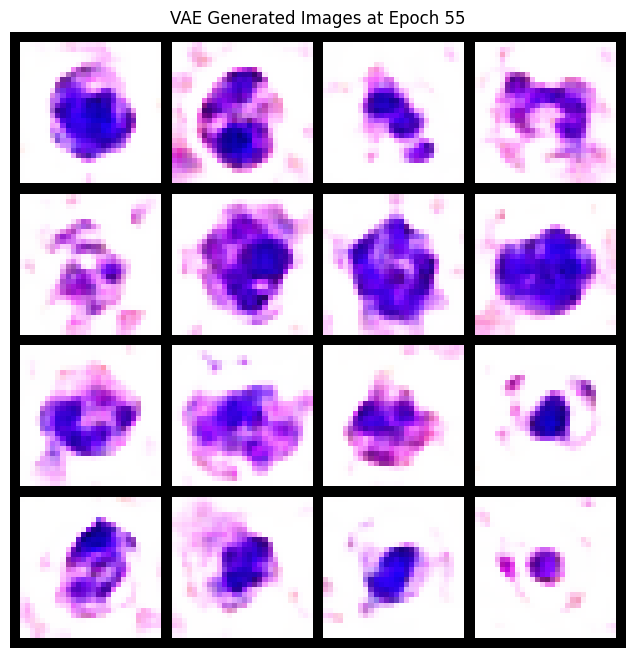

Epoch 55 FID: 170.1445
No improvement for 4 evaluations
Epoch [56/150] | Loss: 1033.1655 | Reconstruction: 1018.6172 | KLD: 145.4826
Epoch [57/150] | Loss: 1033.7502 | Reconstruction: 1019.1192 | KLD: 146.3100
Epoch [58/150] | Loss: 1032.6772 | Reconstruction: 1018.1094 | KLD: 145.6784
Epoch [59/150] | Loss: 1032.1032 | Reconstruction: 1017.5647 | KLD: 145.3855
Epoch [60/150] | Loss: 1032.1275 | Reconstruction: 1017.5917 | KLD: 145.3572


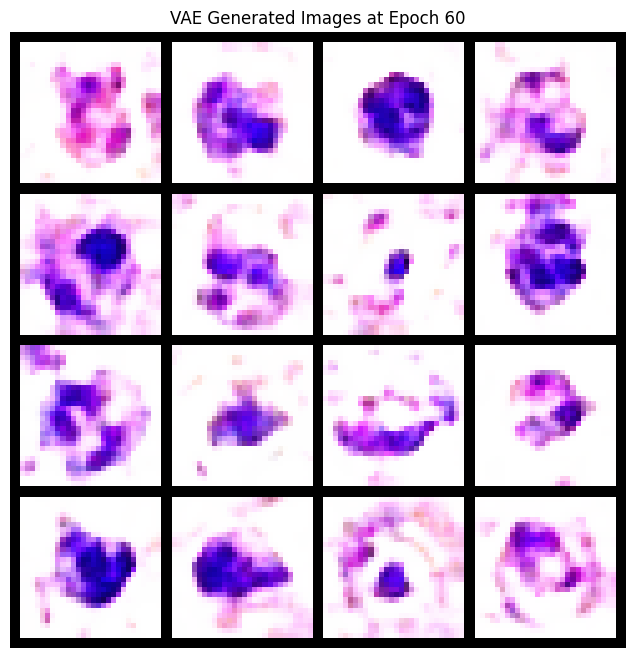

Epoch 60 FID: 166.7866
No improvement for 5 evaluations
Early stopping at epoch 60
VAE FID Score: 150.8550

VAE Hyperparameter combination 5/5
Configuration: {'beta': 0.1, 'beta_schedule': None, 'epochs': 150, 'hidden_dims': [1024, 512, 256], 'latent_dim': 32, 'learning_rate': 0.0001}
Starting VAE training with hyperparameters: {'beta': 0.1, 'beta_schedule': None, 'epochs': 150, 'hidden_dims': [1024, 512, 256], 'latent_dim': 32, 'learning_rate': 0.0001}
Epoch [1/150] | Loss: 1400.8231 | Reconstruction: 1394.9596 | KLD: 58.6349


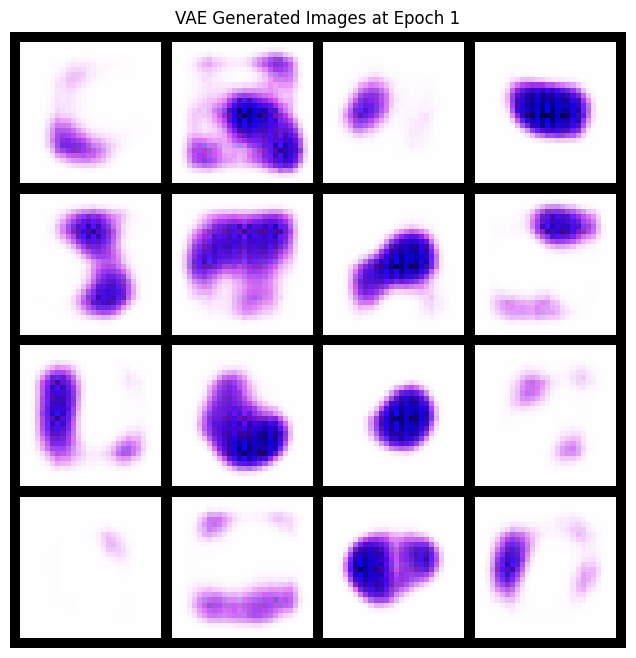

Epoch 1 FID: 321.4424
New best FID: 321.4424
Epoch [2/150] | Loss: 1154.1871 | Reconstruction: 1147.5054 | KLD: 66.8169
Epoch [3/150] | Loss: 1117.3808 | Reconstruction: 1109.9975 | KLD: 73.8334
Epoch [4/150] | Loss: 1096.1227 | Reconstruction: 1088.6008 | KLD: 75.2185
Epoch [5/150] | Loss: 1085.6548 | Reconstruction: 1077.9982 | KLD: 76.5662


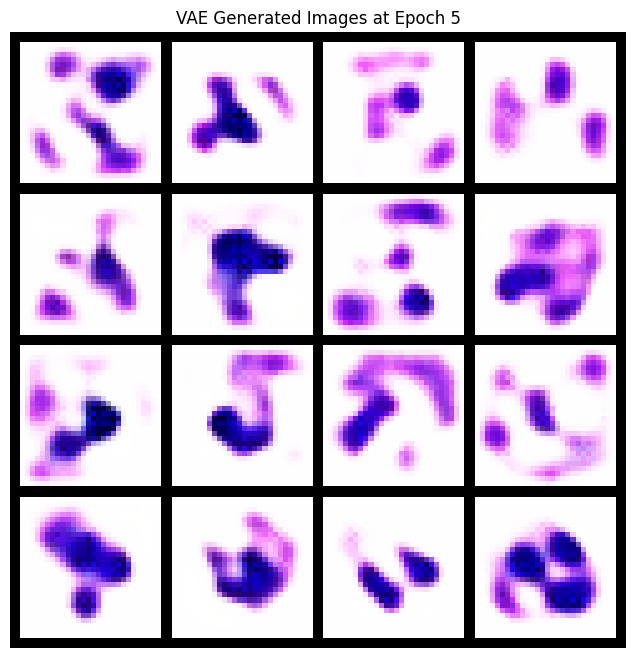

Epoch 5 FID: 200.5540
New best FID: 200.5540
Epoch [6/150] | Loss: 1078.4176 | Reconstruction: 1070.6510 | KLD: 77.6657
Epoch [7/150] | Loss: 1072.3843 | Reconstruction: 1064.5635 | KLD: 78.2079
Epoch [8/150] | Loss: 1068.6130 | Reconstruction: 1060.7894 | KLD: 78.2363
Epoch [9/150] | Loss: 1065.6684 | Reconstruction: 1057.8425 | KLD: 78.2593
Epoch [10/150] | Loss: 1062.7134 | Reconstruction: 1054.8607 | KLD: 78.5263


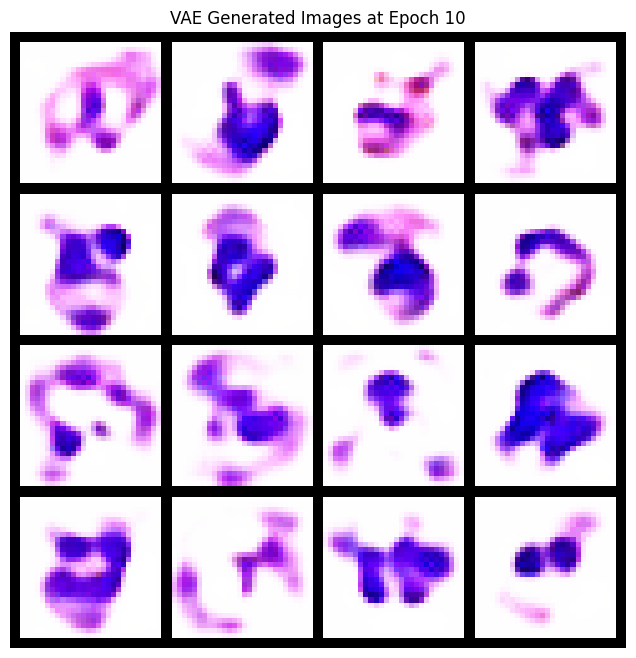

Epoch 10 FID: 190.9380
New best FID: 190.9380
Epoch [11/150] | Loss: 1062.4395 | Reconstruction: 1054.6007 | KLD: 78.3881
Epoch [12/150] | Loss: 1059.7881 | Reconstruction: 1051.9392 | KLD: 78.4886
Epoch [13/150] | Loss: 1058.6566 | Reconstruction: 1050.8540 | KLD: 78.0259
Epoch [14/150] | Loss: 1056.8944 | Reconstruction: 1049.0531 | KLD: 78.4134
Epoch [15/150] | Loss: 1054.7535 | Reconstruction: 1046.9165 | KLD: 78.3697


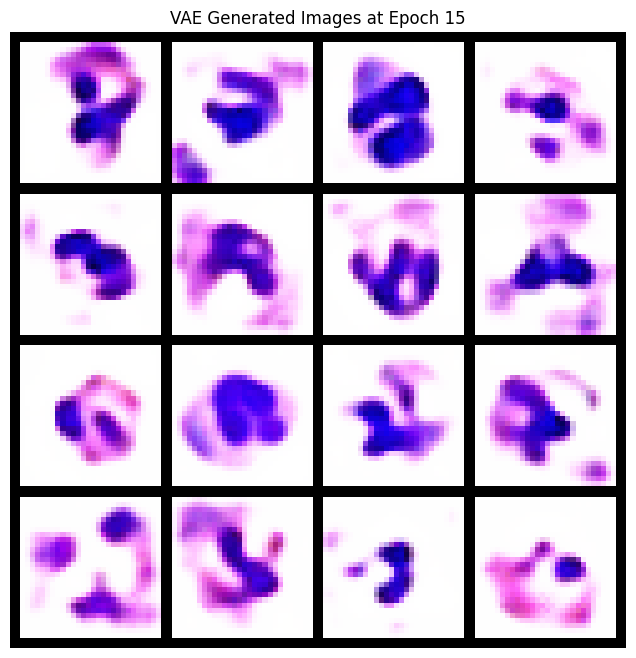

Epoch 15 FID: 185.1737
New best FID: 185.1737
Epoch [16/150] | Loss: 1052.9729 | Reconstruction: 1045.1310 | KLD: 78.4180
Epoch [17/150] | Loss: 1052.0711 | Reconstruction: 1044.2470 | KLD: 78.2411
Epoch [18/150] | Loss: 1051.0687 | Reconstruction: 1043.2602 | KLD: 78.0848
Epoch [19/150] | Loss: 1050.4471 | Reconstruction: 1042.6447 | KLD: 78.0239
Epoch [20/150] | Loss: 1049.2346 | Reconstruction: 1041.4110 | KLD: 78.2359


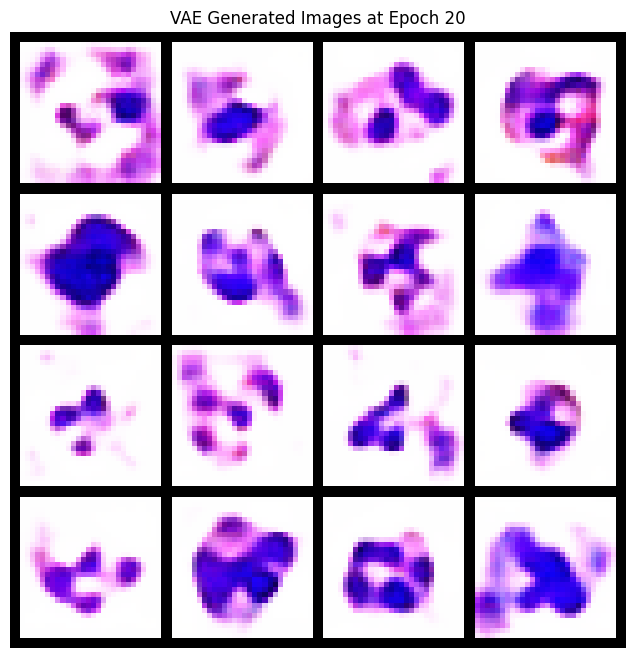

Epoch 20 FID: 182.8737
New best FID: 182.8737
Epoch [21/150] | Loss: 1048.3829 | Reconstruction: 1040.5913 | KLD: 77.9152
Epoch [22/150] | Loss: 1048.2317 | Reconstruction: 1040.4547 | KLD: 77.7701
Epoch [23/150] | Loss: 1047.1246 | Reconstruction: 1039.3333 | KLD: 77.9133
Epoch [24/150] | Loss: 1046.7136 | Reconstruction: 1038.9289 | KLD: 77.8464
Epoch [25/150] | Loss: 1045.9956 | Reconstruction: 1038.2343 | KLD: 77.6126


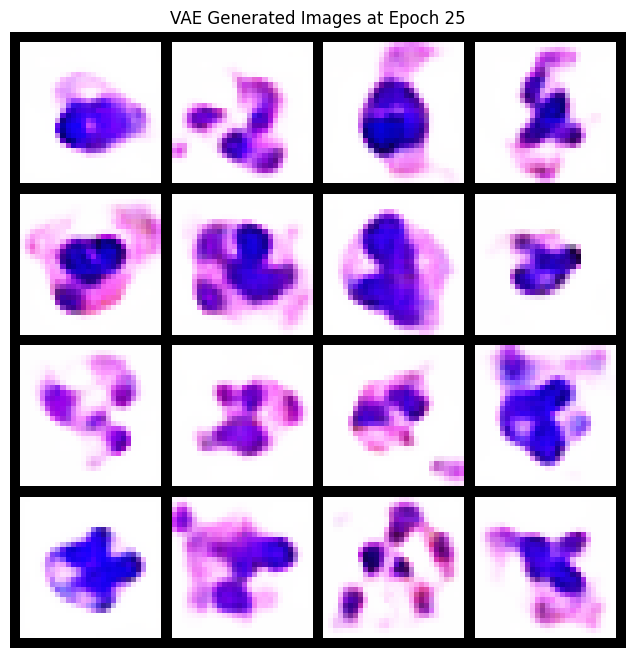

Epoch 25 FID: 180.6901
New best FID: 180.6901
Epoch [26/150] | Loss: 1045.4204 | Reconstruction: 1037.6419 | KLD: 77.7851
Epoch [27/150] | Loss: 1044.7118 | Reconstruction: 1036.9384 | KLD: 77.7337
Epoch [28/150] | Loss: 1044.3318 | Reconstruction: 1036.5643 | KLD: 77.6743
Epoch [29/150] | Loss: 1043.9113 | Reconstruction: 1036.1455 | KLD: 77.6575
Epoch [30/150] | Loss: 1043.2095 | Reconstruction: 1035.4417 | KLD: 77.6787


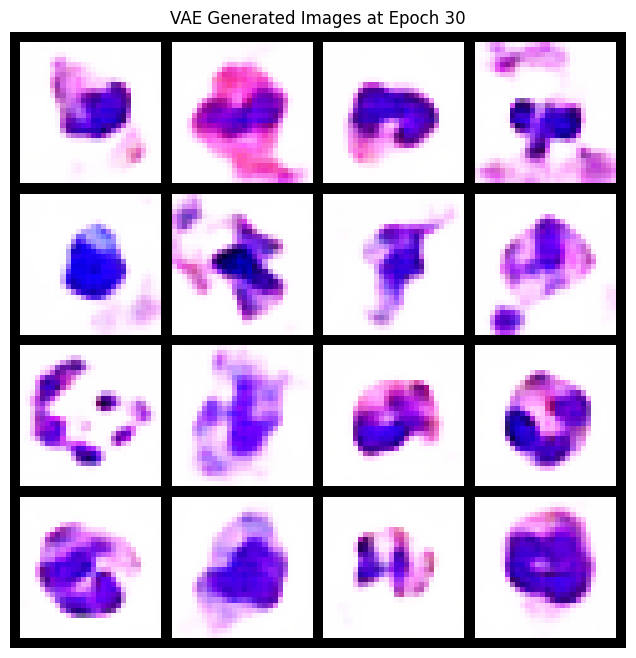

Epoch 30 FID: 180.1141
New best FID: 180.1141
Epoch [31/150] | Loss: 1042.8803 | Reconstruction: 1035.1329 | KLD: 77.4733
Epoch [32/150] | Loss: 1041.8740 | Reconstruction: 1034.1097 | KLD: 77.6425
Epoch [33/150] | Loss: 1041.5796 | Reconstruction: 1033.8139 | KLD: 77.6574
Epoch [34/150] | Loss: 1041.2407 | Reconstruction: 1033.4830 | KLD: 77.5770
Epoch [35/150] | Loss: 1040.6532 | Reconstruction: 1032.9067 | KLD: 77.4652


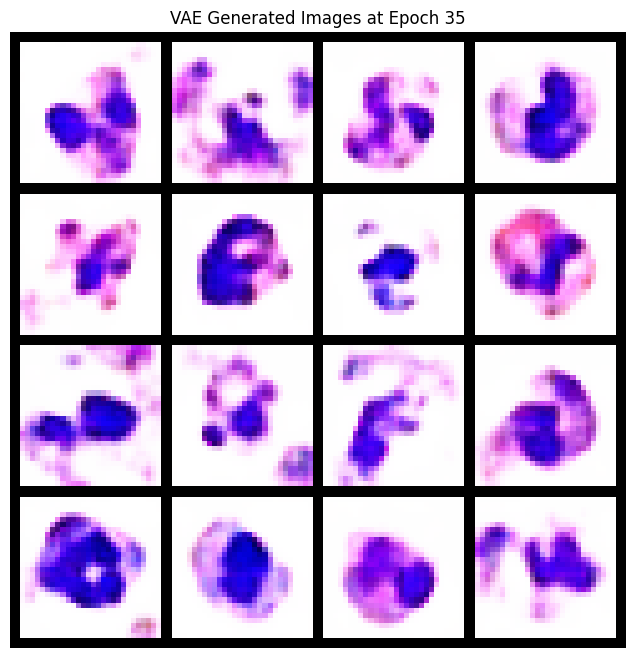

Epoch 35 FID: 175.1941
New best FID: 175.1941
Epoch [36/150] | Loss: 1039.7275 | Reconstruction: 1031.9505 | KLD: 77.7703
Epoch [37/150] | Loss: 1039.2235 | Reconstruction: 1031.4619 | KLD: 77.6158
Epoch [38/150] | Loss: 1038.8086 | Reconstruction: 1031.0637 | KLD: 77.4493
Epoch [39/150] | Loss: 1038.0338 | Reconstruction: 1030.2786 | KLD: 77.5522
Epoch [40/150] | Loss: 1038.0202 | Reconstruction: 1030.2541 | KLD: 77.6613


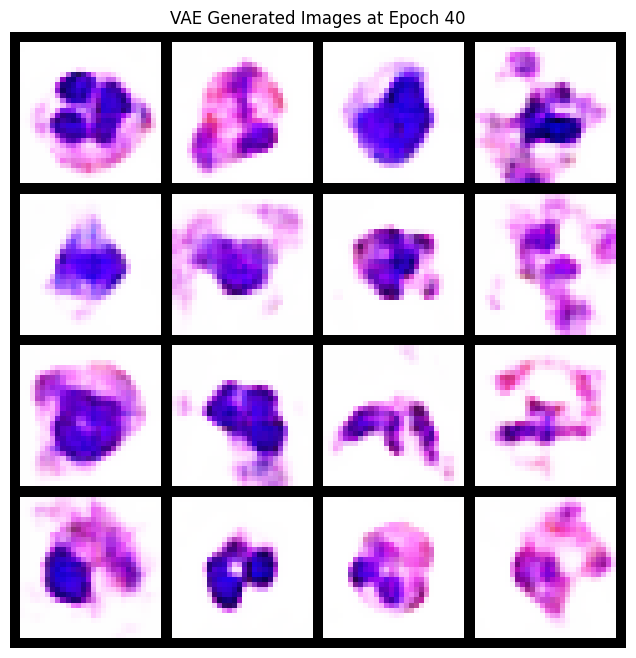

Epoch 40 FID: 179.0423
No improvement for 1 evaluations
Epoch [41/150] | Loss: 1037.9281 | Reconstruction: 1030.1619 | KLD: 77.6618
Epoch [42/150] | Loss: 1036.8139 | Reconstruction: 1029.0613 | KLD: 77.5255
Epoch [43/150] | Loss: 1036.3455 | Reconstruction: 1028.5873 | KLD: 77.5814
Epoch [44/150] | Loss: 1035.5726 | Reconstruction: 1027.8246 | KLD: 77.4804
Epoch [45/150] | Loss: 1035.2489 | Reconstruction: 1027.4928 | KLD: 77.5603


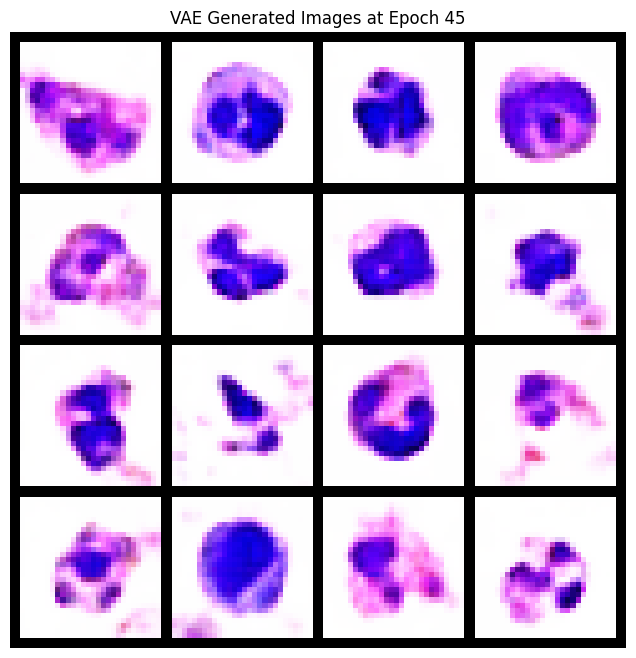

Epoch 45 FID: 175.8853
No improvement for 2 evaluations
Epoch [46/150] | Loss: 1034.8542 | Reconstruction: 1027.1118 | KLD: 77.4245
Epoch [47/150] | Loss: 1034.5974 | Reconstruction: 1026.8405 | KLD: 77.5696
Epoch [48/150] | Loss: 1033.7260 | Reconstruction: 1025.9727 | KLD: 77.5321
Epoch [49/150] | Loss: 1033.8130 | Reconstruction: 1026.0630 | KLD: 77.5007
Epoch [50/150] | Loss: 1033.7114 | Reconstruction: 1025.9512 | KLD: 77.6023


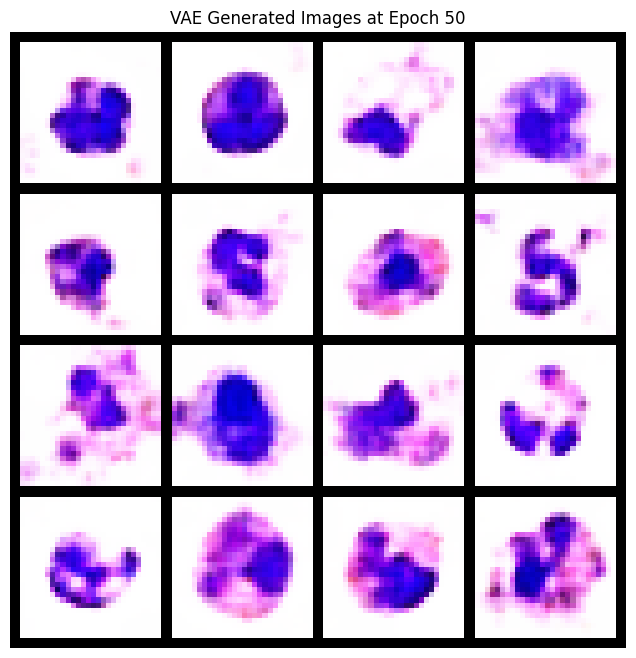

Epoch 50 FID: 175.0448
New best FID: 175.0448
Epoch [51/150] | Loss: 1033.6667 | Reconstruction: 1025.9296 | KLD: 77.3718
Epoch [52/150] | Loss: 1032.7783 | Reconstruction: 1025.0148 | KLD: 77.6355
Epoch [53/150] | Loss: 1032.6312 | Reconstruction: 1024.8678 | KLD: 77.6347
Epoch [54/150] | Loss: 1032.0829 | Reconstruction: 1024.3302 | KLD: 77.5266
Epoch [55/150] | Loss: 1032.0529 | Reconstruction: 1024.2945 | KLD: 77.5837


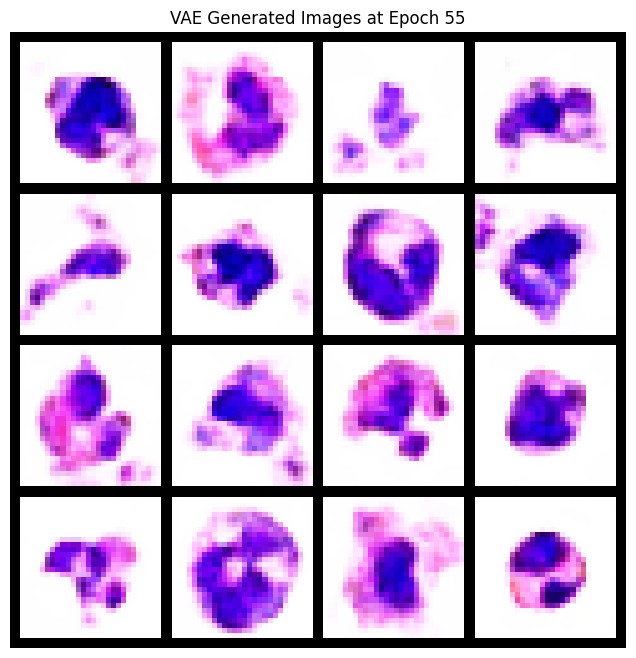

Epoch 55 FID: 175.0162
New best FID: 175.0162
Epoch [56/150] | Loss: 1030.9689 | Reconstruction: 1023.2271 | KLD: 77.4182
Epoch [57/150] | Loss: 1030.7829 | Reconstruction: 1023.0427 | KLD: 77.4017
Epoch [58/150] | Loss: 1030.8566 | Reconstruction: 1023.1105 | KLD: 77.4608
Epoch [59/150] | Loss: 1030.3510 | Reconstruction: 1022.5907 | KLD: 77.6031
Epoch [60/150] | Loss: 1029.6536 | Reconstruction: 1021.9128 | KLD: 77.4078


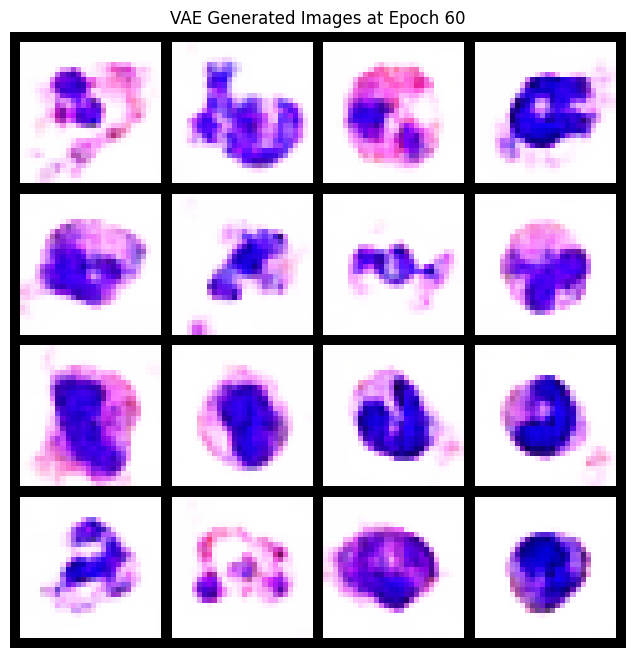

Epoch 60 FID: 169.8776
New best FID: 169.8776
Epoch [61/150] | Loss: 1030.2023 | Reconstruction: 1022.4363 | KLD: 77.6595
Epoch [62/150] | Loss: 1029.6872 | Reconstruction: 1021.9448 | KLD: 77.4241
Epoch [63/150] | Loss: 1028.9869 | Reconstruction: 1021.2518 | KLD: 77.3511
Epoch [64/150] | Loss: 1028.7090 | Reconstruction: 1020.9721 | KLD: 77.3686
Epoch [65/150] | Loss: 1029.0432 | Reconstruction: 1021.3072 | KLD: 77.3594


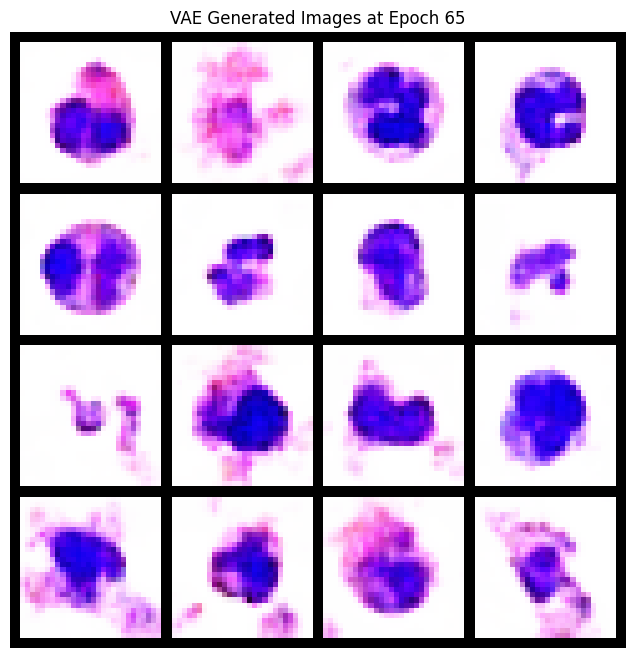

Epoch 65 FID: 173.2115
No improvement for 1 evaluations
Epoch [66/150] | Loss: 1028.2868 | Reconstruction: 1020.5370 | KLD: 77.4985
Epoch [67/150] | Loss: 1028.2986 | Reconstruction: 1020.5558 | KLD: 77.4274
Epoch [68/150] | Loss: 1028.1030 | Reconstruction: 1020.3682 | KLD: 77.3485
Epoch [69/150] | Loss: 1028.2753 | Reconstruction: 1020.5397 | KLD: 77.3558
Epoch [70/150] | Loss: 1028.1042 | Reconstruction: 1020.3738 | KLD: 77.3037


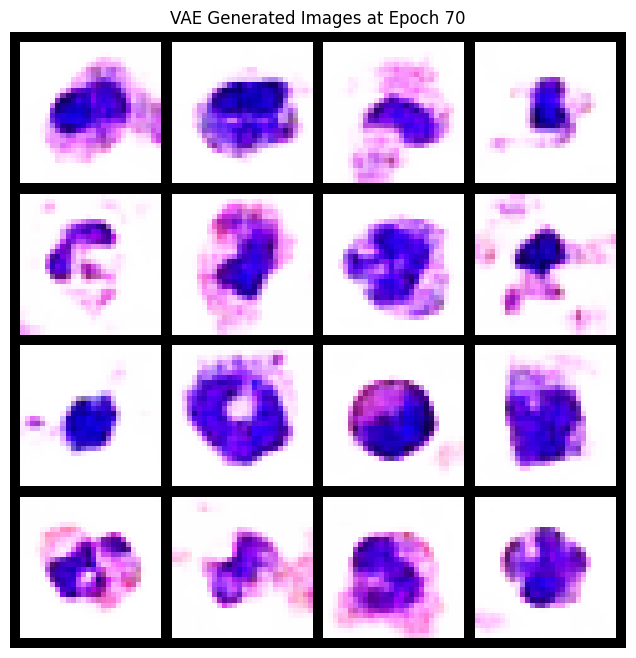

Epoch 70 FID: 175.9878
No improvement for 2 evaluations
Epoch [71/150] | Loss: 1027.2295 | Reconstruction: 1019.4998 | KLD: 77.2971
Epoch [72/150] | Loss: 1027.1192 | Reconstruction: 1019.3927 | KLD: 77.2658
Epoch [73/150] | Loss: 1027.0290 | Reconstruction: 1019.3058 | KLD: 77.2320
Epoch [74/150] | Loss: 1026.5010 | Reconstruction: 1018.7819 | KLD: 77.1911
Epoch [75/150] | Loss: 1026.4963 | Reconstruction: 1018.7698 | KLD: 77.2658


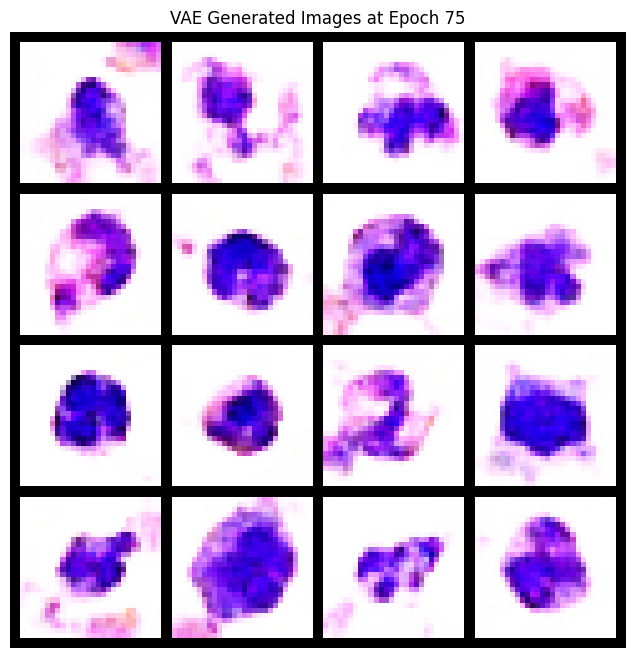

Epoch 75 FID: 173.2678
No improvement for 3 evaluations
Epoch [76/150] | Loss: 1026.2089 | Reconstruction: 1018.4935 | KLD: 77.1542
Epoch [77/150] | Loss: 1026.3426 | Reconstruction: 1018.6361 | KLD: 77.0647
Epoch [78/150] | Loss: 1025.8081 | Reconstruction: 1018.0888 | KLD: 77.1929
Epoch [79/150] | Loss: 1025.7566 | Reconstruction: 1018.0535 | KLD: 77.0306
Epoch [80/150] | Loss: 1025.4357 | Reconstruction: 1017.7336 | KLD: 77.0206


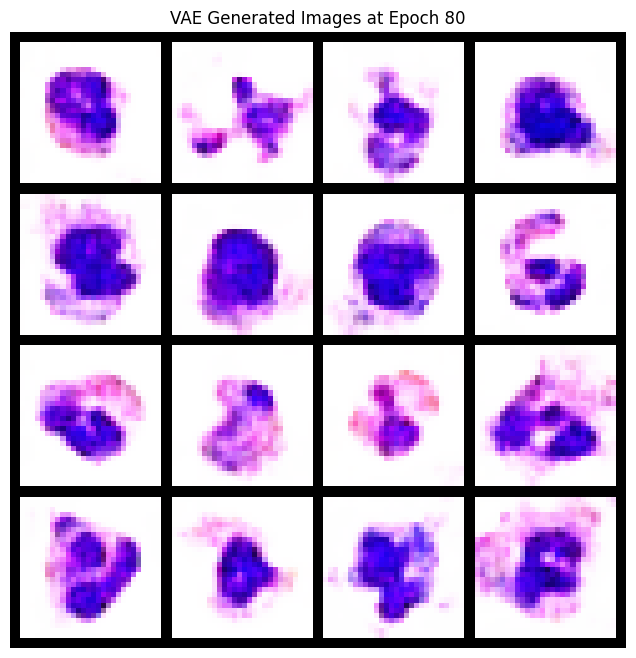

Epoch 80 FID: 173.3567
No improvement for 4 evaluations
Epoch [81/150] | Loss: 1025.6622 | Reconstruction: 1017.9533 | KLD: 77.0897
Epoch [82/150] | Loss: 1025.7778 | Reconstruction: 1018.0690 | KLD: 77.0875
Epoch [83/150] | Loss: 1025.7177 | Reconstruction: 1018.0173 | KLD: 77.0042
Epoch [84/150] | Loss: 1025.2315 | Reconstruction: 1017.5475 | KLD: 76.8402
Epoch [85/150] | Loss: 1024.7890 | Reconstruction: 1017.1092 | KLD: 76.7986


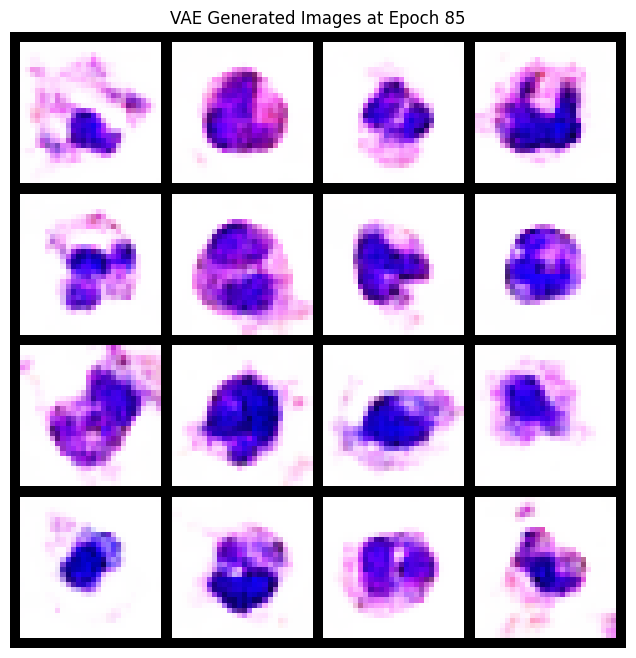

Epoch 85 FID: 170.5886
No improvement for 5 evaluations
Early stopping at epoch 85
VAE FID Score: 160.0381

=== Best VAE Hyperparameter Configuration ===
FID Score: 150.8550
Configuration: {'beta': 0.1, 'beta_schedule': None, 'epochs': 150, 'hidden_dims': [512, 256], 'latent_dim': 128, 'learning_rate': 0.0003}


In [ ]:
# -----------------------------------------
# Sample real images for VAE evaluation
# -----------------------------------------
print("Sampling real data points for VAE evaluation...")
vae_real_samples = sample_real_data(full_dataset, n_samples=10000, seed=INITIAL_SEED)

# Clone the data to stay on CPU for training (DataLoader)
vae_real_samples_cpu = vae_real_samples.clone()

# Create a DataLoader for training using the sampled images
vae_train_loader = DataLoader(
    data.TensorDataset(vae_real_samples_cpu, torch.zeros(len(vae_real_samples_cpu))),  # Dummy labels
    batch_size=128,
    shuffle=True,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

# Move the real samples to device (GPU/CPU) for evaluation
vae_real_samples = vae_real_samples.to(DEVICE)

# -----------------------------------------
# Run hyperparameter tuning for VAE
# -----------------------------------------
vae_results = []  # Store metrics and models for each combination

# For demo or quick test, use only a subset of the full grid
subset_size = min(5, len(vae_hyperparameter_combinations))  # Can adjust to run more
selected_hyperparams = vae_hyperparameter_combinations[:subset_size]

# Iterate over selected hyperparameter configurations
for i, hyperparams in enumerate(selected_hyperparams):
    print(f"\nVAE Hyperparameter combination {i+1}/{subset_size}")
    print(f"Configuration: {hyperparams}")

    # Ensure reproducibility
    set_seed(INITIAL_SEED)

    # Initialize the VAE model with the current configuration
    vae_model = FlexibleVAE(
        hidden_dims=hyperparams['hidden_dims'],
        latent_dim=hyperparams['latent_dim'],
        in_channels=n_channels
    ).to(DEVICE)

    # Train the model and capture the losses
    trained_vae, losses, recon_losses, kld_losses = train_vae(
        vae_model,
        vae_train_loader,
        hyperparams,
        DEVICE
    )

    # Evaluate model using FID score
    fid, fake_samples = evaluate_vae_model(trained_vae, vae_real_samples, DEVICE)

    # Save metrics and model state
    vae_results.append({
        'hyperparams': hyperparams,
        'fid': fid,
        'model_state': trained_vae.state_dict(),
        'losses': losses,
        'recon_losses': recon_losses,
        'kld_losses': kld_losses
    })

    print(f"VAE FID Score: {fid:.4f}")

# -----------------------------------------
# Select best model based on FID score
# -----------------------------------------
vae_results.sort(key=lambda x: x['fid'])  # Lower FID is better

# Display the best-performing configuration
best_vae_result = vae_results[0]
print("\n=== Best VAE Hyperparameter Configuration ===")
print(f"FID Score: {best_vae_result['fid']:.4f}")
print(f"Configuration: {best_vae_result['hyperparams']}")

# Save the best model for future use
torch.save(best_vae_result['model_state'], 'best_bloodmnist_vae.pth')

### Múltiplas execuções com a melhor configuração


=== Running Multiple Seeds for Best VAE Configuration ===

Run 1/5 with seed 42
Starting VAE training with hyperparameters: {'beta': 0.1, 'beta_schedule': None, 'epochs': 150, 'hidden_dims': [512, 256], 'latent_dim': 128, 'learning_rate': 0.0003}
Epoch [1/150] | Loss: 1622.9129 | Reconstruction: 1600.5666 | KLD: 223.4633


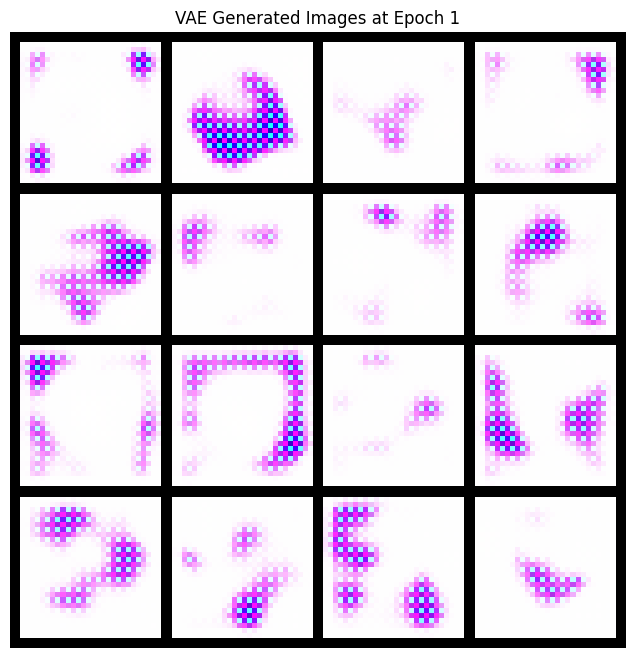

Epoch 1 FID: 369.8864
New best FID: 369.8864
Epoch [2/150] | Loss: 1362.6912 | Reconstruction: 1348.8447 | KLD: 138.4644
Epoch [3/150] | Loss: 1339.8689 | Reconstruction: 1326.3463 | KLD: 135.2259
Epoch [4/150] | Loss: 1328.1982 | Reconstruction: 1314.9727 | KLD: 132.2546
Epoch [5/150] | Loss: 1320.3380 | Reconstruction: 1307.5412 | KLD: 127.9680


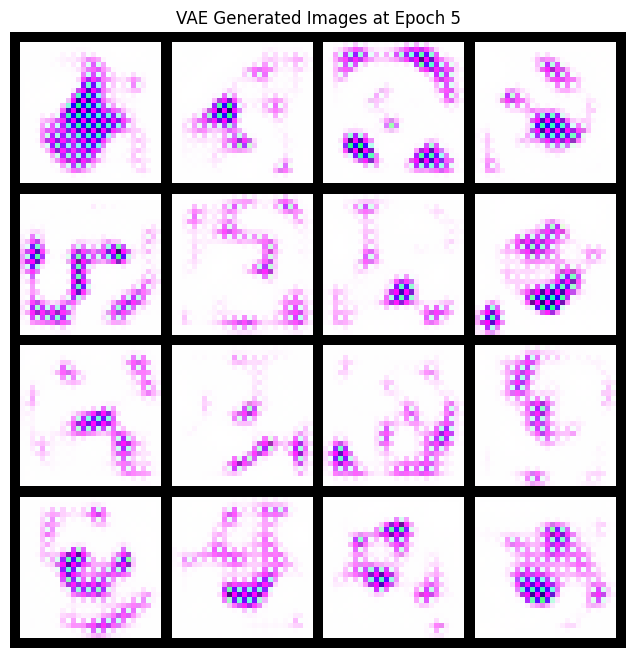

Epoch 5 FID: 306.7846
New best FID: 306.7846
Epoch [6/150] | Loss: 1317.0685 | Reconstruction: 1303.9865 | KLD: 130.8204
Epoch [7/150] | Loss: 1197.7754 | Reconstruction: 1184.4477 | KLD: 133.2764
Epoch [8/150] | Loss: 1154.9718 | Reconstruction: 1141.2313 | KLD: 137.4045
Epoch [9/150] | Loss: 1150.1012 | Reconstruction: 1136.3888 | KLD: 137.1241
Epoch [10/150] | Loss: 1104.3193 | Reconstruction: 1090.2249 | KLD: 140.9436


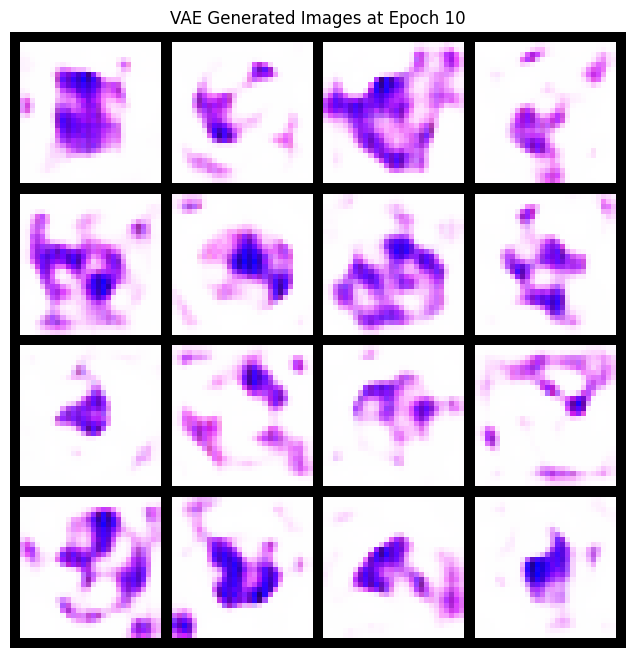

Epoch 10 FID: 192.5673
New best FID: 192.5673
Epoch [11/150] | Loss: 1074.9040 | Reconstruction: 1060.6476 | KLD: 142.5638
Epoch [12/150] | Loss: 1068.3470 | Reconstruction: 1053.6060 | KLD: 147.4102
Epoch [13/150] | Loss: 1064.5667 | Reconstruction: 1050.0644 | KLD: 145.0225
Epoch [14/150] | Loss: 1062.4720 | Reconstruction: 1048.0947 | KLD: 143.7735
Epoch [15/150] | Loss: 1061.6060 | Reconstruction: 1047.0811 | KLD: 145.2484


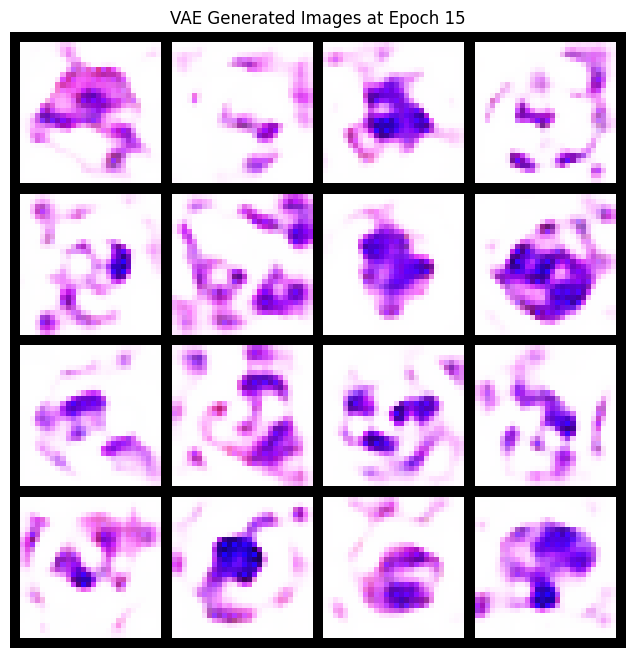

Epoch 15 FID: 175.9876
New best FID: 175.9876
Epoch [16/150] | Loss: 1059.7090 | Reconstruction: 1045.3083 | KLD: 144.0074
Epoch [17/150] | Loss: 1051.4103 | Reconstruction: 1036.8366 | KLD: 145.7373
Epoch [18/150] | Loss: 1047.8824 | Reconstruction: 1033.2747 | KLD: 146.0768
Epoch [19/150] | Loss: 1047.5367 | Reconstruction: 1032.8300 | KLD: 147.0669
Epoch [20/150] | Loss: 1046.5580 | Reconstruction: 1031.8506 | KLD: 147.0741


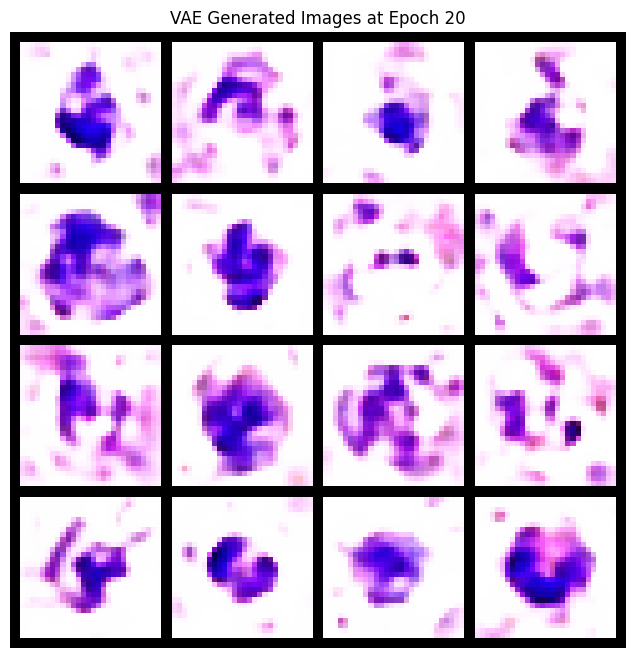

Epoch 20 FID: 170.9733
New best FID: 170.9733
Epoch [21/150] | Loss: 1046.4583 | Reconstruction: 1031.6581 | KLD: 148.0022
Epoch [22/150] | Loss: 1045.0149 | Reconstruction: 1030.2079 | KLD: 148.0698
Epoch [23/150] | Loss: 1044.1853 | Reconstruction: 1029.4922 | KLD: 146.9318
Epoch [24/150] | Loss: 1043.5302 | Reconstruction: 1028.7569 | KLD: 147.7326
Epoch [25/150] | Loss: 1042.5706 | Reconstruction: 1027.9030 | KLD: 146.6758


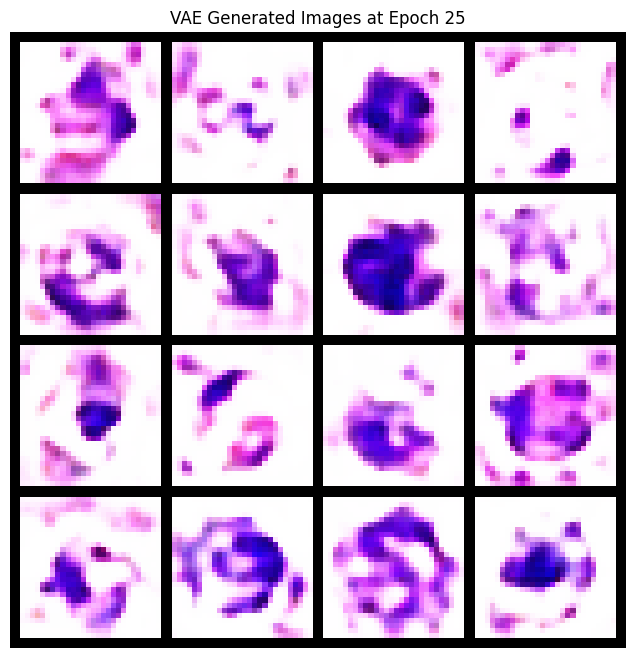

Epoch 25 FID: 168.3927
New best FID: 168.3927
Epoch [26/150] | Loss: 1042.9020 | Reconstruction: 1028.1108 | KLD: 147.9117
Epoch [27/150] | Loss: 1042.3252 | Reconstruction: 1027.5450 | KLD: 147.8019
Epoch [28/150] | Loss: 1040.9520 | Reconstruction: 1026.1756 | KLD: 147.7641
Epoch [29/150] | Loss: 1041.6228 | Reconstruction: 1026.7961 | KLD: 148.2667
Epoch [30/150] | Loss: 1040.4025 | Reconstruction: 1025.6269 | KLD: 147.7551


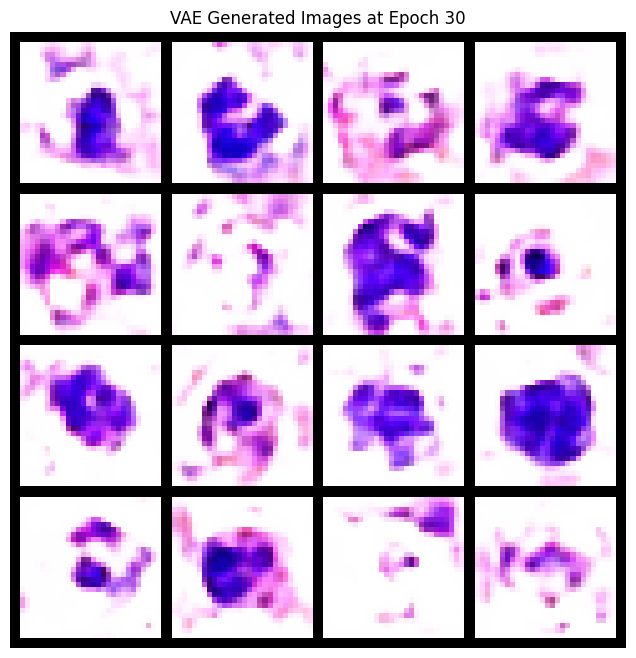

Epoch 30 FID: 164.2968
New best FID: 164.2968
Epoch [31/150] | Loss: 1040.0371 | Reconstruction: 1025.2457 | KLD: 147.9144
Epoch [32/150] | Loss: 1040.0672 | Reconstruction: 1025.2987 | KLD: 147.6846
Epoch [33/150] | Loss: 1039.4244 | Reconstruction: 1024.6293 | KLD: 147.9519
Epoch [34/150] | Loss: 1038.1765 | Reconstruction: 1023.4944 | KLD: 146.8203
Epoch [35/150] | Loss: 1038.2784 | Reconstruction: 1023.6033 | KLD: 146.7513


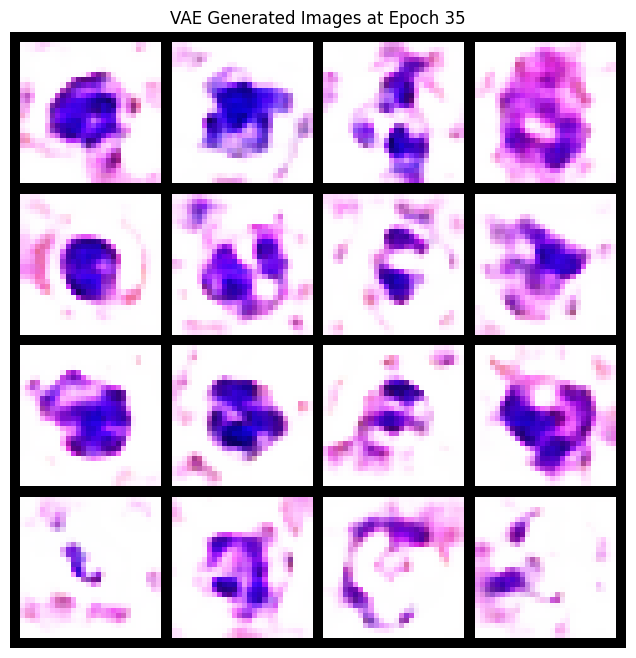

Epoch 35 FID: 162.6754
New best FID: 162.6754
Epoch [36/150] | Loss: 1038.0462 | Reconstruction: 1023.3062 | KLD: 147.4005
Epoch [37/150] | Loss: 1038.1583 | Reconstruction: 1023.4002 | KLD: 147.5816
Epoch [38/150] | Loss: 1037.3889 | Reconstruction: 1022.6308 | KLD: 147.5818
Epoch [39/150] | Loss: 1037.2429 | Reconstruction: 1022.5060 | KLD: 147.3686
Epoch [40/150] | Loss: 1037.0893 | Reconstruction: 1022.3339 | KLD: 147.5539


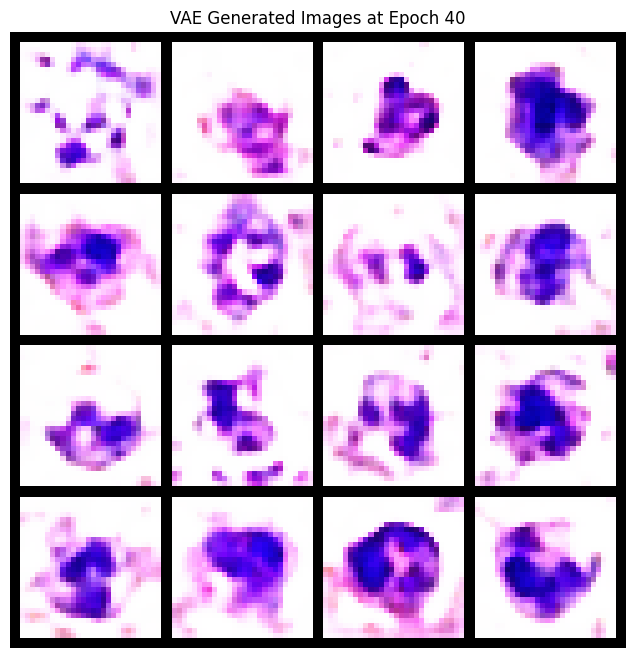

Epoch 40 FID: 163.5902
No improvement for 1 evaluations
Epoch [41/150] | Loss: 1036.2777 | Reconstruction: 1021.5598 | KLD: 147.1788
Epoch [42/150] | Loss: 1036.1364 | Reconstruction: 1021.4089 | KLD: 147.2755
Epoch [43/150] | Loss: 1035.6604 | Reconstruction: 1020.9334 | KLD: 147.2703
Epoch [44/150] | Loss: 1035.9852 | Reconstruction: 1021.2346 | KLD: 147.5058
Epoch [45/150] | Loss: 1035.0907 | Reconstruction: 1020.3675 | KLD: 147.2325


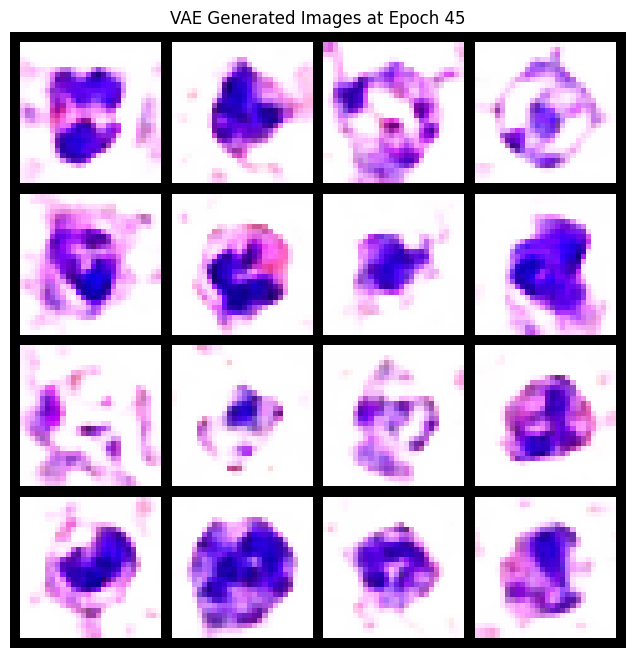

Epoch 45 FID: 164.1017
No improvement for 2 evaluations
Epoch [46/150] | Loss: 1034.6833 | Reconstruction: 1020.0280 | KLD: 146.5536
Epoch [47/150] | Loss: 1034.2409 | Reconstruction: 1019.6065 | KLD: 146.3441
Epoch [48/150] | Loss: 1034.5735 | Reconstruction: 1019.8496 | KLD: 147.2392
Epoch [49/150] | Loss: 1034.0496 | Reconstruction: 1019.3945 | KLD: 146.5509
Epoch [50/150] | Loss: 1033.7069 | Reconstruction: 1019.0503 | KLD: 146.5669


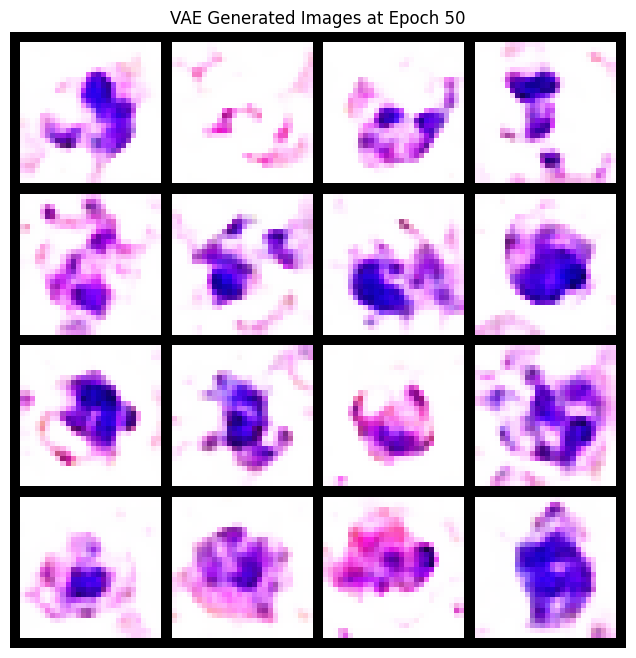

Epoch 50 FID: 162.8158
No improvement for 3 evaluations
Epoch [51/150] | Loss: 1033.4934 | Reconstruction: 1018.8415 | KLD: 146.5194
Epoch [52/150] | Loss: 1033.0939 | Reconstruction: 1018.5009 | KLD: 145.9305
Epoch [53/150] | Loss: 1034.0619 | Reconstruction: 1019.3751 | KLD: 146.8681
Epoch [54/150] | Loss: 1033.0796 | Reconstruction: 1018.3628 | KLD: 147.1675
Epoch [55/150] | Loss: 1033.1004 | Reconstruction: 1018.4447 | KLD: 146.5576


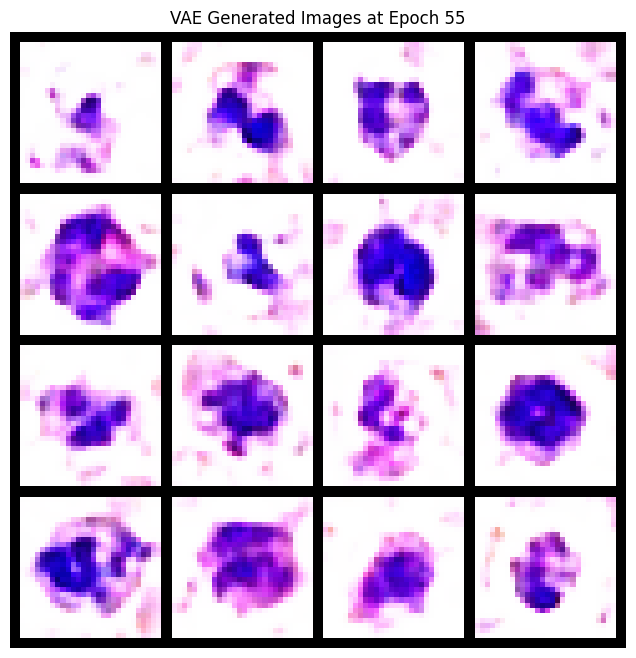

Epoch 55 FID: 163.9782
No improvement for 4 evaluations
Epoch [56/150] | Loss: 1032.1779 | Reconstruction: 1017.5598 | KLD: 146.1813
Epoch [57/150] | Loss: 1032.1778 | Reconstruction: 1017.5734 | KLD: 146.0441
Epoch [58/150] | Loss: 1032.8718 | Reconstruction: 1018.2420 | KLD: 146.2979
Epoch [59/150] | Loss: 1032.3014 | Reconstruction: 1017.6567 | KLD: 146.4465
Epoch [60/150] | Loss: 1031.6358 | Reconstruction: 1017.0635 | KLD: 145.7230


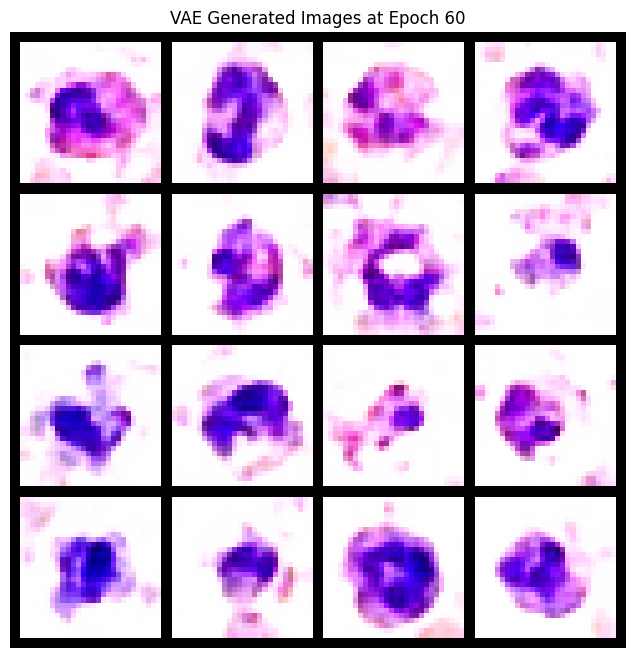

Epoch 60 FID: 163.0486
No improvement for 5 evaluations
Early stopping at epoch 60
FID Score for run 1: 151.0764


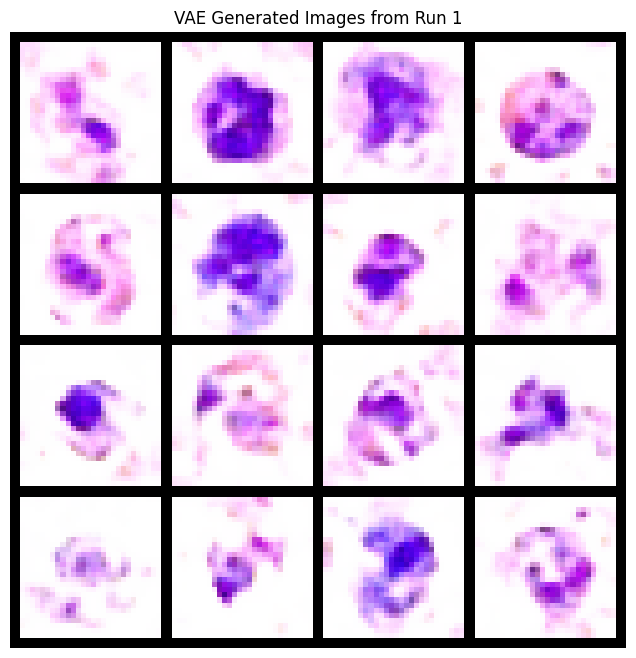


Run 2/5 with seed 123
Starting VAE training with hyperparameters: {'beta': 0.1, 'beta_schedule': None, 'epochs': 150, 'hidden_dims': [512, 256], 'latent_dim': 128, 'learning_rate': 0.0003}
Epoch [1/150] | Loss: 1611.9260 | Reconstruction: 1589.3660 | KLD: 225.5999


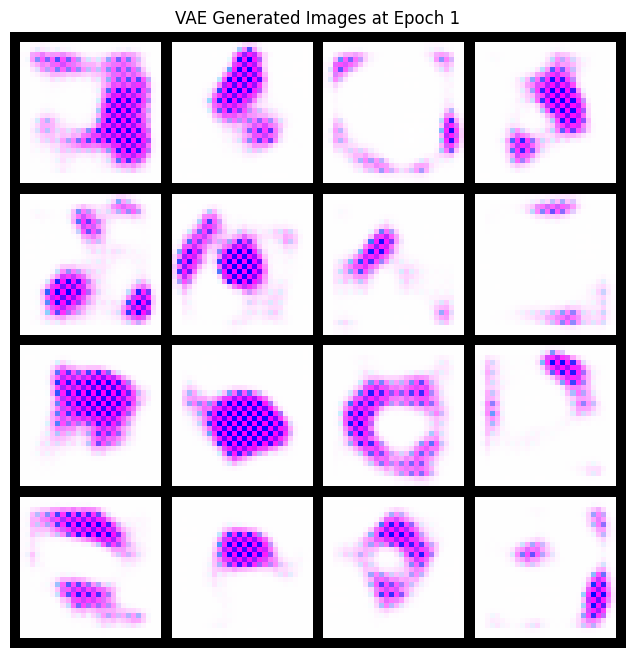

Epoch 1 FID: 385.2470
New best FID: 385.2470
Epoch [2/150] | Loss: 1284.2286 | Reconstruction: 1269.7813 | KLD: 144.4721
Epoch [3/150] | Loss: 1263.5940 | Reconstruction: 1250.1410 | KLD: 134.5309
Epoch [4/150] | Loss: 1253.5414 | Reconstruction: 1240.3677 | KLD: 131.7373
Epoch [5/150] | Loss: 1231.3389 | Reconstruction: 1217.8323 | KLD: 135.0663


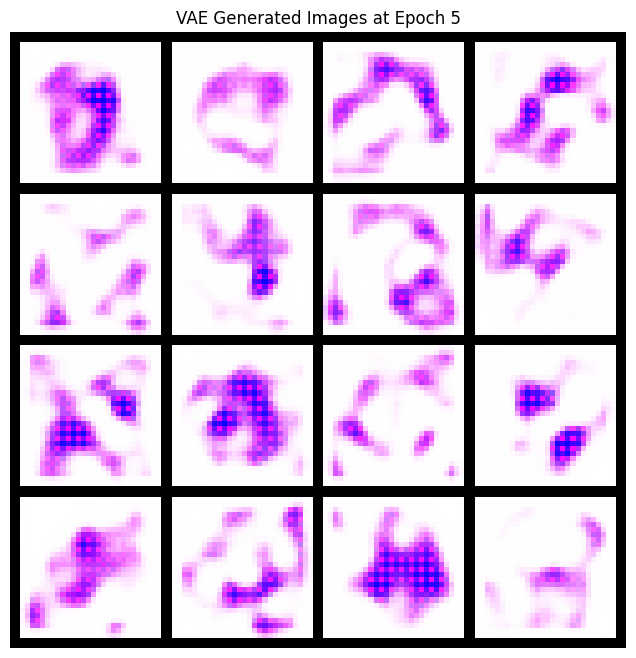

Epoch 5 FID: 243.9880
New best FID: 243.9880
Epoch [6/150] | Loss: 1177.2803 | Reconstruction: 1163.4969 | KLD: 137.8344
Epoch [7/150] | Loss: 1109.3901 | Reconstruction: 1095.3221 | KLD: 140.6798
Epoch [8/150] | Loss: 1101.1148 | Reconstruction: 1087.1591 | KLD: 139.5565
Epoch [9/150] | Loss: 1097.3395 | Reconstruction: 1083.6595 | KLD: 136.8005
Epoch [10/150] | Loss: 1089.5175 | Reconstruction: 1075.8738 | KLD: 136.4365


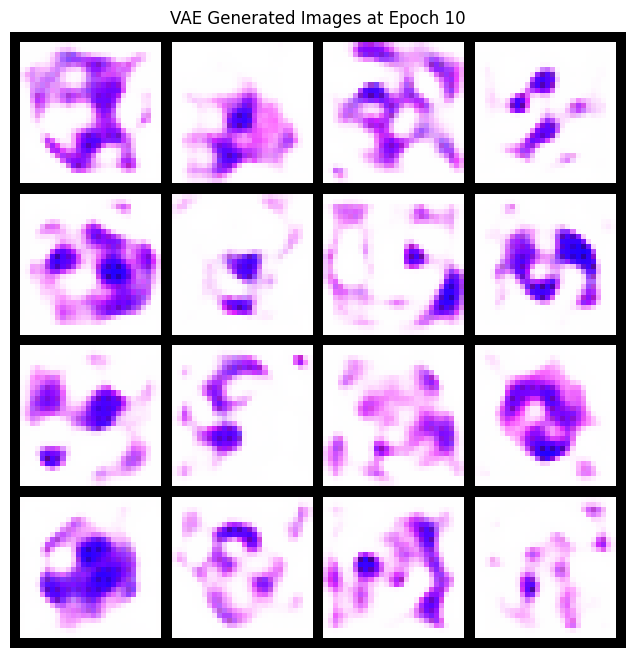

Epoch 10 FID: 194.9597
New best FID: 194.9597
Epoch [11/150] | Loss: 1085.2531 | Reconstruction: 1071.3929 | KLD: 138.6012
Epoch [12/150] | Loss: 1075.4375 | Reconstruction: 1061.5386 | KLD: 138.9894
Epoch [13/150] | Loss: 1072.6478 | Reconstruction: 1058.6194 | KLD: 140.2843
Epoch [14/150] | Loss: 1071.3401 | Reconstruction: 1057.1576 | KLD: 141.8249
Epoch [15/150] | Loss: 1064.8947 | Reconstruction: 1050.6842 | KLD: 142.1049


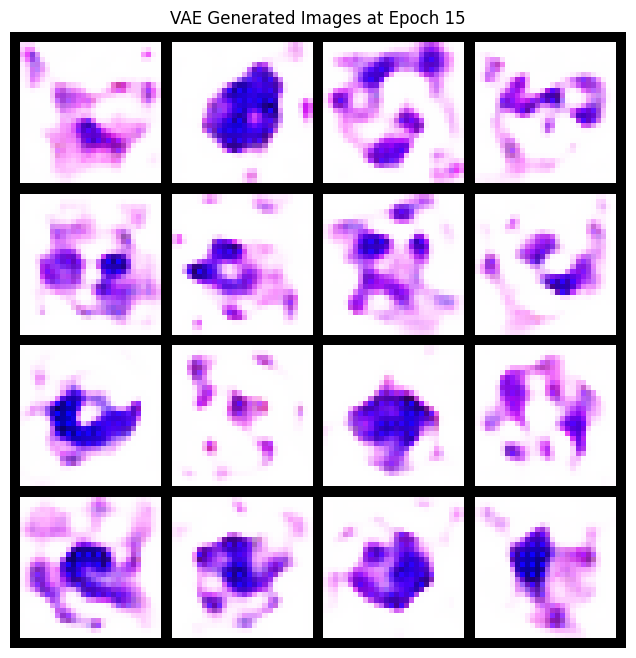

Epoch 15 FID: 177.9571
New best FID: 177.9571
Epoch [16/150] | Loss: 1057.9920 | Reconstruction: 1043.7953 | KLD: 141.9677
Epoch [17/150] | Loss: 1056.3765 | Reconstruction: 1042.2585 | KLD: 141.1802
Epoch [18/150] | Loss: 1052.0070 | Reconstruction: 1037.7642 | KLD: 142.4277
Epoch [19/150] | Loss: 1045.3221 | Reconstruction: 1030.8990 | KLD: 144.2314
Epoch [20/150] | Loss: 1044.4695 | Reconstruction: 1029.9118 | KLD: 145.5769


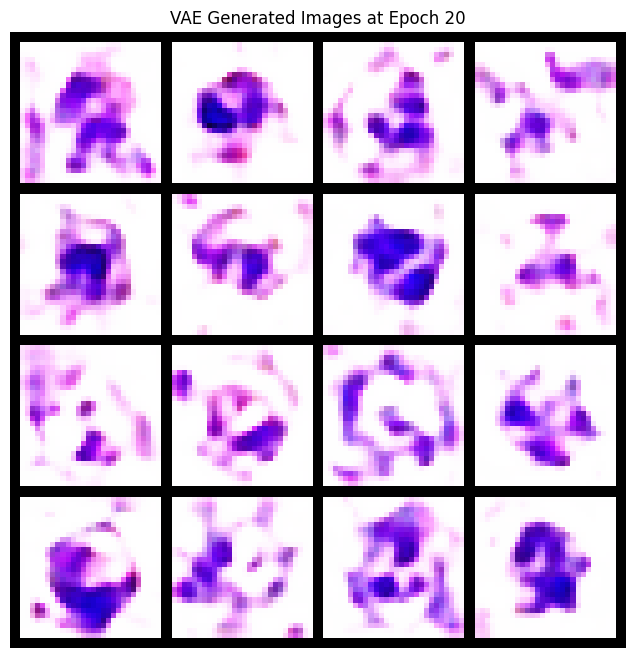

Epoch 20 FID: 166.7510
New best FID: 166.7510
Epoch [21/150] | Loss: 1043.0234 | Reconstruction: 1028.5324 | KLD: 144.9098
Epoch [22/150] | Loss: 1042.6708 | Reconstruction: 1028.0892 | KLD: 145.8164
Epoch [23/150] | Loss: 1041.6433 | Reconstruction: 1027.1036 | KLD: 145.3971
Epoch [24/150] | Loss: 1041.2128 | Reconstruction: 1026.5884 | KLD: 146.2440
Epoch [25/150] | Loss: 1040.4612 | Reconstruction: 1025.8270 | KLD: 146.3420


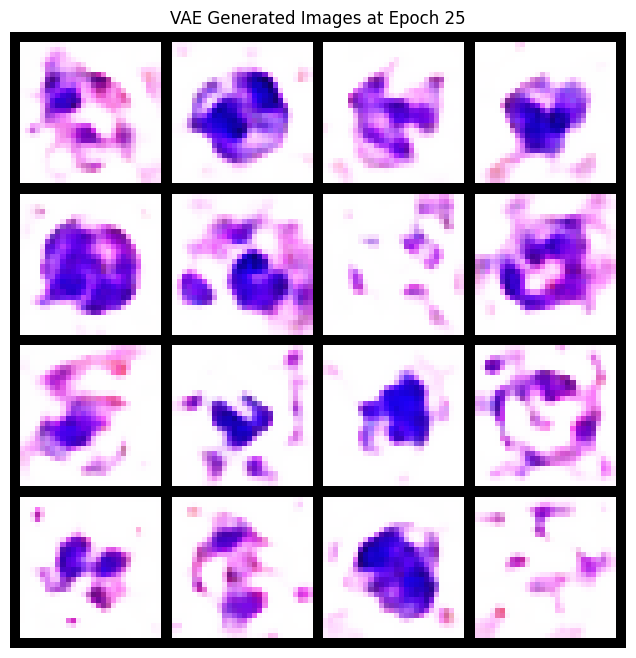

Epoch 25 FID: 163.4276
New best FID: 163.4276
Epoch [26/150] | Loss: 1039.1606 | Reconstruction: 1024.6476 | KLD: 145.1298
Epoch [27/150] | Loss: 1038.6601 | Reconstruction: 1024.1301 | KLD: 145.2998
Epoch [28/150] | Loss: 1038.6086 | Reconstruction: 1024.0329 | KLD: 145.7565
Epoch [29/150] | Loss: 1037.7628 | Reconstruction: 1023.1545 | KLD: 146.0823
Epoch [30/150] | Loss: 1037.4857 | Reconstruction: 1022.8659 | KLD: 146.1979


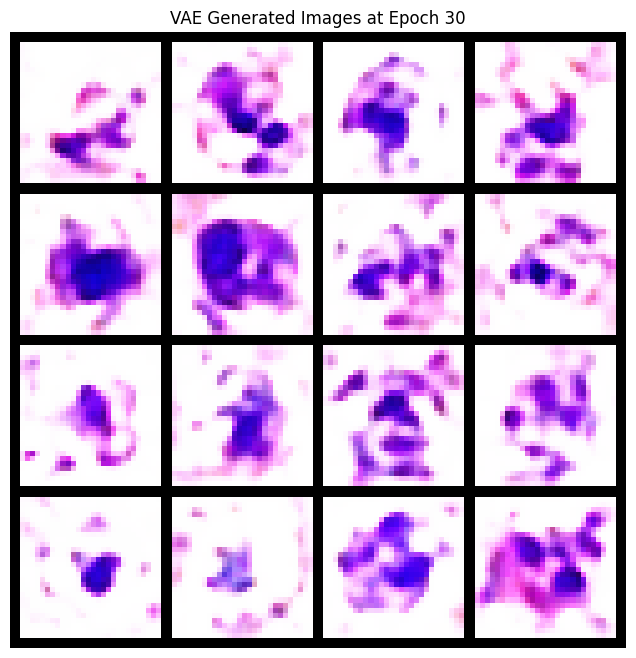

Epoch 30 FID: 161.7777
New best FID: 161.7777
Epoch [31/150] | Loss: 1037.0787 | Reconstruction: 1022.4456 | KLD: 146.3301
Epoch [32/150] | Loss: 1038.2503 | Reconstruction: 1023.4471 | KLD: 148.0325
Epoch [33/150] | Loss: 1036.3547 | Reconstruction: 1021.5874 | KLD: 147.6734
Epoch [34/150] | Loss: 1035.8940 | Reconstruction: 1021.2456 | KLD: 146.4836
Epoch [35/150] | Loss: 1035.6938 | Reconstruction: 1021.0640 | KLD: 146.2979


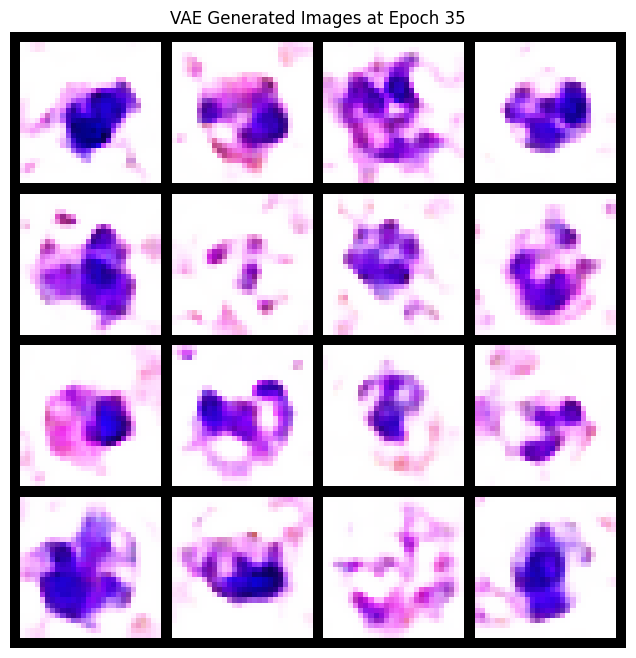

Epoch 35 FID: 157.7019
New best FID: 157.7019
Epoch [36/150] | Loss: 1035.6568 | Reconstruction: 1020.9439 | KLD: 147.1283
Epoch [37/150] | Loss: 1034.7352 | Reconstruction: 1020.0572 | KLD: 146.7800
Epoch [38/150] | Loss: 1034.9248 | Reconstruction: 1020.1871 | KLD: 147.3766
Epoch [39/150] | Loss: 1034.1803 | Reconstruction: 1019.4762 | KLD: 147.0414
Epoch [40/150] | Loss: 1033.9087 | Reconstruction: 1019.2019 | KLD: 147.0672


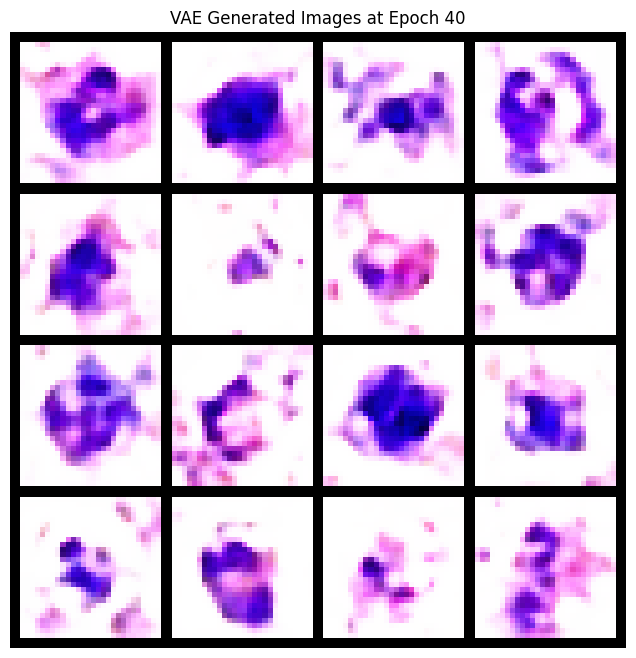

Epoch 40 FID: 155.7345
New best FID: 155.7345
Epoch [41/150] | Loss: 1034.1914 | Reconstruction: 1019.4111 | KLD: 147.8027
Epoch [42/150] | Loss: 1033.4393 | Reconstruction: 1018.7039 | KLD: 147.3546
Epoch [43/150] | Loss: 1032.6924 | Reconstruction: 1018.0147 | KLD: 146.7767
Epoch [44/150] | Loss: 1032.5428 | Reconstruction: 1017.9016 | KLD: 146.4128
Epoch [45/150] | Loss: 1032.1735 | Reconstruction: 1017.5087 | KLD: 146.6480


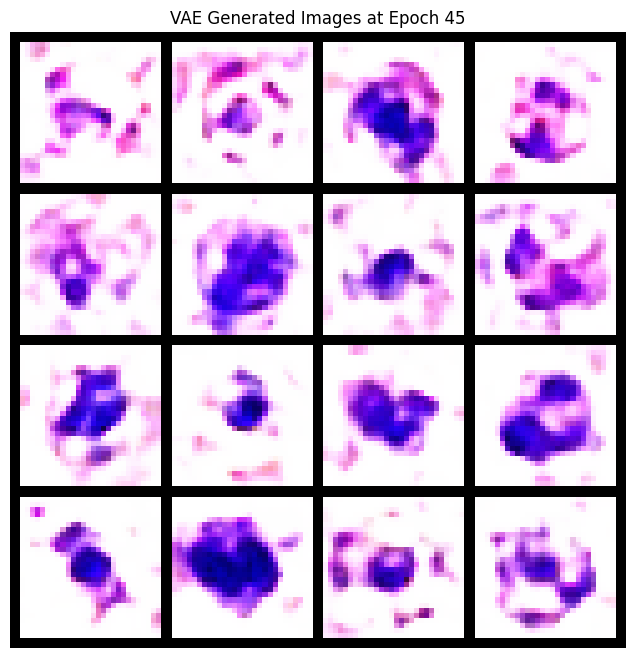

Epoch 45 FID: 159.6401
No improvement for 1 evaluations
Epoch [46/150] | Loss: 1031.7726 | Reconstruction: 1017.1431 | KLD: 146.2949
Epoch [47/150] | Loss: 1031.5398 | Reconstruction: 1016.9376 | KLD: 146.0214
Epoch [48/150] | Loss: 1031.9679 | Reconstruction: 1017.2844 | KLD: 146.8357
Epoch [49/150] | Loss: 1031.3570 | Reconstruction: 1016.7064 | KLD: 146.5062
Epoch [50/150] | Loss: 1030.7130 | Reconstruction: 1016.0724 | KLD: 146.4064


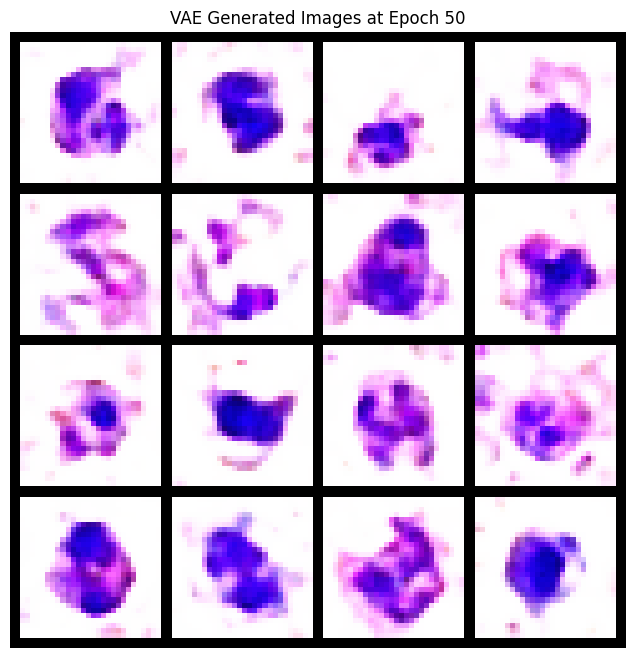

Epoch 50 FID: 156.8253
No improvement for 2 evaluations
Epoch [51/150] | Loss: 1031.4987 | Reconstruction: 1016.8454 | KLD: 146.5331
Epoch [52/150] | Loss: 1030.3767 | Reconstruction: 1015.7046 | KLD: 146.7210
Epoch [53/150] | Loss: 1029.8425 | Reconstruction: 1015.2319 | KLD: 146.1059
Epoch [54/150] | Loss: 1029.7284 | Reconstruction: 1015.1378 | KLD: 145.9060
Epoch [55/150] | Loss: 1030.0215 | Reconstruction: 1015.3741 | KLD: 146.4748


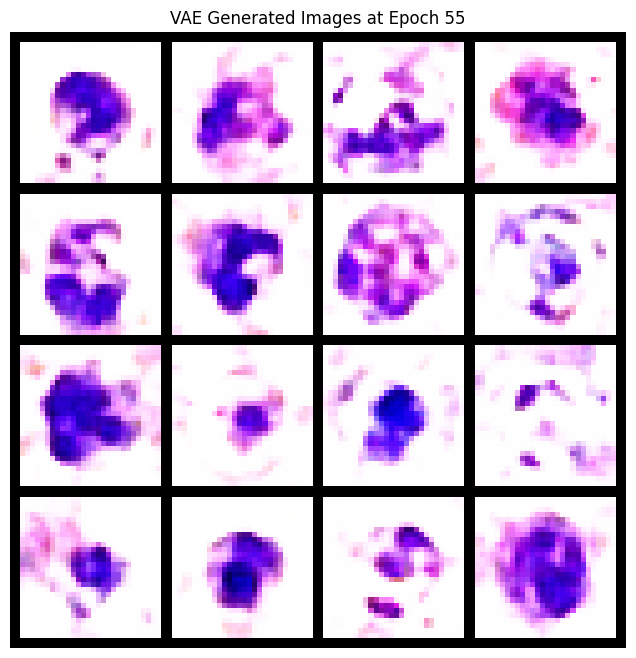

Epoch 55 FID: 160.6091
No improvement for 3 evaluations
Epoch [56/150] | Loss: 1029.4603 | Reconstruction: 1014.8606 | KLD: 145.9974
Epoch [57/150] | Loss: 1029.1346 | Reconstruction: 1014.5269 | KLD: 146.0768
Epoch [58/150] | Loss: 1029.2959 | Reconstruction: 1014.6593 | KLD: 146.3651
Epoch [59/150] | Loss: 1029.0619 | Reconstruction: 1014.4456 | KLD: 146.1633
Epoch [60/150] | Loss: 1028.5340 | Reconstruction: 1013.9353 | KLD: 145.9870


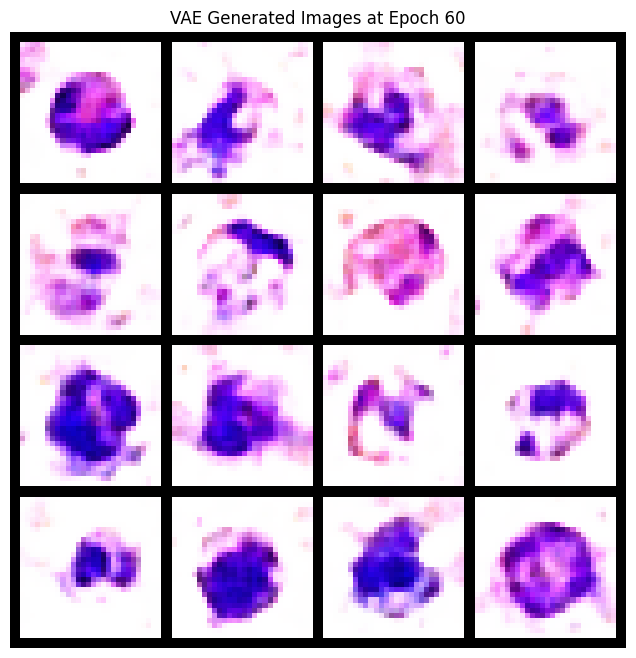

Epoch 60 FID: 156.9444
No improvement for 4 evaluations
Epoch [61/150] | Loss: 1028.0983 | Reconstruction: 1013.5324 | KLD: 145.6592
Epoch [62/150] | Loss: 1028.2521 | Reconstruction: 1013.6992 | KLD: 145.5297
Epoch [63/150] | Loss: 1028.3004 | Reconstruction: 1013.7012 | KLD: 145.9921
Epoch [64/150] | Loss: 1027.6833 | Reconstruction: 1013.1212 | KLD: 145.6208
Epoch [65/150] | Loss: 1028.0094 | Reconstruction: 1013.4406 | KLD: 145.6878


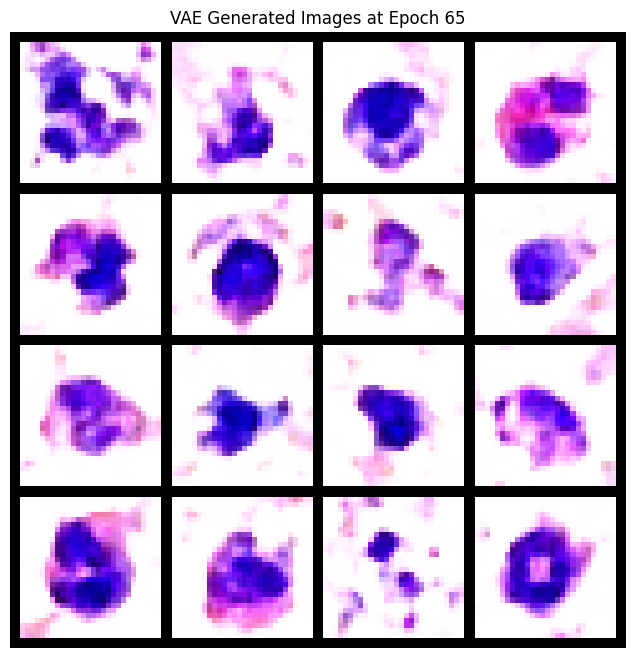

Epoch 65 FID: 157.1841
No improvement for 5 evaluations
Early stopping at epoch 65
FID Score for run 2: 146.9143


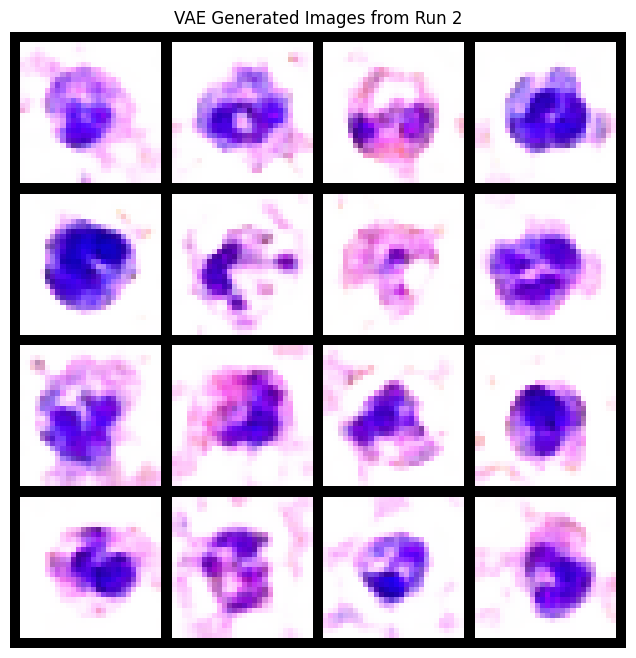


Run 3/5 with seed 456
Starting VAE training with hyperparameters: {'beta': 0.1, 'beta_schedule': None, 'epochs': 150, 'hidden_dims': [512, 256], 'latent_dim': 128, 'learning_rate': 0.0003}
Epoch [1/150] | Loss: 1437.7926 | Reconstruction: 1415.7874 | KLD: 220.0520


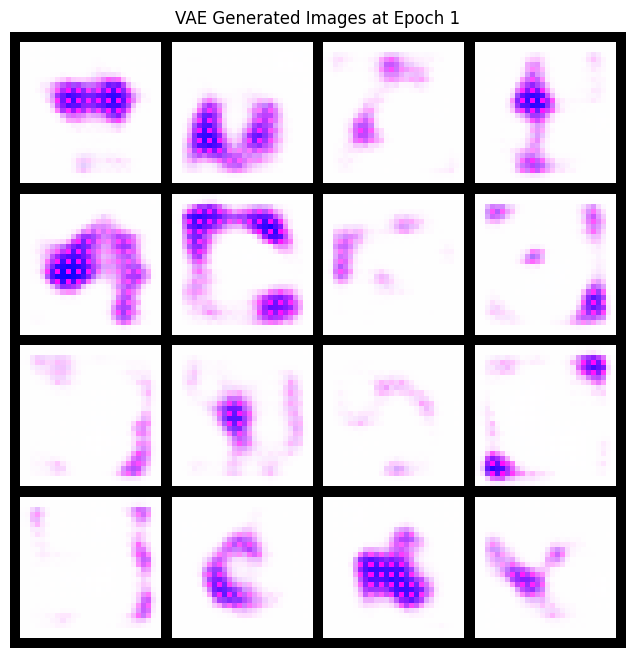

Epoch 1 FID: 355.0323
New best FID: 355.0323
Epoch [2/150] | Loss: 1209.4559 | Reconstruction: 1195.1410 | KLD: 143.1489
Epoch [3/150] | Loss: 1188.0360 | Reconstruction: 1173.8610 | KLD: 141.7509
Epoch [4/150] | Loss: 1177.7311 | Reconstruction: 1163.3070 | KLD: 144.2406
Epoch [5/150] | Loss: 1160.2025 | Reconstruction: 1145.8004 | KLD: 144.0212


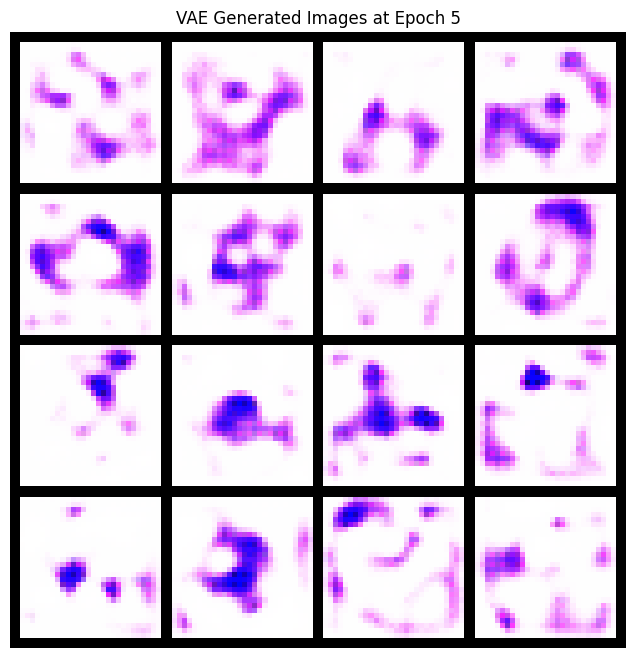

Epoch 5 FID: 225.7051
New best FID: 225.7051
Epoch [6/150] | Loss: 1094.5908 | Reconstruction: 1078.6794 | KLD: 159.1134
Epoch [7/150] | Loss: 1078.1029 | Reconstruction: 1063.1286 | KLD: 149.7433
Epoch [8/150] | Loss: 1073.8883 | Reconstruction: 1058.7389 | KLD: 151.4939
Epoch [9/150] | Loss: 1069.9232 | Reconstruction: 1054.7861 | KLD: 151.3706
Epoch [10/150] | Loss: 1059.1773 | Reconstruction: 1043.9767 | KLD: 152.0064


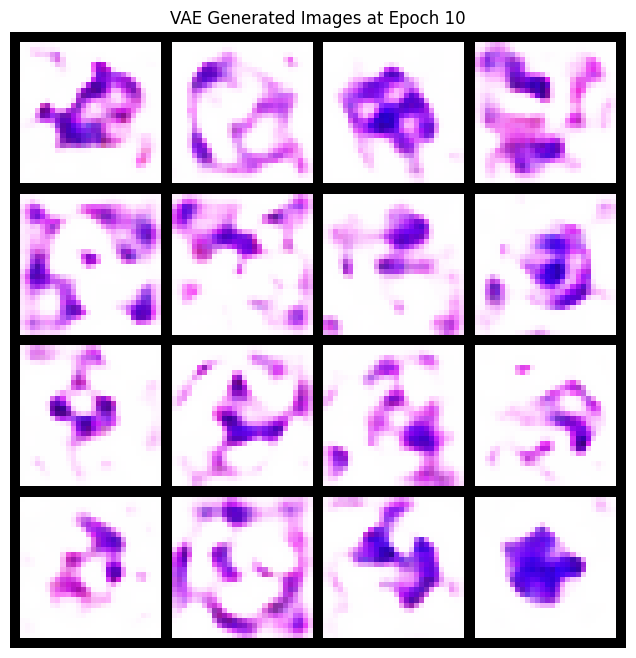

Epoch 10 FID: 179.6768
New best FID: 179.6768
Epoch [11/150] | Loss: 1056.3034 | Reconstruction: 1040.9306 | KLD: 153.7275
Epoch [12/150] | Loss: 1054.0238 | Reconstruction: 1038.7065 | KLD: 153.1736
Epoch [13/150] | Loss: 1051.9969 | Reconstruction: 1036.8010 | KLD: 151.9589
Epoch [14/150] | Loss: 1051.1471 | Reconstruction: 1035.9388 | KLD: 152.0836
Epoch [15/150] | Loss: 1049.8709 | Reconstruction: 1034.6652 | KLD: 152.0561


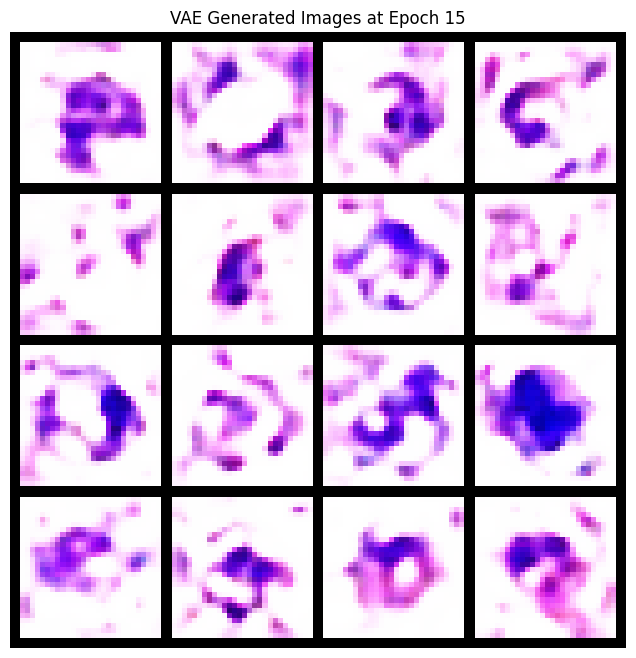

Epoch 15 FID: 169.4345
New best FID: 169.4345
Epoch [16/150] | Loss: 1048.8390 | Reconstruction: 1033.6496 | KLD: 151.8931
Epoch [17/150] | Loss: 1047.9718 | Reconstruction: 1032.7397 | KLD: 152.3213
Epoch [18/150] | Loss: 1047.6327 | Reconstruction: 1032.3077 | KLD: 153.2501
Epoch [19/150] | Loss: 1046.3648 | Reconstruction: 1031.1456 | KLD: 152.1921
Epoch [20/150] | Loss: 1044.9531 | Reconstruction: 1029.8487 | KLD: 151.0445


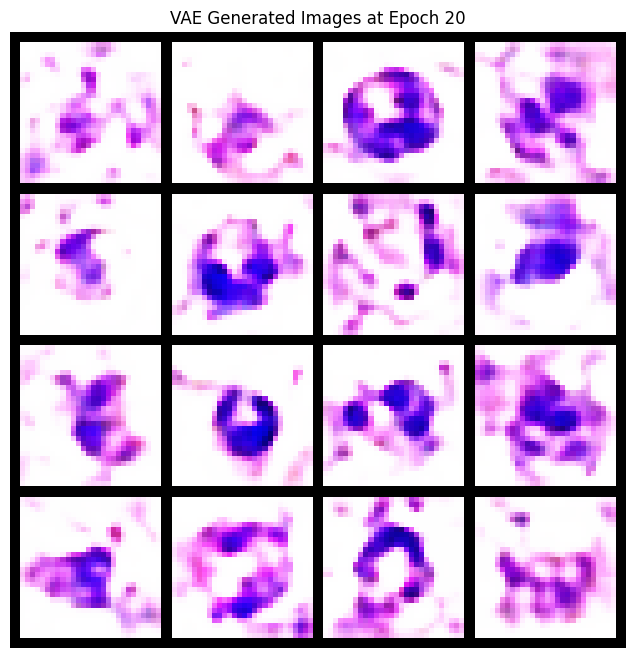

Epoch 20 FID: 164.8001
New best FID: 164.8001
Epoch [21/150] | Loss: 1044.8862 | Reconstruction: 1029.7617 | KLD: 151.2448
Epoch [22/150] | Loss: 1044.0670 | Reconstruction: 1028.9073 | KLD: 151.5973
Epoch [23/150] | Loss: 1043.4698 | Reconstruction: 1028.3867 | KLD: 150.8310
Epoch [24/150] | Loss: 1043.2159 | Reconstruction: 1028.0945 | KLD: 151.2144
Epoch [25/150] | Loss: 1042.6954 | Reconstruction: 1027.5547 | KLD: 151.4073


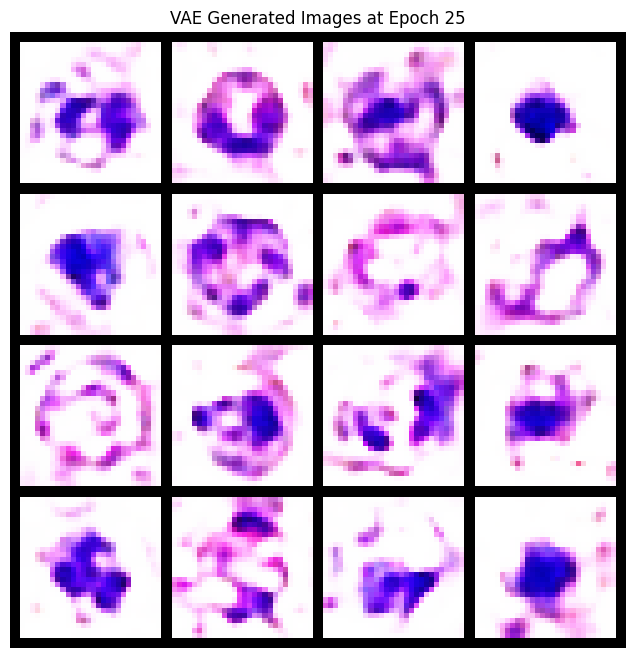

Epoch 25 FID: 159.8301
New best FID: 159.8301
Epoch [26/150] | Loss: 1041.8166 | Reconstruction: 1026.7396 | KLD: 150.7705
Epoch [27/150] | Loss: 1041.0921 | Reconstruction: 1026.0109 | KLD: 150.8120
Epoch [28/150] | Loss: 1040.9968 | Reconstruction: 1025.9635 | KLD: 150.3339
Epoch [29/150] | Loss: 1039.8555 | Reconstruction: 1024.8551 | KLD: 150.0042
Epoch [30/150] | Loss: 1039.4237 | Reconstruction: 1024.4394 | KLD: 149.8426


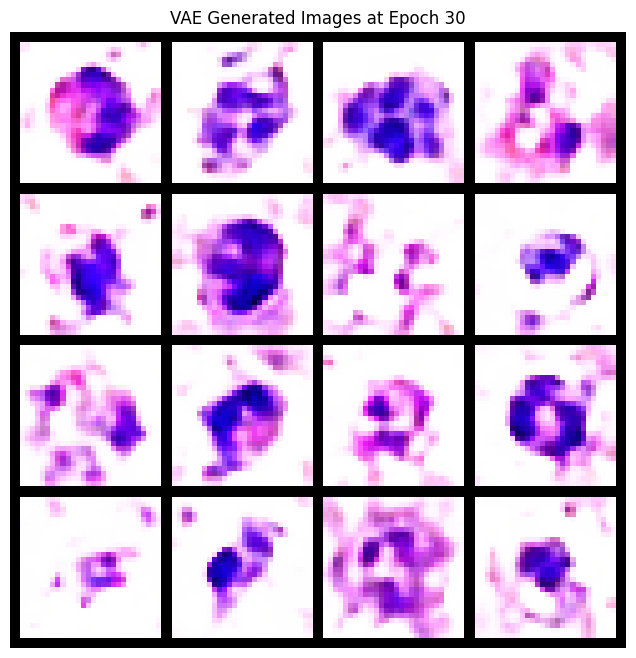

Epoch 30 FID: 163.4026
No improvement for 1 evaluations
Epoch [31/150] | Loss: 1039.6458 | Reconstruction: 1024.6441 | KLD: 150.0169
Epoch [32/150] | Loss: 1038.8758 | Reconstruction: 1023.8812 | KLD: 149.9459
Epoch [33/150] | Loss: 1038.0195 | Reconstruction: 1023.0704 | KLD: 149.4908
Epoch [34/150] | Loss: 1038.7043 | Reconstruction: 1023.7115 | KLD: 149.9277
Epoch [35/150] | Loss: 1038.8981 | Reconstruction: 1023.8348 | KLD: 150.6332


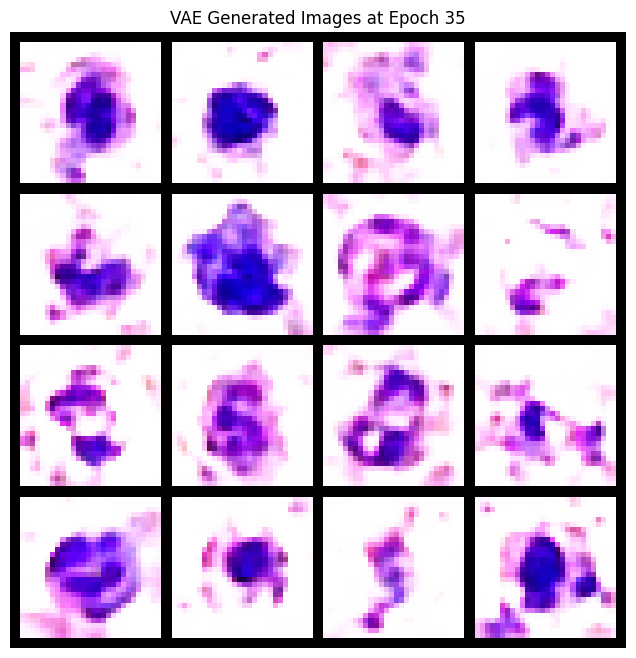

Epoch 35 FID: 163.2364
No improvement for 2 evaluations
Epoch [36/150] | Loss: 1038.1266 | Reconstruction: 1023.0969 | KLD: 150.2969
Epoch [37/150] | Loss: 1037.9624 | Reconstruction: 1022.8950 | KLD: 150.6741
Epoch [38/150] | Loss: 1036.4808 | Reconstruction: 1021.5494 | KLD: 149.3133
Epoch [39/150] | Loss: 1036.6433 | Reconstruction: 1021.6931 | KLD: 149.5021
Epoch [40/150] | Loss: 1036.6745 | Reconstruction: 1021.6879 | KLD: 149.8658


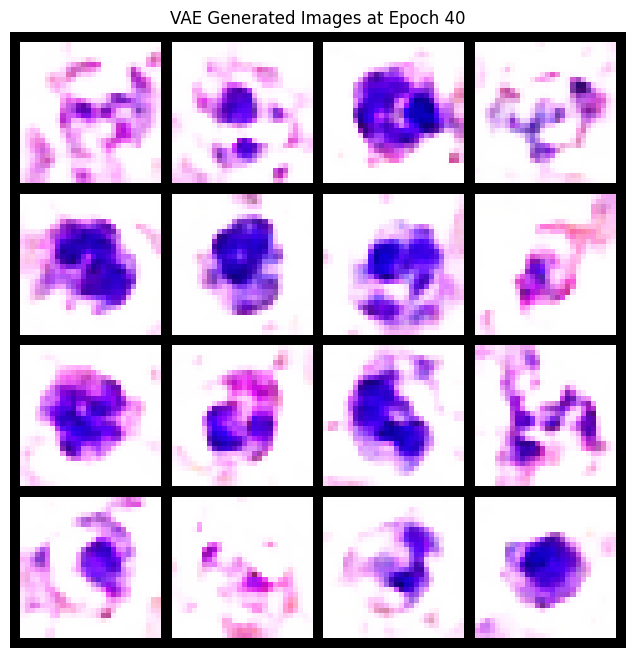

Epoch 40 FID: 160.1941
No improvement for 3 evaluations
Epoch [41/150] | Loss: 1035.7400 | Reconstruction: 1020.7954 | KLD: 149.4460
Epoch [42/150] | Loss: 1035.2484 | Reconstruction: 1020.3684 | KLD: 148.8004
Epoch [43/150] | Loss: 1035.3140 | Reconstruction: 1020.4269 | KLD: 148.8716
Epoch [44/150] | Loss: 1035.5334 | Reconstruction: 1020.6113 | KLD: 149.2215
Epoch [45/150] | Loss: 1034.7867 | Reconstruction: 1019.9113 | KLD: 148.7541


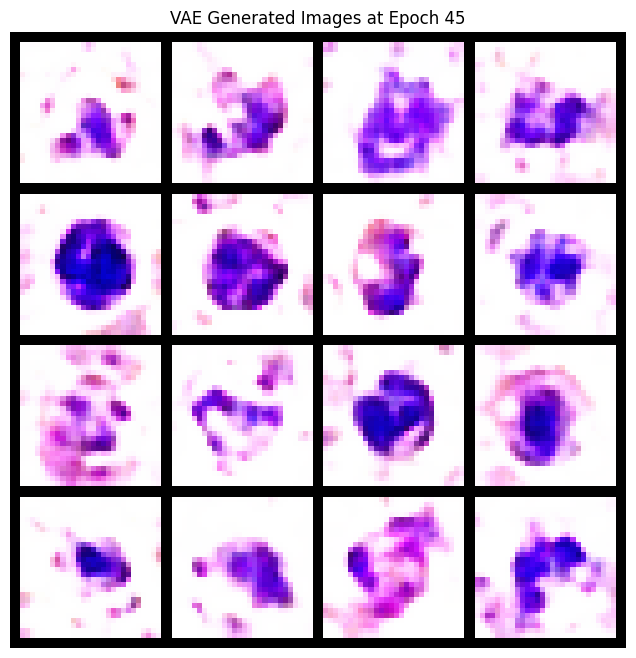

Epoch 45 FID: 162.5862
No improvement for 4 evaluations
Epoch [46/150] | Loss: 1034.0645 | Reconstruction: 1019.2130 | KLD: 148.5158
Epoch [47/150] | Loss: 1034.2685 | Reconstruction: 1019.3776 | KLD: 148.9084
Epoch [48/150] | Loss: 1034.3765 | Reconstruction: 1019.4801 | KLD: 148.9644
Epoch [49/150] | Loss: 1033.7885 | Reconstruction: 1018.9486 | KLD: 148.3988
Epoch [50/150] | Loss: 1033.6722 | Reconstruction: 1018.7960 | KLD: 148.7616


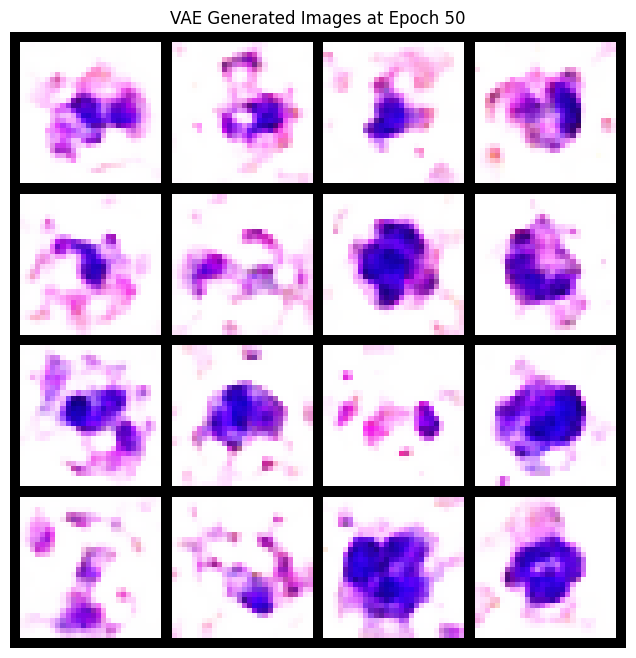

Epoch 50 FID: 161.7545
No improvement for 5 evaluations
Early stopping at epoch 50
FID Score for run 3: 150.4829


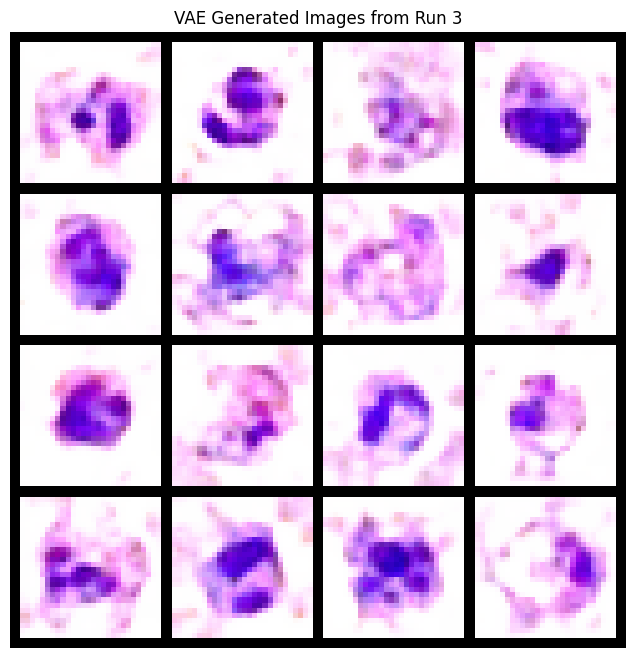


Run 4/5 with seed 789
Starting VAE training with hyperparameters: {'beta': 0.1, 'beta_schedule': None, 'epochs': 150, 'hidden_dims': [512, 256], 'latent_dim': 128, 'learning_rate': 0.0003}
Epoch [1/150] | Loss: 1556.2419 | Reconstruction: 1533.5687 | KLD: 226.7324


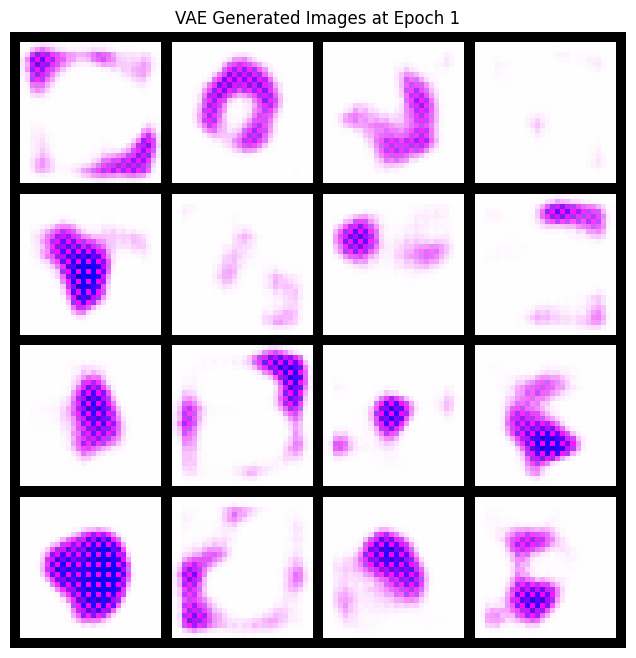

Epoch 1 FID: 374.3824
New best FID: 374.3824
Epoch [2/150] | Loss: 1210.8362 | Reconstruction: 1196.1073 | KLD: 147.2887
Epoch [3/150] | Loss: 1185.7144 | Reconstruction: 1170.5518 | KLD: 151.6255
Epoch [4/150] | Loss: 1110.5648 | Reconstruction: 1095.5349 | KLD: 150.2984
Epoch [5/150] | Loss: 1092.0981 | Reconstruction: 1077.0219 | KLD: 150.7616


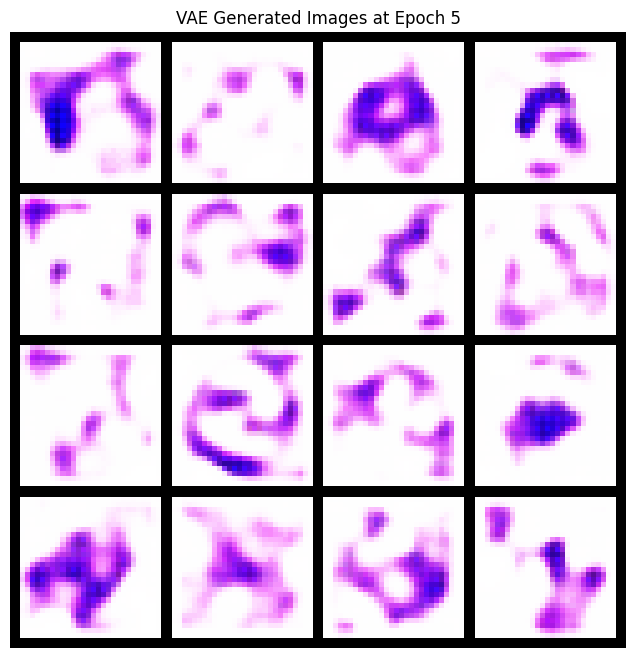

Epoch 5 FID: 226.0422
New best FID: 226.0422
Epoch [6/150] | Loss: 1084.2029 | Reconstruction: 1069.1619 | KLD: 150.4102
Epoch [7/150] | Loss: 1078.0310 | Reconstruction: 1063.1622 | KLD: 148.6877
Epoch [8/150] | Loss: 1073.5808 | Reconstruction: 1058.7780 | KLD: 148.0272
Epoch [9/150] | Loss: 1070.3121 | Reconstruction: 1055.5365 | KLD: 147.7556
Epoch [10/150] | Loss: 1067.9493 | Reconstruction: 1053.1062 | KLD: 148.4315


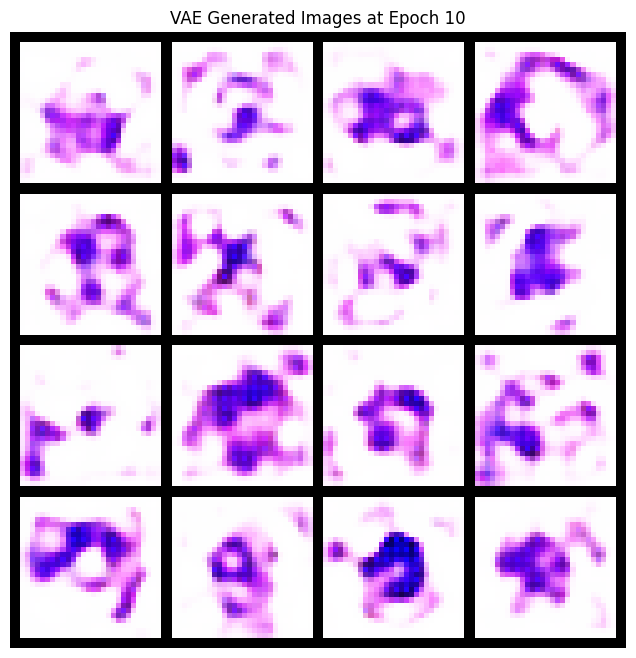

Epoch 10 FID: 195.7336
New best FID: 195.7336
Epoch [11/150] | Loss: 1060.5253 | Reconstruction: 1045.7644 | KLD: 147.6098
Epoch [12/150] | Loss: 1053.9263 | Reconstruction: 1038.9767 | KLD: 149.4966
Epoch [13/150] | Loss: 1052.8348 | Reconstruction: 1037.7748 | KLD: 150.6002
Epoch [14/150] | Loss: 1050.6580 | Reconstruction: 1035.7261 | KLD: 149.3191
Epoch [15/150] | Loss: 1049.8239 | Reconstruction: 1034.7881 | KLD: 150.3580


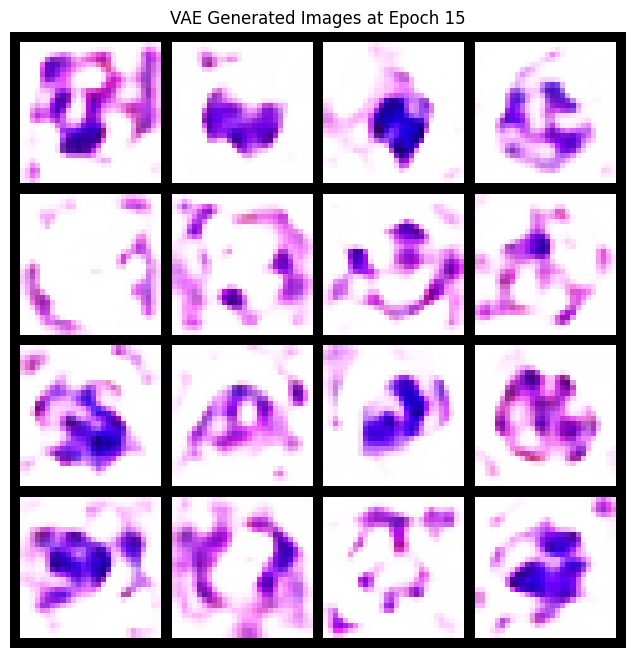

Epoch 15 FID: 184.6815
New best FID: 184.6815
Epoch [16/150] | Loss: 1047.7440 | Reconstruction: 1032.8119 | KLD: 149.3213
Epoch [17/150] | Loss: 1046.6445 | Reconstruction: 1031.7849 | KLD: 148.5964
Epoch [18/150] | Loss: 1046.0414 | Reconstruction: 1031.0879 | KLD: 149.5352
Epoch [19/150] | Loss: 1045.4777 | Reconstruction: 1030.5459 | KLD: 149.3180
Epoch [20/150] | Loss: 1045.0421 | Reconstruction: 1029.9903 | KLD: 150.5174


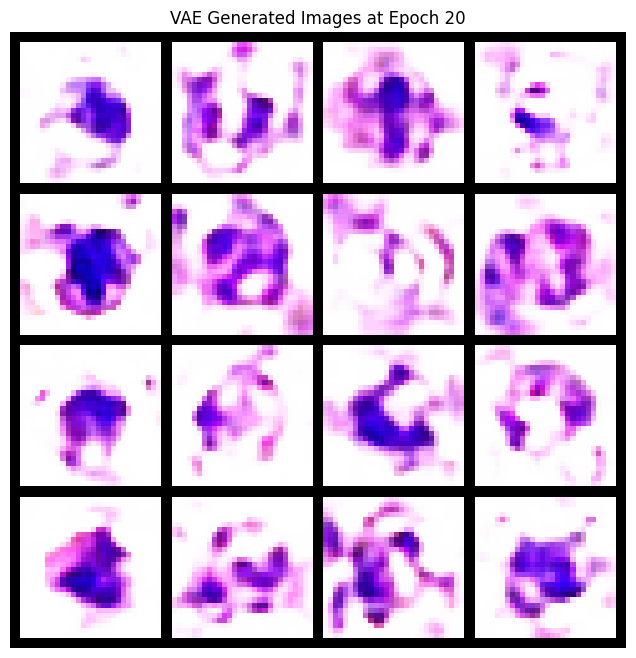

Epoch 20 FID: 179.8027
New best FID: 179.8027
Epoch [21/150] | Loss: 1043.7582 | Reconstruction: 1028.8184 | KLD: 149.3979
Epoch [22/150] | Loss: 1043.4706 | Reconstruction: 1028.4271 | KLD: 150.4351
Epoch [23/150] | Loss: 1042.4696 | Reconstruction: 1027.5042 | KLD: 149.6543
Epoch [24/150] | Loss: 1041.7603 | Reconstruction: 1026.7813 | KLD: 149.7897
Epoch [25/150] | Loss: 1041.4078 | Reconstruction: 1026.4490 | KLD: 149.5877


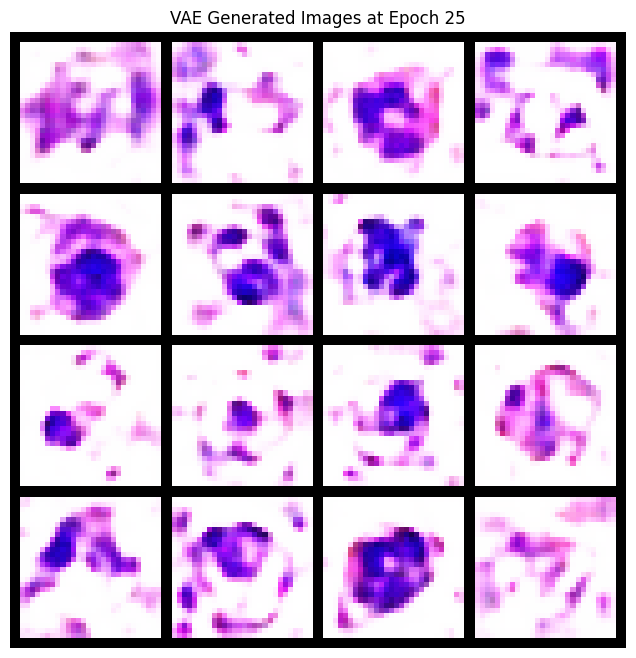

Epoch 25 FID: 173.2836
New best FID: 173.2836
Epoch [26/150] | Loss: 1041.9764 | Reconstruction: 1026.9263 | KLD: 150.5008
Epoch [27/150] | Loss: 1040.6427 | Reconstruction: 1025.6544 | KLD: 149.8832
Epoch [28/150] | Loss: 1040.4451 | Reconstruction: 1025.3924 | KLD: 150.5267
Epoch [29/150] | Loss: 1039.2889 | Reconstruction: 1024.3556 | KLD: 149.3334
Epoch [30/150] | Loss: 1038.6383 | Reconstruction: 1023.7113 | KLD: 149.2701


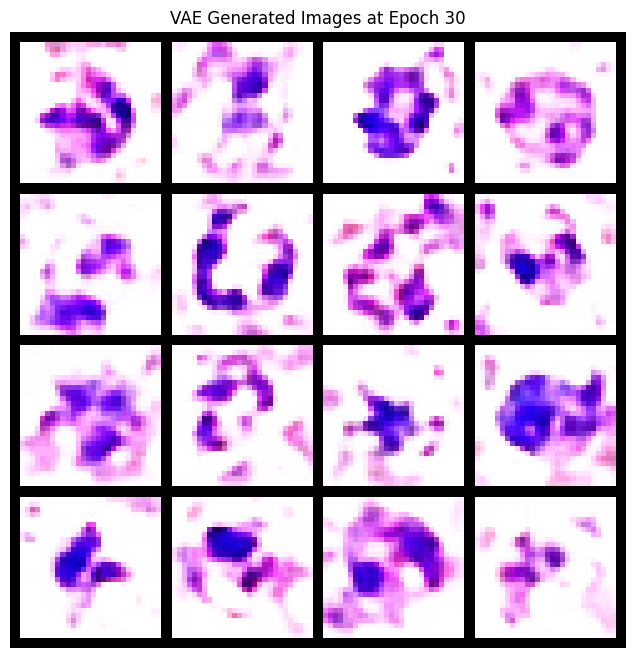

Epoch 30 FID: 173.0824
New best FID: 173.0824
Epoch [31/150] | Loss: 1038.5588 | Reconstruction: 1023.6537 | KLD: 149.0508
Epoch [32/150] | Loss: 1038.5570 | Reconstruction: 1023.5722 | KLD: 149.8476
Epoch [33/150] | Loss: 1037.5946 | Reconstruction: 1022.6313 | KLD: 149.6332
Epoch [34/150] | Loss: 1037.0639 | Reconstruction: 1022.1792 | KLD: 148.8477
Epoch [35/150] | Loss: 1036.8159 | Reconstruction: 1021.8821 | KLD: 149.3380


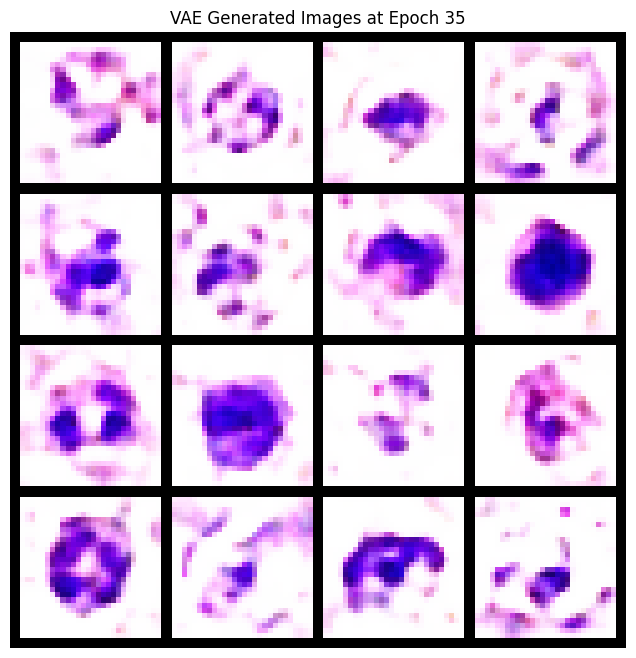

Epoch 35 FID: 174.4957
No improvement for 1 evaluations
Epoch [36/150] | Loss: 1036.8770 | Reconstruction: 1021.9257 | KLD: 149.5125
Epoch [37/150] | Loss: 1036.1071 | Reconstruction: 1021.1955 | KLD: 149.1160
Epoch [38/150] | Loss: 1036.4119 | Reconstruction: 1021.5027 | KLD: 149.0916
Epoch [39/150] | Loss: 1035.9186 | Reconstruction: 1020.9754 | KLD: 149.4324
Epoch [40/150] | Loss: 1036.2099 | Reconstruction: 1021.1900 | KLD: 150.1986


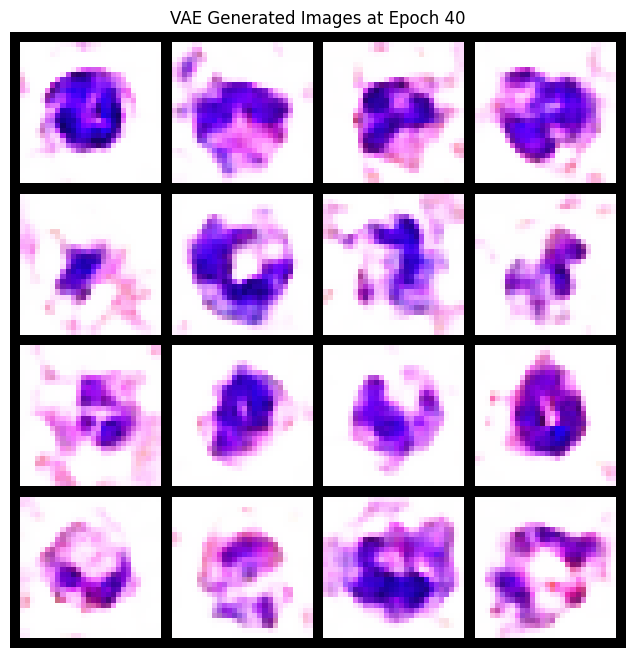

Epoch 40 FID: 174.4475
No improvement for 2 evaluations
Epoch [41/150] | Loss: 1035.1199 | Reconstruction: 1020.1762 | KLD: 149.4370
Epoch [42/150] | Loss: 1034.7842 | Reconstruction: 1019.9091 | KLD: 148.7505
Epoch [43/150] | Loss: 1034.1257 | Reconstruction: 1019.2360 | KLD: 148.8974
Epoch [44/150] | Loss: 1034.6308 | Reconstruction: 1019.7331 | KLD: 148.9771
Epoch [45/150] | Loss: 1034.2532 | Reconstruction: 1019.3585 | KLD: 148.9475


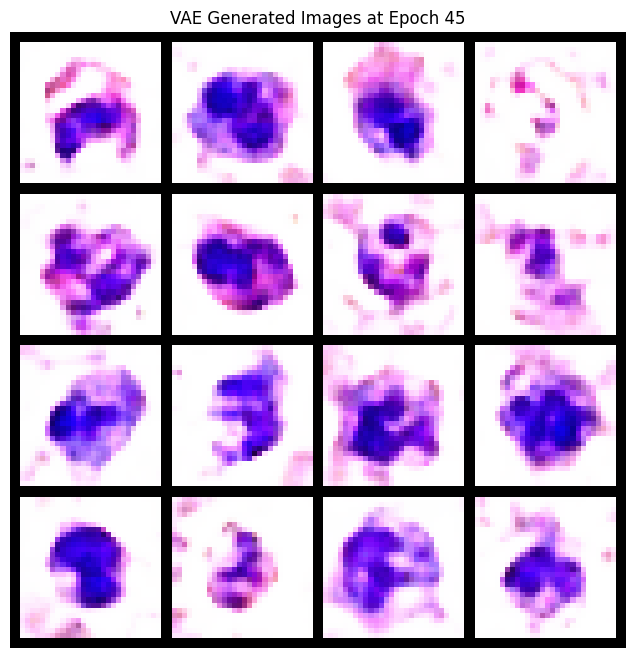

Epoch 45 FID: 168.6643
New best FID: 168.6643
Epoch [46/150] | Loss: 1033.5502 | Reconstruction: 1018.7015 | KLD: 148.4867
Epoch [47/150] | Loss: 1033.4586 | Reconstruction: 1018.6127 | KLD: 148.4581
Epoch [48/150] | Loss: 1033.4480 | Reconstruction: 1018.5648 | KLD: 148.8320
Epoch [49/150] | Loss: 1032.5177 | Reconstruction: 1017.6921 | KLD: 148.2558
Epoch [50/150] | Loss: 1032.5705 | Reconstruction: 1017.7892 | KLD: 147.8133


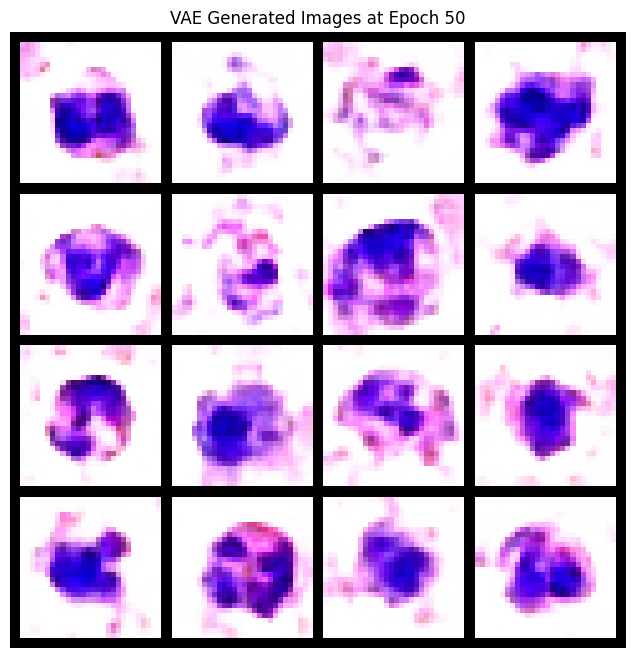

Epoch 50 FID: 167.3090
New best FID: 167.3090
Epoch [51/150] | Loss: 1032.6336 | Reconstruction: 1017.8100 | KLD: 148.2364
Epoch [52/150] | Loss: 1032.2747 | Reconstruction: 1017.4850 | KLD: 147.8969
Epoch [53/150] | Loss: 1032.3963 | Reconstruction: 1017.5365 | KLD: 148.5974
Epoch [54/150] | Loss: 1031.9546 | Reconstruction: 1017.1188 | KLD: 148.3577
Epoch [55/150] | Loss: 1031.2576 | Reconstruction: 1016.5091 | KLD: 147.4849


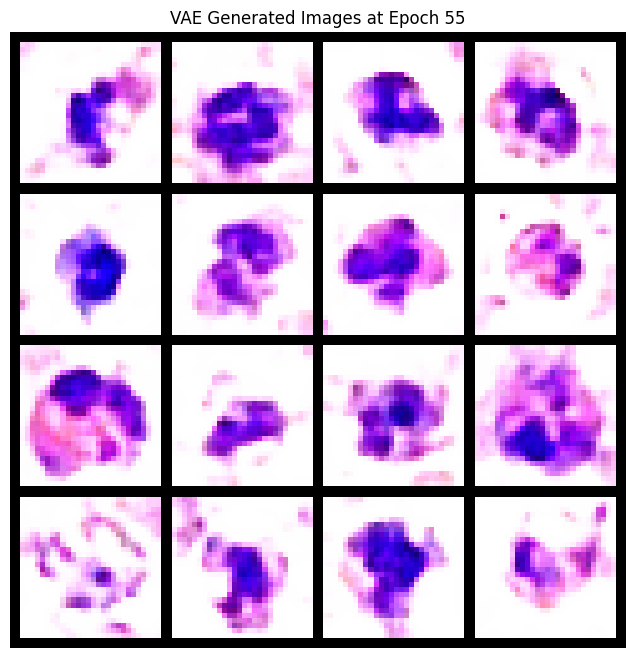

Epoch 55 FID: 171.2695
No improvement for 1 evaluations
Epoch [56/150] | Loss: 1031.2045 | Reconstruction: 1016.4665 | KLD: 147.3795
Epoch [57/150] | Loss: 1030.9943 | Reconstruction: 1016.2029 | KLD: 147.9139
Epoch [58/150] | Loss: 1031.4875 | Reconstruction: 1016.6937 | KLD: 147.9386
Epoch [59/150] | Loss: 1030.7097 | Reconstruction: 1015.9480 | KLD: 147.6171
Epoch [60/150] | Loss: 1030.2273 | Reconstruction: 1015.4854 | KLD: 147.4187


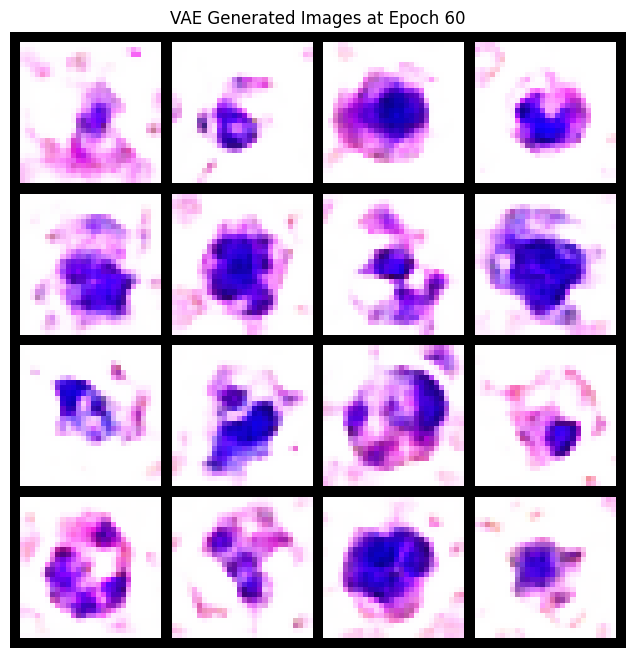

Epoch 60 FID: 169.5600
No improvement for 2 evaluations
Epoch [61/150] | Loss: 1030.3819 | Reconstruction: 1015.6431 | KLD: 147.3881
Epoch [62/150] | Loss: 1030.0315 | Reconstruction: 1015.2994 | KLD: 147.3208
Epoch [63/150] | Loss: 1030.5289 | Reconstruction: 1015.7518 | KLD: 147.7708
Epoch [64/150] | Loss: 1030.3976 | Reconstruction: 1015.6223 | KLD: 147.7525
Epoch [65/150] | Loss: 1030.1567 | Reconstruction: 1015.4353 | KLD: 147.2142


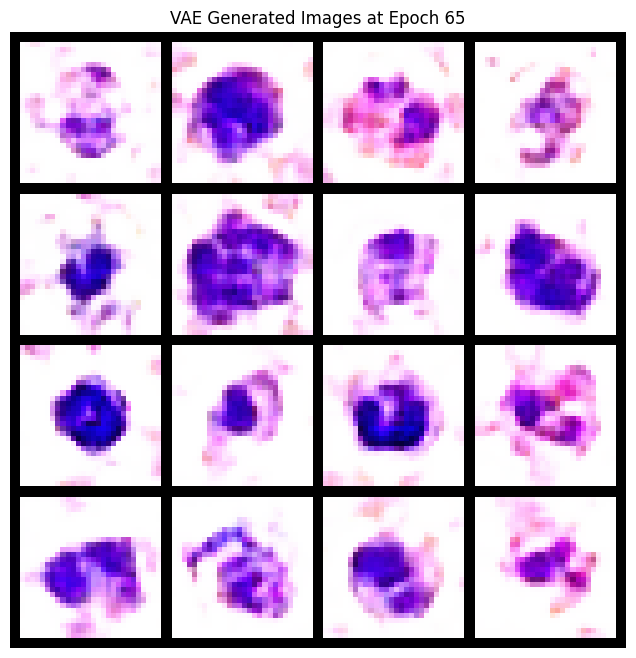

Epoch 65 FID: 169.0694
No improvement for 3 evaluations
Epoch [66/150] | Loss: 1029.5769 | Reconstruction: 1014.8728 | KLD: 147.0412
Epoch [67/150] | Loss: 1028.9697 | Reconstruction: 1014.3205 | KLD: 146.4918
Epoch [68/150] | Loss: 1029.0507 | Reconstruction: 1014.4023 | KLD: 146.4838
Epoch [69/150] | Loss: 1028.8585 | Reconstruction: 1014.2000 | KLD: 146.5856
Epoch [70/150] | Loss: 1028.8535 | Reconstruction: 1014.2128 | KLD: 146.4072


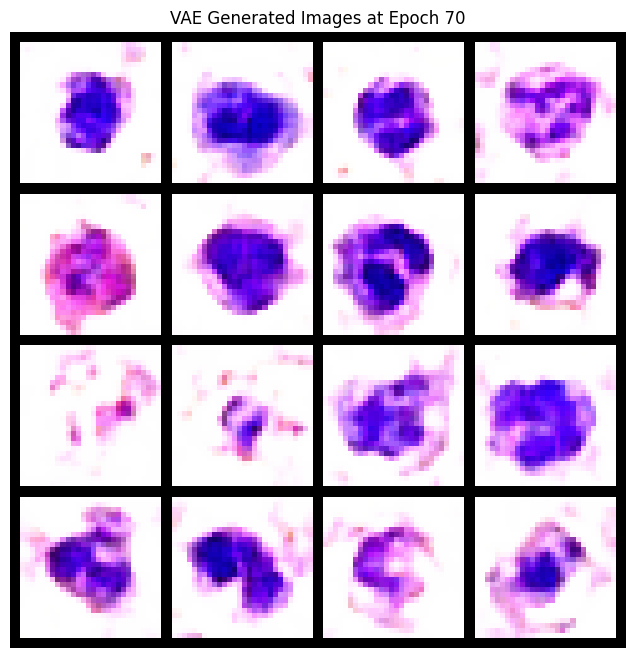

Epoch 70 FID: 170.7144
No improvement for 4 evaluations
Epoch [71/150] | Loss: 1028.3639 | Reconstruction: 1013.7421 | KLD: 146.2178
Epoch [72/150] | Loss: 1028.6137 | Reconstruction: 1013.9703 | KLD: 146.4345
Epoch [73/150] | Loss: 1028.5320 | Reconstruction: 1013.9158 | KLD: 146.1623
Epoch [74/150] | Loss: 1028.6263 | Reconstruction: 1013.9590 | KLD: 146.6723
Epoch [75/150] | Loss: 1028.2202 | Reconstruction: 1013.6346 | KLD: 145.8558


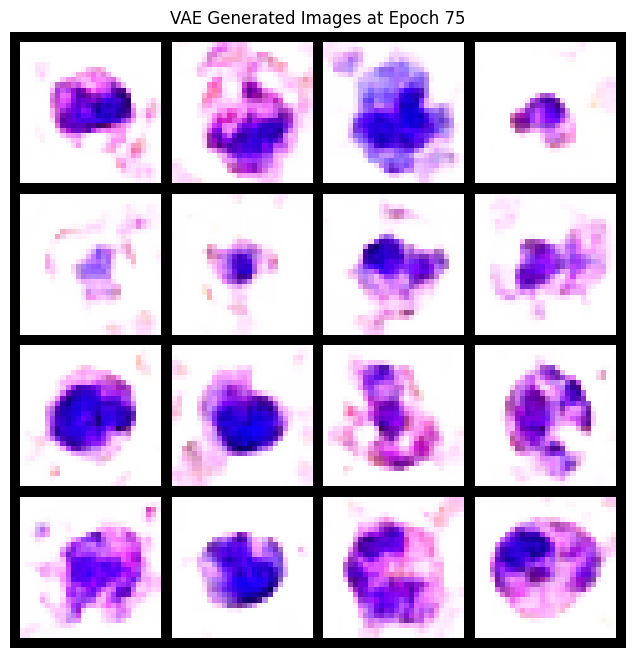

Epoch 75 FID: 167.2323
New best FID: 167.2323
Epoch [76/150] | Loss: 1027.6982 | Reconstruction: 1013.1059 | KLD: 145.9233
Epoch [77/150] | Loss: 1027.7535 | Reconstruction: 1013.1627 | KLD: 145.9084
Epoch [78/150] | Loss: 1028.1442 | Reconstruction: 1013.5486 | KLD: 145.9563
Epoch [79/150] | Loss: 1027.5646 | Reconstruction: 1012.9994 | KLD: 145.6525
Epoch [80/150] | Loss: 1027.5871 | Reconstruction: 1013.0074 | KLD: 145.7973


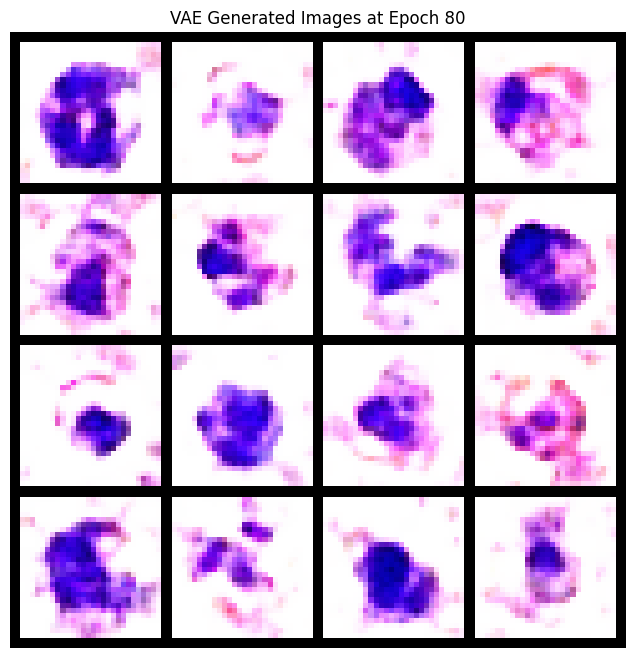

Epoch 80 FID: 170.1153
No improvement for 1 evaluations
Epoch [81/150] | Loss: 1027.2930 | Reconstruction: 1012.7241 | KLD: 145.6890
Epoch [82/150] | Loss: 1027.2509 | Reconstruction: 1012.7308 | KLD: 145.2019
Epoch [83/150] | Loss: 1026.8933 | Reconstruction: 1012.3827 | KLD: 145.1060
Epoch [84/150] | Loss: 1026.4881 | Reconstruction: 1012.0018 | KLD: 144.8630
Epoch [85/150] | Loss: 1026.6958 | Reconstruction: 1012.1824 | KLD: 145.1343


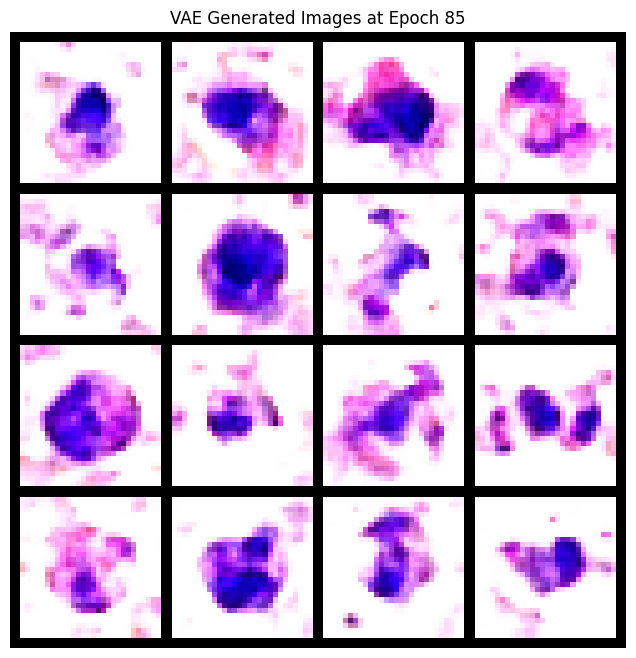

Epoch 85 FID: 168.5885
No improvement for 2 evaluations
Epoch [86/150] | Loss: 1026.7864 | Reconstruction: 1012.3180 | KLD: 144.6838
Epoch [87/150] | Loss: 1026.1532 | Reconstruction: 1011.6681 | KLD: 144.8515
Epoch [88/150] | Loss: 1026.0580 | Reconstruction: 1011.5971 | KLD: 144.6092
Epoch [89/150] | Loss: 1026.0818 | Reconstruction: 1011.6506 | KLD: 144.3119
Epoch [90/150] | Loss: 1026.6230 | Reconstruction: 1012.1504 | KLD: 144.7253


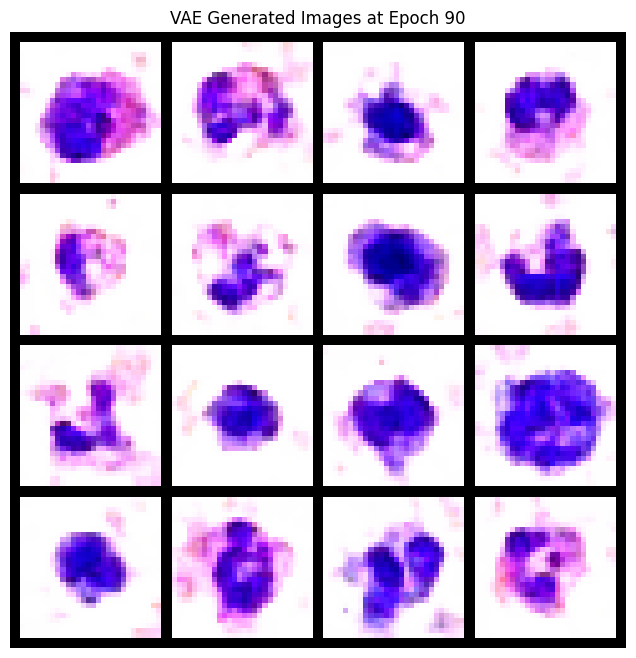

Epoch 90 FID: 164.0761
New best FID: 164.0761
Epoch [91/150] | Loss: 1025.6660 | Reconstruction: 1011.2589 | KLD: 144.0717
Epoch [92/150] | Loss: 1026.2531 | Reconstruction: 1011.8056 | KLD: 144.4753
Epoch [93/150] | Loss: 1025.8974 | Reconstruction: 1011.4474 | KLD: 144.5004
Epoch [94/150] | Loss: 1025.8091 | Reconstruction: 1011.3935 | KLD: 144.1554
Epoch [95/150] | Loss: 1025.4368 | Reconstruction: 1011.0353 | KLD: 144.0153


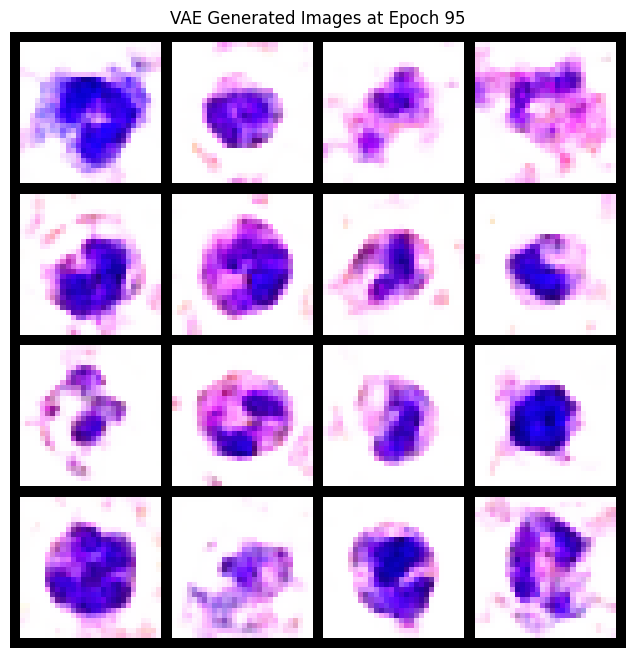

Epoch 95 FID: 166.1529
No improvement for 1 evaluations
Epoch [96/150] | Loss: 1025.2749 | Reconstruction: 1010.9041 | KLD: 143.7086
Epoch [97/150] | Loss: 1025.2180 | Reconstruction: 1010.8366 | KLD: 143.8137
Epoch [98/150] | Loss: 1025.0867 | Reconstruction: 1010.7247 | KLD: 143.6201
Epoch [99/150] | Loss: 1026.2048 | Reconstruction: 1011.7984 | KLD: 144.0644
Epoch [100/150] | Loss: 1025.5342 | Reconstruction: 1011.1536 | KLD: 143.8052


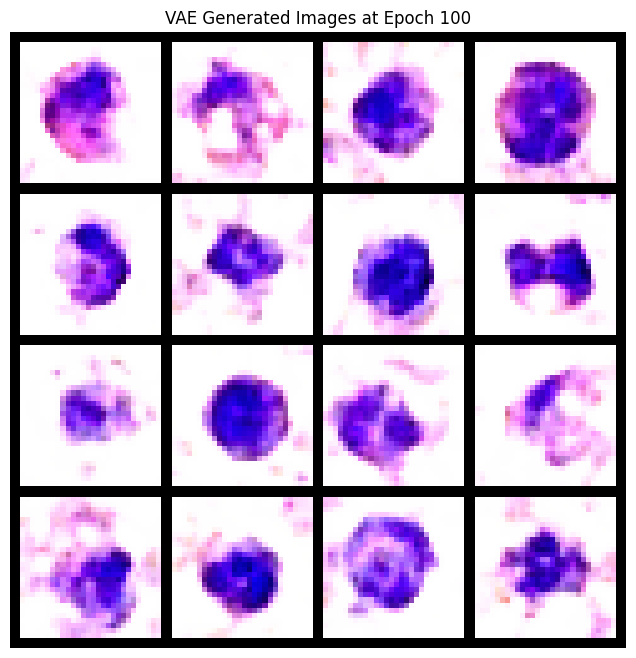

Epoch 100 FID: 163.2807
New best FID: 163.2807
Epoch [101/150] | Loss: 1025.0125 | Reconstruction: 1010.6618 | KLD: 143.5075
Epoch [102/150] | Loss: 1025.5778 | Reconstruction: 1011.2117 | KLD: 143.6610
Epoch [103/150] | Loss: 1025.0281 | Reconstruction: 1010.6873 | KLD: 143.4078
Epoch [104/150] | Loss: 1024.9142 | Reconstruction: 1010.5793 | KLD: 143.3496
Epoch [105/150] | Loss: 1024.8236 | Reconstruction: 1010.4855 | KLD: 143.3805


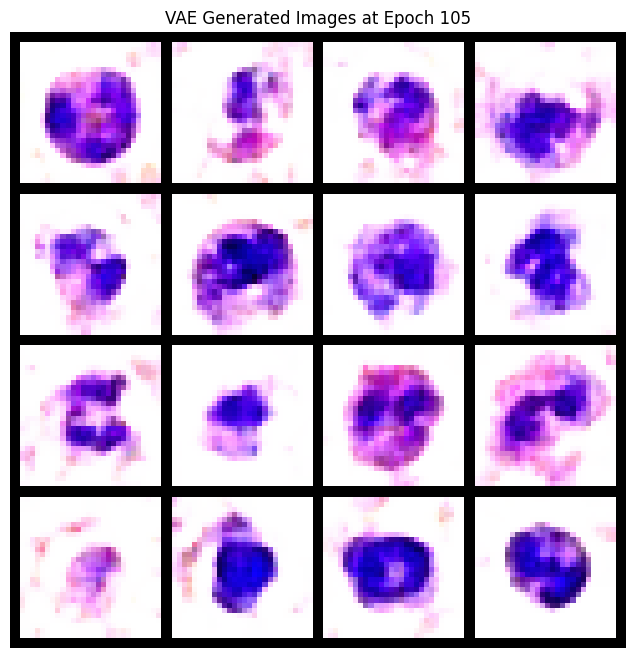

Epoch 105 FID: 164.5529
No improvement for 1 evaluations
Epoch [106/150] | Loss: 1024.8548 | Reconstruction: 1010.5526 | KLD: 143.0220
Epoch [107/150] | Loss: 1024.7350 | Reconstruction: 1010.4332 | KLD: 143.0181
Epoch [108/150] | Loss: 1024.8382 | Reconstruction: 1010.5220 | KLD: 143.1623
Epoch [109/150] | Loss: 1024.6345 | Reconstruction: 1010.3342 | KLD: 143.0023
Epoch [110/150] | Loss: 1024.1575 | Reconstruction: 1009.8872 | KLD: 142.7025


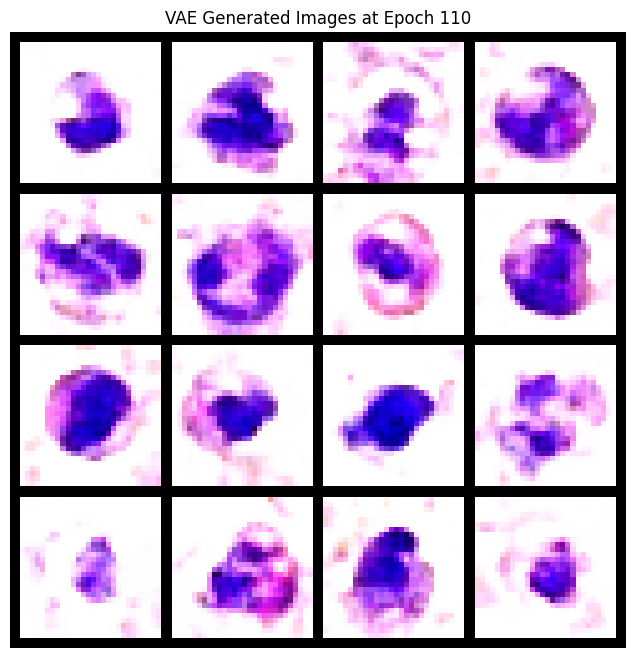

Epoch 110 FID: 164.9145
No improvement for 2 evaluations
Epoch [111/150] | Loss: 1024.0142 | Reconstruction: 1009.7708 | KLD: 142.4333
Epoch [112/150] | Loss: 1023.9708 | Reconstruction: 1009.7205 | KLD: 142.5035
Epoch [113/150] | Loss: 1024.0533 | Reconstruction: 1009.7827 | KLD: 142.7067
Epoch [114/150] | Loss: 1023.8334 | Reconstruction: 1009.6160 | KLD: 142.1739
Epoch [115/150] | Loss: 1023.9193 | Reconstruction: 1009.7133 | KLD: 142.0607


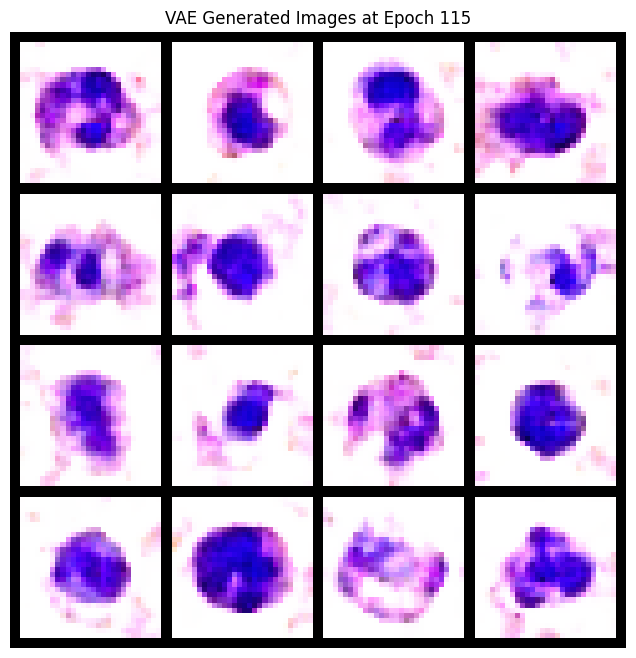

Epoch 115 FID: 165.8114
No improvement for 3 evaluations
Epoch [116/150] | Loss: 1023.6174 | Reconstruction: 1009.4076 | KLD: 142.0978
Epoch [117/150] | Loss: 1023.6277 | Reconstruction: 1009.4171 | KLD: 142.1069
Epoch [118/150] | Loss: 1023.5452 | Reconstruction: 1009.3594 | KLD: 141.8578
Epoch [119/150] | Loss: 1023.6762 | Reconstruction: 1009.4771 | KLD: 141.9912
Epoch [120/150] | Loss: 1023.2567 | Reconstruction: 1009.0783 | KLD: 141.7843


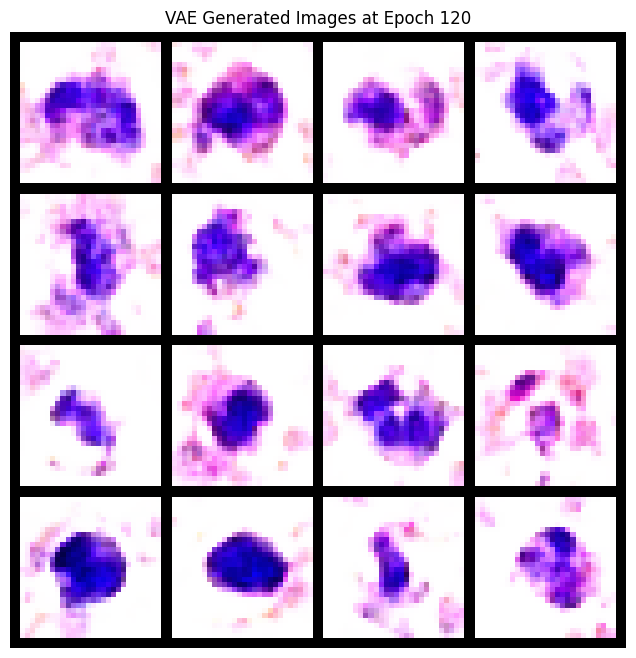

Epoch 120 FID: 164.3453
No improvement for 4 evaluations
Epoch [121/150] | Loss: 1023.7118 | Reconstruction: 1009.5366 | KLD: 141.7521
Epoch [122/150] | Loss: 1023.2266 | Reconstruction: 1009.0643 | KLD: 141.6236
Epoch [123/150] | Loss: 1023.5724 | Reconstruction: 1009.4250 | KLD: 141.4733
Epoch [124/150] | Loss: 1023.4597 | Reconstruction: 1009.3139 | KLD: 141.4581
Epoch [125/150] | Loss: 1023.2085 | Reconstruction: 1009.0508 | KLD: 141.5772


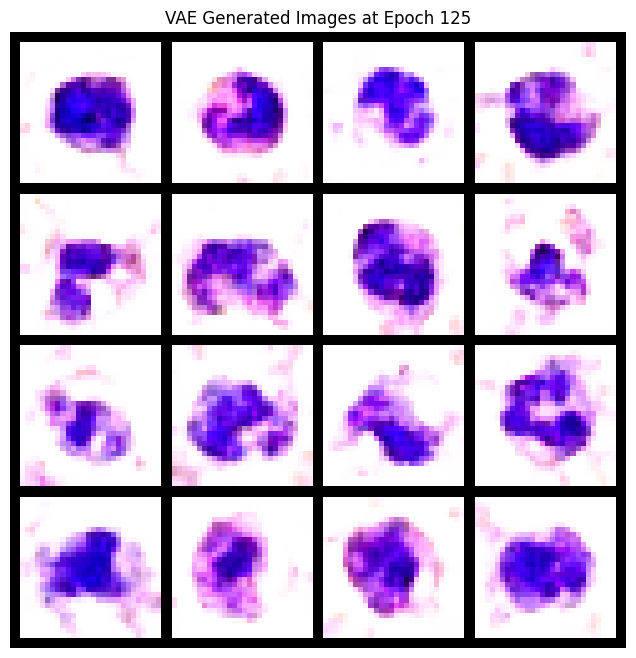

Epoch 125 FID: 163.0769
New best FID: 163.0769
Epoch [126/150] | Loss: 1022.9769 | Reconstruction: 1008.8469 | KLD: 141.3007
Epoch [127/150] | Loss: 1022.8582 | Reconstruction: 1008.7568 | KLD: 141.0145
Epoch [128/150] | Loss: 1022.9642 | Reconstruction: 1008.8576 | KLD: 141.0665
Epoch [129/150] | Loss: 1023.0627 | Reconstruction: 1008.9366 | KLD: 141.2616
Epoch [130/150] | Loss: 1022.5614 | Reconstruction: 1008.4772 | KLD: 140.8424


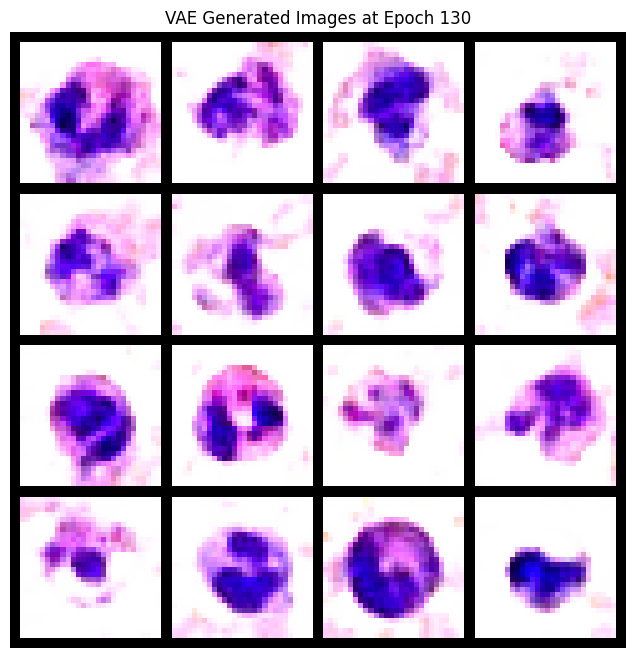

Epoch 130 FID: 168.0016
No improvement for 1 evaluations
Epoch [131/150] | Loss: 1022.8368 | Reconstruction: 1008.7596 | KLD: 140.7721
Epoch [132/150] | Loss: 1022.8942 | Reconstruction: 1008.8365 | KLD: 140.5765
Epoch [133/150] | Loss: 1022.4949 | Reconstruction: 1008.4218 | KLD: 140.7304
Epoch [134/150] | Loss: 1022.6984 | Reconstruction: 1008.6540 | KLD: 140.4437
Epoch [135/150] | Loss: 1022.6277 | Reconstruction: 1008.5808 | KLD: 140.4687


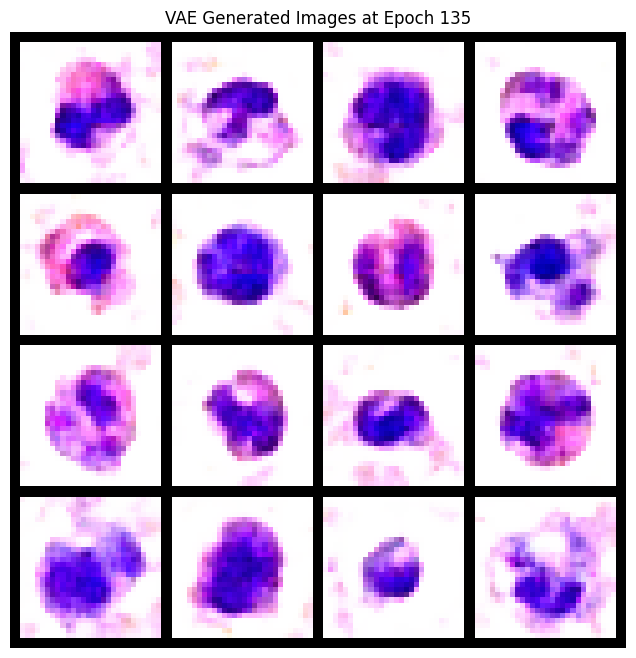

Epoch 135 FID: 162.6830
New best FID: 162.6830
Epoch [136/150] | Loss: 1022.5181 | Reconstruction: 1008.4954 | KLD: 140.2271
Epoch [137/150] | Loss: 1022.3580 | Reconstruction: 1008.3303 | KLD: 140.2778
Epoch [138/150] | Loss: 1022.0612 | Reconstruction: 1008.0562 | KLD: 140.0493
Epoch [139/150] | Loss: 1022.3048 | Reconstruction: 1008.3162 | KLD: 139.8868
Epoch [140/150] | Loss: 1022.2981 | Reconstruction: 1008.3041 | KLD: 139.9401


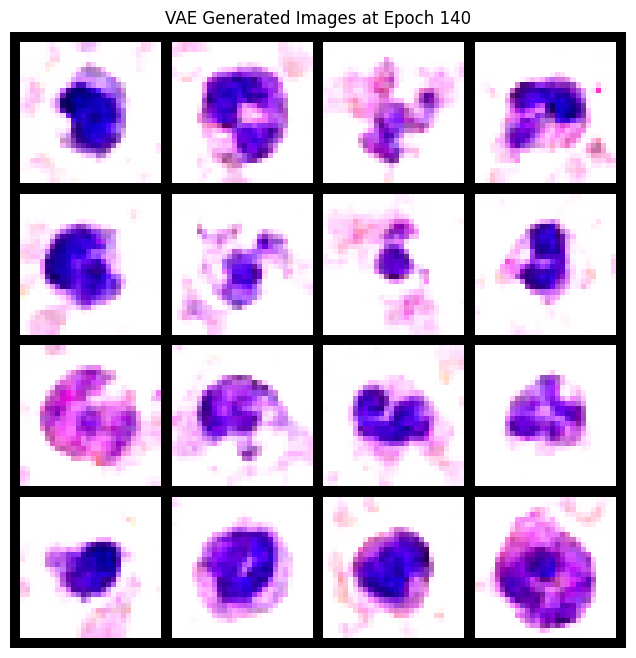

Epoch 140 FID: 165.6591
No improvement for 1 evaluations
Epoch [141/150] | Loss: 1022.1002 | Reconstruction: 1008.1169 | KLD: 139.8322
Epoch [142/150] | Loss: 1021.9947 | Reconstruction: 1007.9966 | KLD: 139.9807
Epoch [143/150] | Loss: 1022.1680 | Reconstruction: 1008.1948 | KLD: 139.7326
Epoch [144/150] | Loss: 1021.9572 | Reconstruction: 1007.9924 | KLD: 139.6480
Epoch [145/150] | Loss: 1021.8861 | Reconstruction: 1007.9316 | KLD: 139.5451


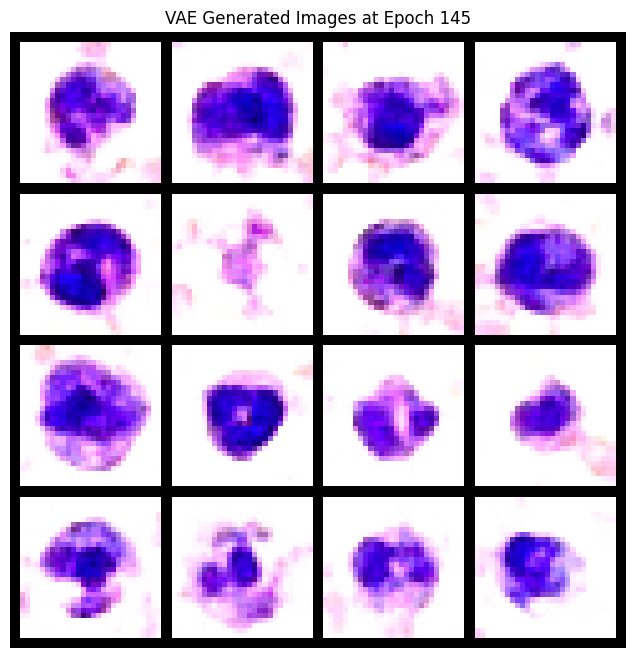

Epoch 145 FID: 164.8468
No improvement for 2 evaluations
Epoch [146/150] | Loss: 1021.7599 | Reconstruction: 1007.8188 | KLD: 139.4113
Epoch [147/150] | Loss: 1021.5664 | Reconstruction: 1007.6389 | KLD: 139.2752
Epoch [148/150] | Loss: 1021.6521 | Reconstruction: 1007.7215 | KLD: 139.3060
Epoch [149/150] | Loss: 1021.9427 | Reconstruction: 1007.9953 | KLD: 139.4742
Epoch [150/150] | Loss: 1021.8375 | Reconstruction: 1007.9164 | KLD: 139.2109


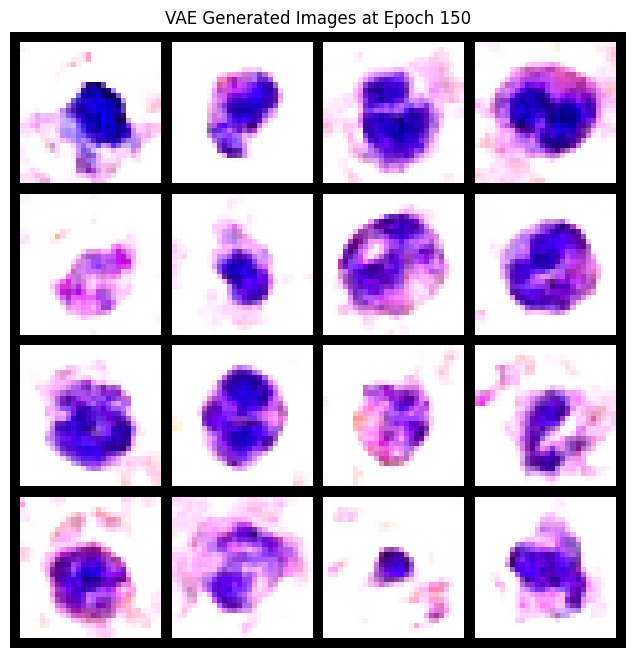

Epoch 150 FID: 160.8725
New best FID: 160.8725
FID Score for run 4: 145.1109


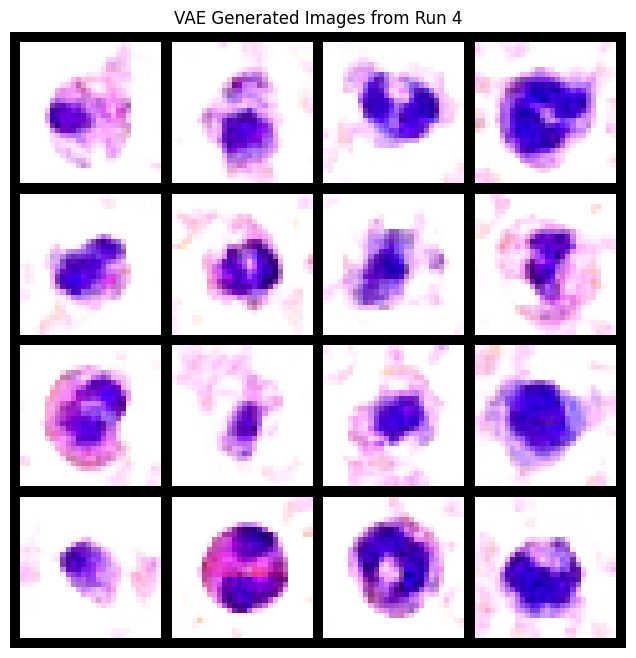


Run 5/5 with seed 1010
Starting VAE training with hyperparameters: {'beta': 0.1, 'beta_schedule': None, 'epochs': 150, 'hidden_dims': [512, 256], 'latent_dim': 128, 'learning_rate': 0.0003}
Epoch [1/150] | Loss: 1650.4980 | Reconstruction: 1627.1600 | KLD: 233.3795


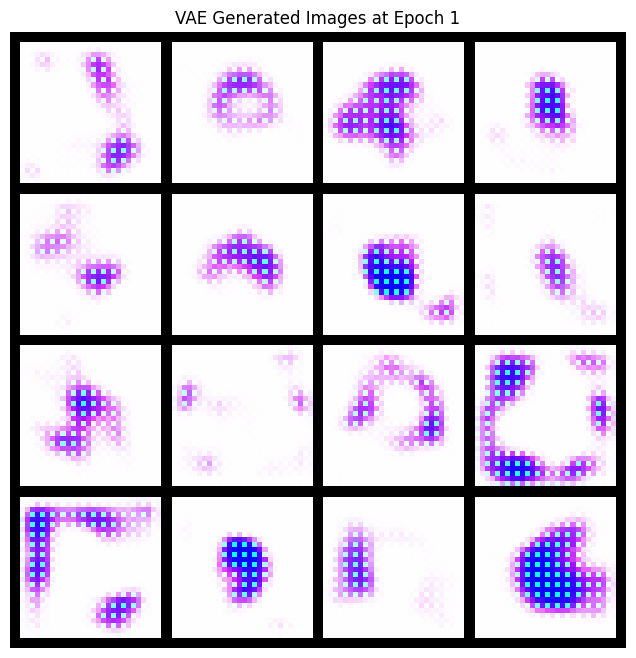

Epoch 1 FID: 369.3446
New best FID: 369.3446
Epoch [2/150] | Loss: 1305.8205 | Reconstruction: 1291.1058 | KLD: 147.1460
Epoch [3/150] | Loss: 1287.6450 | Reconstruction: 1273.3733 | KLD: 142.7171
Epoch [4/150] | Loss: 1276.8065 | Reconstruction: 1263.3643 | KLD: 134.4213
Epoch [5/150] | Loss: 1189.5746 | Reconstruction: 1175.6873 | KLD: 138.8727


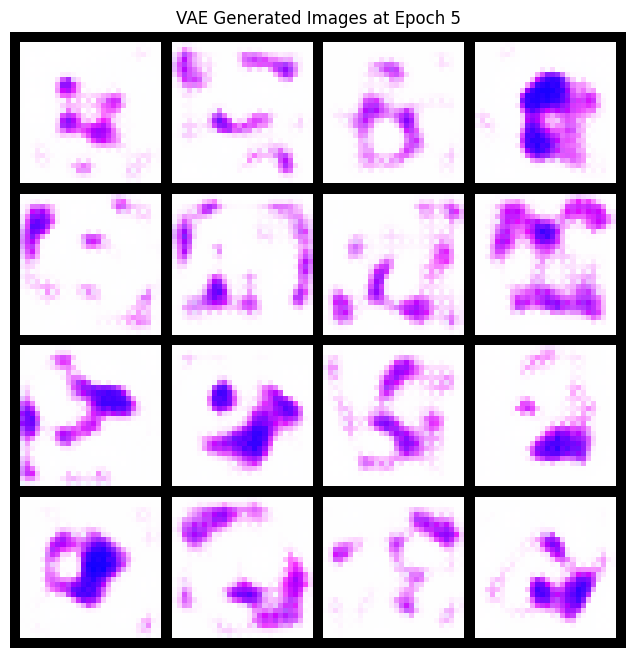

Epoch 5 FID: 241.3868
New best FID: 241.3868
Epoch [6/150] | Loss: 1114.3203 | Reconstruction: 1099.8353 | KLD: 144.8500
Epoch [7/150] | Loss: 1107.5413 | Reconstruction: 1093.1579 | KLD: 143.8346
Epoch [8/150] | Loss: 1102.3463 | Reconstruction: 1088.5880 | KLD: 137.5821
Epoch [9/150] | Loss: 1100.5457 | Reconstruction: 1086.5835 | KLD: 139.6215
Epoch [10/150] | Loss: 1098.3425 | Reconstruction: 1084.4722 | KLD: 138.7032


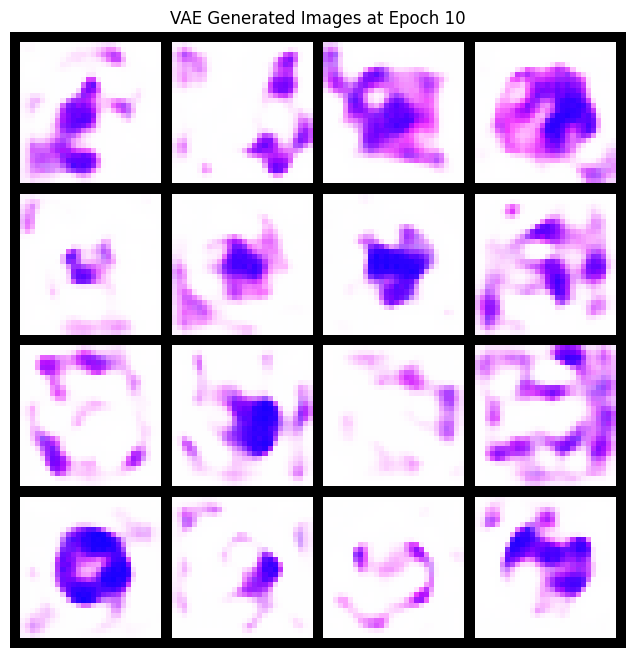

Epoch 10 FID: 192.9338
New best FID: 192.9338
Epoch [11/150] | Loss: 1095.9189 | Reconstruction: 1082.1983 | KLD: 137.2058
Epoch [12/150] | Loss: 1094.6985 | Reconstruction: 1081.0244 | KLD: 136.7413
Epoch [13/150] | Loss: 1089.5848 | Reconstruction: 1075.8689 | KLD: 137.1595
Epoch [14/150] | Loss: 1077.8459 | Reconstruction: 1063.8791 | KLD: 139.6689
Epoch [15/150] | Loss: 1071.7902 | Reconstruction: 1057.8818 | KLD: 139.0841


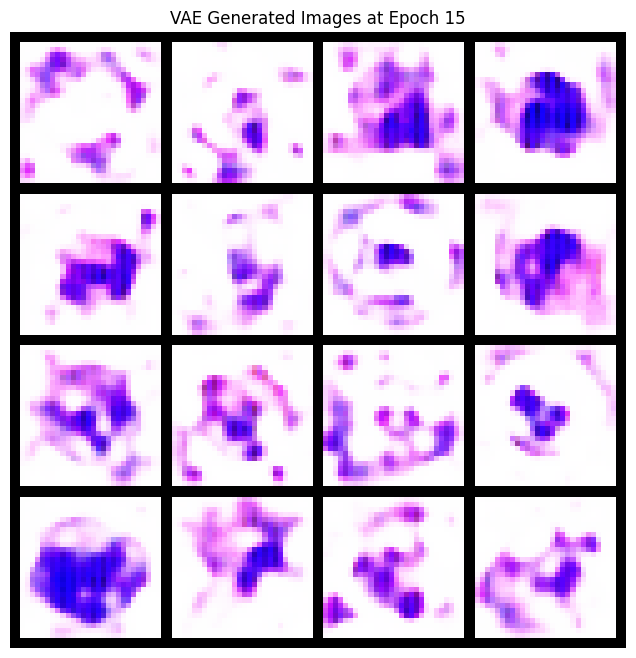

Epoch 15 FID: 182.3563
New best FID: 182.3563
Epoch [16/150] | Loss: 1070.9603 | Reconstruction: 1056.9929 | KLD: 139.6738
Epoch [17/150] | Loss: 1064.1900 | Reconstruction: 1049.9126 | KLD: 142.7747
Epoch [18/150] | Loss: 1059.1580 | Reconstruction: 1044.8855 | KLD: 142.7250
Epoch [19/150] | Loss: 1058.7567 | Reconstruction: 1044.4584 | KLD: 142.9835
Epoch [20/150] | Loss: 1057.2555 | Reconstruction: 1042.9134 | KLD: 143.4209


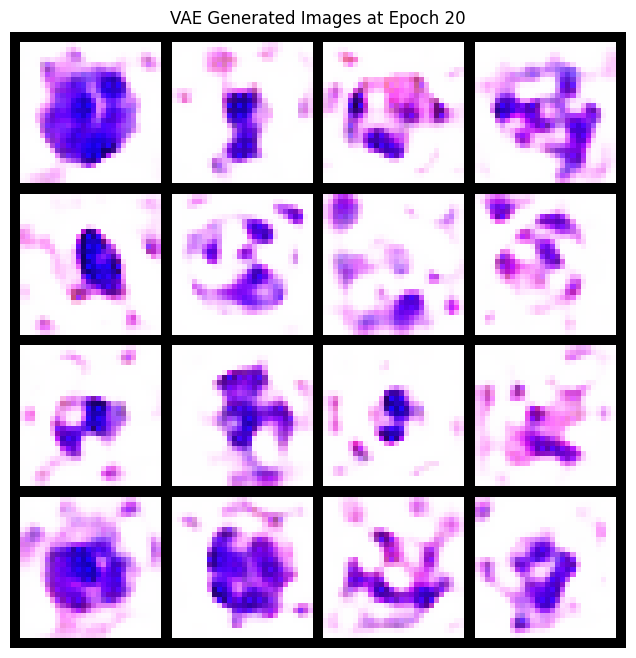

Epoch 20 FID: 172.8097
New best FID: 172.8097
Epoch [21/150] | Loss: 1056.0325 | Reconstruction: 1041.7803 | KLD: 142.5223
Epoch [22/150] | Loss: 1054.9709 | Reconstruction: 1040.7255 | KLD: 142.4547
Epoch [23/150] | Loss: 1056.2924 | Reconstruction: 1041.8793 | KLD: 144.1302
Epoch [24/150] | Loss: 1053.7373 | Reconstruction: 1039.4290 | KLD: 143.0825
Epoch [25/150] | Loss: 1047.1380 | Reconstruction: 1032.8129 | KLD: 143.2505


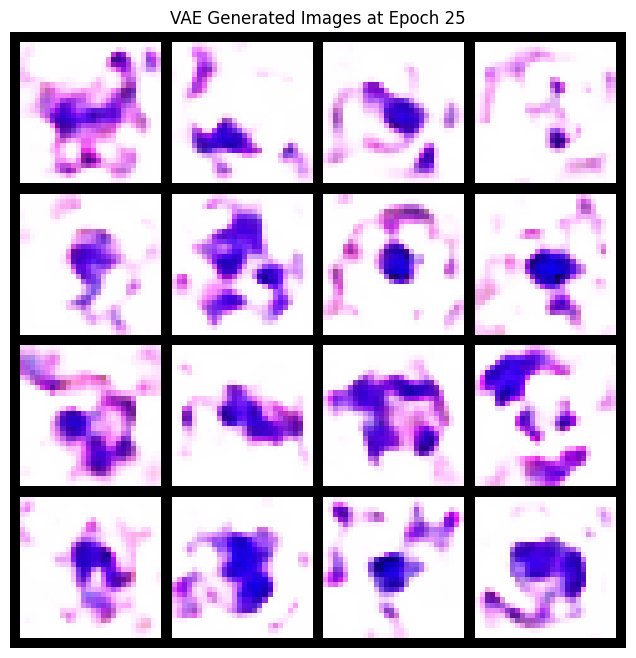

Epoch 25 FID: 163.9539
New best FID: 163.9539
Epoch [26/150] | Loss: 1042.9816 | Reconstruction: 1028.4347 | KLD: 145.4688
Epoch [27/150] | Loss: 1041.8079 | Reconstruction: 1027.3167 | KLD: 144.9125
Epoch [28/150] | Loss: 1041.6722 | Reconstruction: 1027.1478 | KLD: 145.2440
Epoch [29/150] | Loss: 1041.0559 | Reconstruction: 1026.4955 | KLD: 145.6038
Epoch [30/150] | Loss: 1040.8276 | Reconstruction: 1026.2058 | KLD: 146.2187


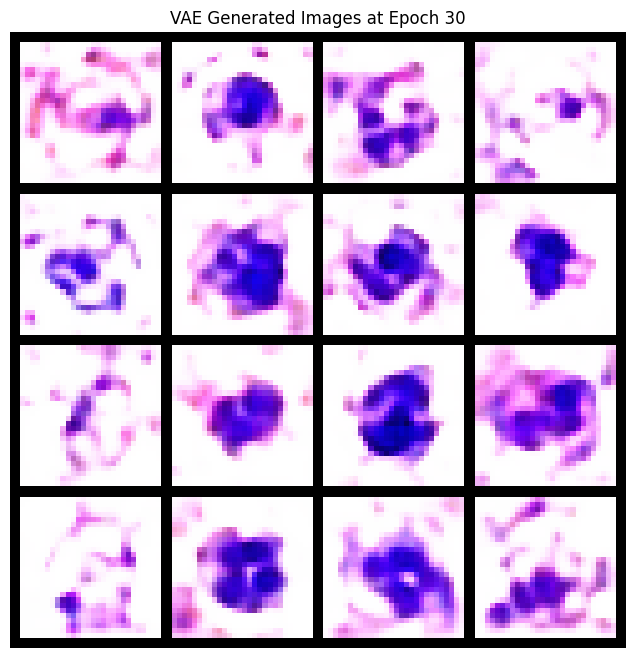

Epoch 30 FID: 158.3914
New best FID: 158.3914
Epoch [31/150] | Loss: 1039.7121 | Reconstruction: 1025.1508 | KLD: 145.6136
Epoch [32/150] | Loss: 1039.6381 | Reconstruction: 1025.0655 | KLD: 145.7260
Epoch [33/150] | Loss: 1039.8629 | Reconstruction: 1025.1385 | KLD: 147.2440
Epoch [34/150] | Loss: 1038.5621 | Reconstruction: 1023.9048 | KLD: 146.5729
Epoch [35/150] | Loss: 1038.1358 | Reconstruction: 1023.5515 | KLD: 145.8435


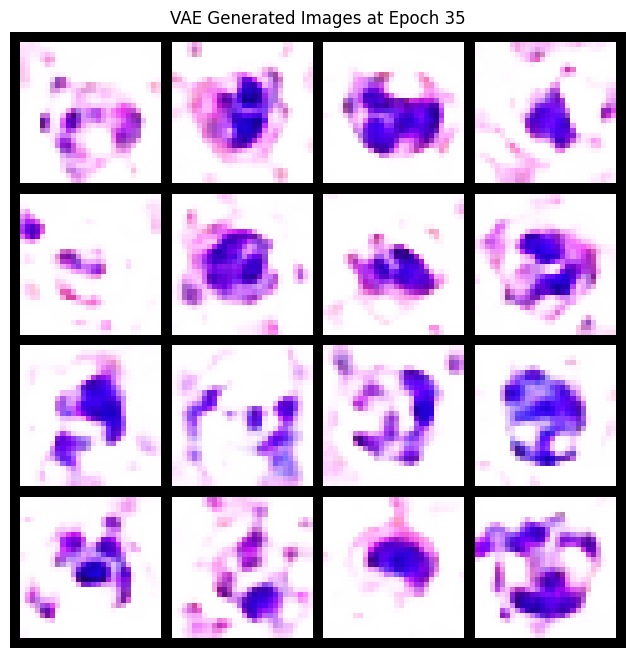

Epoch 35 FID: 158.9846
No improvement for 1 evaluations
Epoch [36/150] | Loss: 1038.2235 | Reconstruction: 1023.5628 | KLD: 146.6069
Epoch [37/150] | Loss: 1038.2213 | Reconstruction: 1023.4934 | KLD: 147.2788
Epoch [38/150] | Loss: 1036.9331 | Reconstruction: 1022.3329 | KLD: 146.0016
Epoch [39/150] | Loss: 1036.7796 | Reconstruction: 1022.1505 | KLD: 146.2913
Epoch [40/150] | Loss: 1036.5999 | Reconstruction: 1021.9853 | KLD: 146.1462


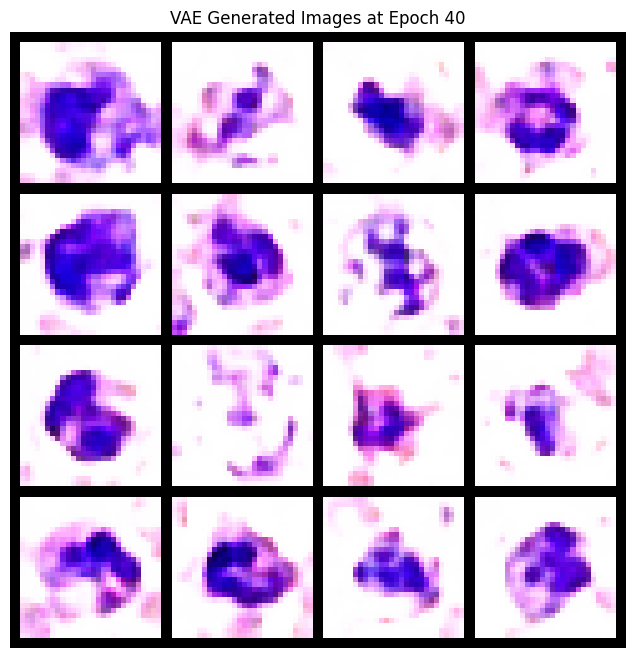

Epoch 40 FID: 157.7368
New best FID: 157.7368
Epoch [41/150] | Loss: 1036.2710 | Reconstruction: 1021.6245 | KLD: 146.4651
Epoch [42/150] | Loss: 1036.0651 | Reconstruction: 1021.4396 | KLD: 146.2545
Epoch [43/150] | Loss: 1035.7866 | Reconstruction: 1021.1347 | KLD: 146.5190
Epoch [44/150] | Loss: 1034.7556 | Reconstruction: 1020.1849 | KLD: 145.7076
Epoch [45/150] | Loss: 1034.9039 | Reconstruction: 1020.2562 | KLD: 146.4774


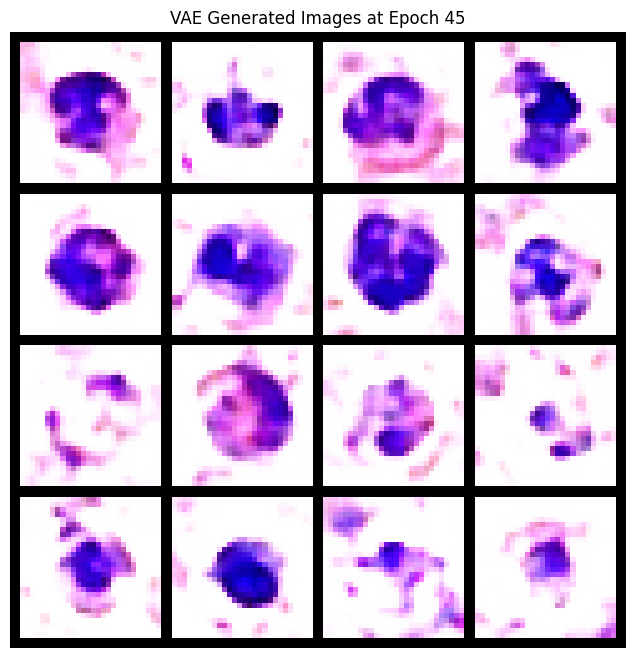

Epoch 45 FID: 157.7637
No improvement for 1 evaluations
Epoch [46/150] | Loss: 1034.7507 | Reconstruction: 1020.1152 | KLD: 146.3552
Epoch [47/150] | Loss: 1034.2734 | Reconstruction: 1019.6642 | KLD: 146.0916
Epoch [48/150] | Loss: 1033.9632 | Reconstruction: 1019.3802 | KLD: 145.8296
Epoch [49/150] | Loss: 1033.7916 | Reconstruction: 1019.1970 | KLD: 145.9460
Epoch [50/150] | Loss: 1033.4142 | Reconstruction: 1018.8232 | KLD: 145.9104


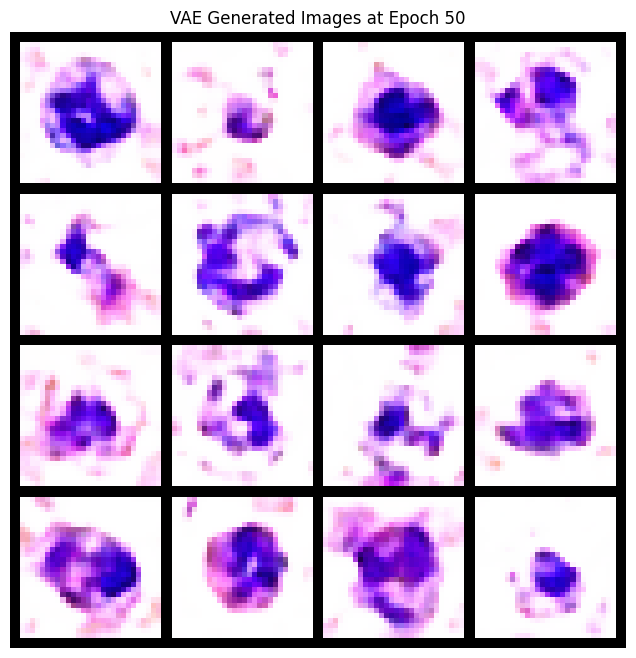

Epoch 50 FID: 157.6646
New best FID: 157.6646
Epoch [51/150] | Loss: 1033.2374 | Reconstruction: 1018.6450 | KLD: 145.9233
Epoch [52/150] | Loss: 1033.3510 | Reconstruction: 1018.7312 | KLD: 146.1984
Epoch [53/150] | Loss: 1033.1564 | Reconstruction: 1018.5490 | KLD: 146.0745
Epoch [54/150] | Loss: 1032.9487 | Reconstruction: 1018.3237 | KLD: 146.2495
Epoch [55/150] | Loss: 1032.4154 | Reconstruction: 1017.8563 | KLD: 145.5915


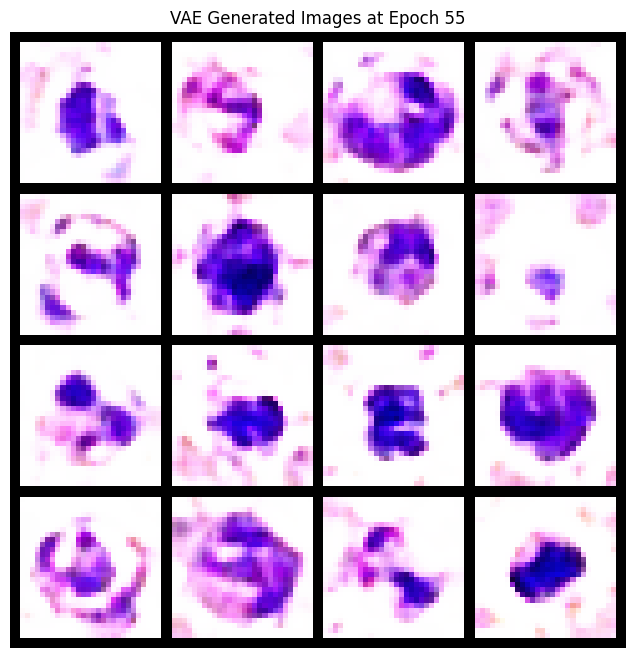

Epoch 55 FID: 158.5926
No improvement for 1 evaluations
Epoch [56/150] | Loss: 1032.7413 | Reconstruction: 1018.1512 | KLD: 145.9005
Epoch [57/150] | Loss: 1031.9383 | Reconstruction: 1017.3803 | KLD: 145.5803
Epoch [58/150] | Loss: 1031.4430 | Reconstruction: 1016.8744 | KLD: 145.6855
Epoch [59/150] | Loss: 1031.6352 | Reconstruction: 1017.0865 | KLD: 145.4871
Epoch [60/150] | Loss: 1031.7433 | Reconstruction: 1017.1597 | KLD: 145.8357


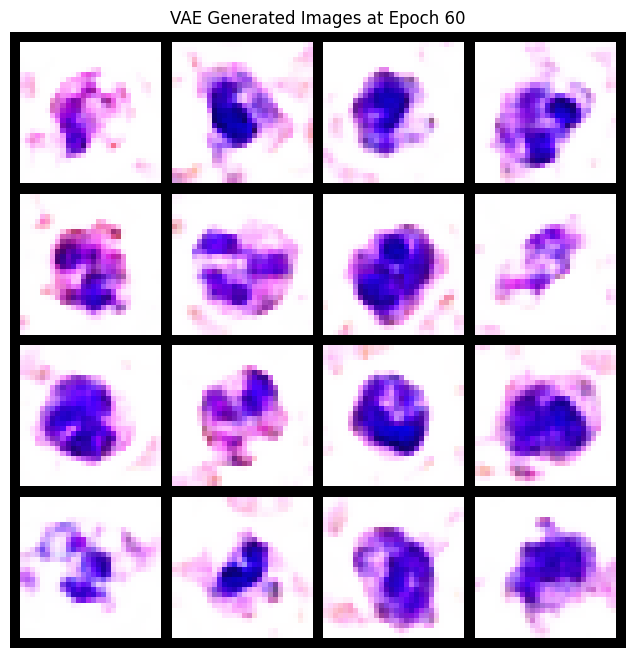

Epoch 60 FID: 159.0463
No improvement for 2 evaluations
Epoch [61/150] | Loss: 1031.2025 | Reconstruction: 1016.6391 | KLD: 145.6342
Epoch [62/150] | Loss: 1030.9348 | Reconstruction: 1016.4146 | KLD: 145.2025


KeyboardInterrupt: 

In [48]:
# Use the best hyperparameters and run multiple times with different seeds
best_vae_hyperparams = best_vae_result['hyperparams']
num_runs = 5
seeds = [42, 123, 456, 789, 1010]  # Different seeds for each run

vae_fid_scores = []
all_vae_models = []

print("\n=== Running Multiple Seeds for Best VAE Configuration ===")
for run_idx, seed in enumerate(seeds):
    print(f"\nRun {run_idx+1}/{num_runs} with seed {seed}")
    
    # Set seed
    set_seed(seed)
    
    # Sample real data for this run
    real_samples_run = sample_real_data(full_dataset, n_samples=10000, seed=seed)
    # Keep them on CPU
    real_samples_cpu = real_samples_run.clone()  # Ensure we have CPU tensors

    # Create DataLoader with CPU data and pin_memory=True
    train_loader_run = DataLoader(
        data.TensorDataset(real_samples_cpu, torch.zeros(len(real_samples_cpu))),
        batch_size=128,
        shuffle=True,
        num_workers=4,
        pin_memory=True if torch.cuda.is_available() else False
    )

    # Now move the samples to device for FID calculation (if needed)
    real_samples_run = real_samples_run.to(DEVICE)
    
    # Initialize model
    vae_model = FlexibleVAE(
        hidden_dims=best_vae_hyperparams['hidden_dims'],
        latent_dim=best_vae_hyperparams['latent_dim'],
        in_channels=n_channels
    ).to(DEVICE)
    
    # Train the model
    trained_vae, losses, recon_losses, kld_losses = train_vae(
        vae_model,
        train_loader_run,
        best_vae_hyperparams,
        DEVICE
    )
    
    # Evaluate model
    fid, fake_samples = evaluate_vae_model(trained_vae, real_samples_run, DEVICE)
    vae_fid_scores.append(fid)
    all_vae_models.append(trained_vae)
    
    # Save this run's model
    torch.save(trained_vae.state_dict(), f'bloodmnist_vae_seed{seed}.pth')
    
    print(f"FID Score for run {run_idx+1}: {fid:.4f}")
    
    # Visualize some generated samples
    with torch.no_grad():
        samples = trained_vae.sample(16, DEVICE)
        # Normalize images back to [0,1] for visualization
        samples_normalized = (samples + 1) / 2
        grid = make_grid(samples_normalized, nrow=4)
        plt.figure(figsize=(8, 8))
        plt.axis("off")
        plt.title(f"VAE Generated Images from Run {run_idx+1}")
        plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
        plt.show()

# Calculate mean and standard deviation of FID scores
mean_vae_fid = np.mean(vae_fid_scores)
std_vae_fid = np.std(vae_fid_scores)

print("\n=== Final VAE Results ===")
print(f"Mean FID Score across {num_runs} runs: {mean_vae_fid:.4f} ± {std_vae_fid:.4f}")
for i, fid in enumerate(vae_fid_scores):
    print(f"Run {i+1} (Seed {seeds[i]}): FID = {fid:.4f}")

### Comparação entre imagens reais e geradas pelo VAE

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4828431..1.82].


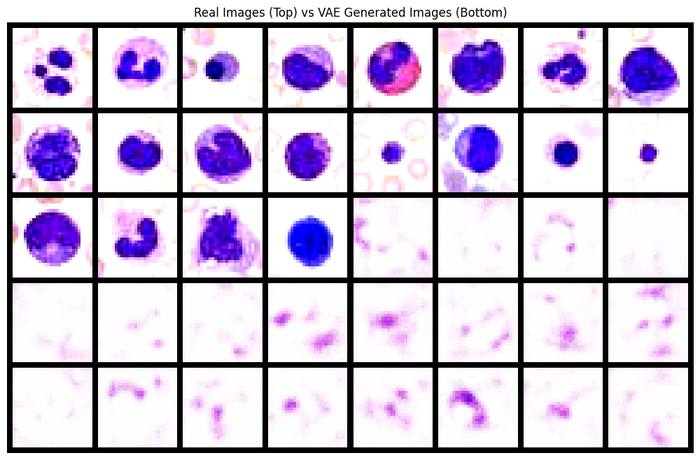

In [ ]:
# Get a batch of real images
real_batch = next(iter(DataLoader(data.TensorDataset(vae_real_samples[:40], torch.zeros(40)),
                                 batch_size=40, shuffle=True)))[0]

# Generate fake images using the best VAE
with torch.no_grad():
    fake_batch = best_vae.sample(40, DEVICE)

# Normalize both to [0,1] for visualization
real_normalized = (real_batch + 1) / 2
fake_normalized = (fake_batch + 1) / 2

# Create comparison grid - first 20 real, next 20 fake
comparison = torch.cat([real_normalized[:20], fake_normalized[:20]], dim=0)
grid = make_grid(comparison, nrow=8)

plt.figure(figsize=(15, 8))
plt.axis("off")
plt.title("Real Images (Top) vs VAE Generated Images (Bottom)")
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.show()

### Resumo e conclusão do VAE

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

# Restore the best hyperparameter configuration
best_vae_hyperparams = {
    'beta': 0.1,
    'beta_schedule': None,
    'epochs': 150,
    'hidden_dims': [512, 256],
    'latent_dim': 128,
    'learning_rate': 0.0003
}

# Previous FID scores (already computed)
previous_fid_scores = [
    151.0764,  # seed 42
    146.9143,  # seed 123
    150.4829,  # seed 456
    145.1109,  # seed 789
]

# Run the missing seed (1010)
seed = 1010
missing_run_idx = 4  # Index 4 corresponds to seed 1010 (5th run)

# Initialize result storage
vae_fid_scores = previous_fid_scores.copy()  # Start with previously obtained FIDs
all_vae_models = [None] * len(previous_fid_scores)  # Placeholders for trained models

print(f"\n=== Running missing seed {seed} ===")

# Set the random seed for reproducibility
set_seed(seed)

# Sample real data for this specific run
real_samples_run = sample_real_data(full_dataset, n_samples=10000, seed=seed)
real_samples_cpu = real_samples_run.clone()

# Create DataLoader for training
train_loader_run = DataLoader(
    data.TensorDataset(real_samples_cpu, torch.zeros(len(real_samples_cpu))),  # dummy labels
    batch_size=128,
    shuffle=True,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

# Move real samples to the device (GPU/CPU) for evaluation
real_samples_run = real_samples_run.to(DEVICE)

# Initialize the VAE model with the best hyperparameters
vae_model = FlexibleVAE(
    hidden_dims=best_vae_hyperparams['hidden_dims'],
    latent_dim=best_vae_hyperparams['latent_dim'],
    in_channels=n_channels
).to(DEVICE)

# Train the model
trained_vae, losses, recon_losses, kld_losses = train_vae(
    vae_model,
    train_loader_run,
    best_vae_hyperparams,
    DEVICE
)

# Evaluate model using FID
fid, fake_samples = evaluate_vae_model(trained_vae, real_samples_run, DEVICE)
vae_fid_scores.append(fid)
all_vae_models.append(trained_vae)

# Save the trained model
torch.save(trained_vae.state_dict(), f'bloodmnist_vae_seed{seed}.pth')

print(f"FID Score for seed {seed}: {fid:.4f}")

# Visualize some generated samples
with torch.no_grad():
    samples = trained_vae.sample(16, DEVICE)
    samples_normalized = (samples + 1) / 2  # Normalize to [0, 1]
    grid = make_grid(samples_normalized, nrow=4)
    plt.figure(figsize=(8, 8))
    plt.axis("off")
    plt.title(f"VAE Generated Images from Run 5 (Seed {seed})")
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.show()

# Compute mean and standard deviation of FID scores across all runs
seeds = [42, 123, 456, 789, 1010]  # All seeds used
mean_vae_fid = np.mean(vae_fid_scores)
std_vae_fid = np.std(vae_fid_scores)

print("\n=== Final VAE Results ===")
print(f"Mean FID across {len(seeds)} runs: {mean_vae_fid:.4f} ± {std_vae_fid:.4f}")
for i, fid in enumerate(vae_fid_scores):
    print(f"Run {i+1} (Seed {seeds[i]}): FID = {fid:.4f}")

# ----------------------------------
# Visualizations of FID across runs
# ----------------------------------
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(seeds)+1), vae_fid_scores, color='lightgreen', alpha=0.7)
plt.axhline(y=mean_vae_fid, color='g', linestyle='-', label=f'Mean FID: {mean_vae_fid:.4f}')
plt.fill_between(
    [0.5, len(seeds)+0.5],
    [mean_vae_fid - std_vae_fid, mean_vae_fid - std_vae_fid],
    [mean_vae_fid + std_vae_fid, mean_vae_fid + std_vae_fid],
    color='g', alpha=0.2,
    label=f'Std Dev: {std_vae_fid:.4f}'
)
plt.xlabel('Run (Seed)')
plt.ylabel('FID Score (lower is better)')
plt.title('VAE FID Scores Across Multiple Runs with Different Seeds')
plt.xticks(range(1, len(seeds)+1), [f'{i}\n(Seed {seed})' for i, seed in enumerate(seeds, 1)])
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------------
# Load best model if it's not the current one
# ----------------------------------
best_run_idx = np.argmin(vae_fid_scores)
best_vae = trained_vae  # Use current model as fallback

if best_run_idx != missing_run_idx:
    best_seed = seeds[best_run_idx]
    print(f"Loading best model (seed {best_seed})...")
    best_vae = FlexibleVAE(
        hidden_dims=best_vae_hyperparams['hidden_dims'],
        latent_dim=best_vae_hyperparams['latent_dim'],
        in_channels=n_channels
    ).to(DEVICE)
    best_vae.load_state_dict(torch.load(f'bloodmnist_vae_seed{best_seed}.pth'))

# Visualize a 5x8 grid of generated images from the best model
with torch.no_grad():
    samples = best_vae.sample(40, DEVICE)
    samples_normalized = (samples + 1) / 2
    grid = make_grid(samples_normalized, nrow=8)

    plt.figure(figsize=(15, 8))
    plt.axis("off")
    plt.title(f"VAE Generated BloodMNIST Images from Best Run (FID: {vae_fid_scores[best_run_idx]:.4f})")
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.show()

# ----------------------------------
# Compare real vs generated images
# ----------------------------------

# Get a batch of real images
real_batch = next(iter(DataLoader(data.TensorDataset(
    sample_real_data(full_dataset, n_samples=40, seed=best_seed).to(DEVICE),
    torch.zeros(40)),
    batch_size=40, shuffle=True)))[0]

# Generate fake images using the best VAE
with torch.no_grad():
    fake_batch = best_vae.sample(40, DEVICE)

# Normalize both sets to [0, 1] for visualization
real_normalized = (real_batch + 1) / 2
fake_normalized = (fake_batch + 1) / 2

# Create comparison grid: top 20 real, bottom 20 fake
comparison = torch.cat([real_normalized[:20], fake_normalized[:20]], dim=0)
grid = make_grid(comparison, nrow=8)

plt.figure(figsize=(15, 8))
plt.axis("off")
plt.title("Real Images (Top) vs VAE Generated Images (Bottom)")
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.show()

# ----------------------------------
# Summary of the VAE experiment
# ----------------------------------
print("=== VAE for BloodMNIST - Summary ===")
print(f"\nBest Hyperparameter Configuration:")
for param, value in best_vae_hyperparams.items():
    print(f"- {param}: {value}")

print(f"\nFID Evaluation:")
print(f"- Best FID: {min(vae_fid_scores):.4f} (Run {np.argmin(vae_fid_scores)+1}, Seed {seeds[np.argmin(vae_fid_scores)]})")
print(f"- Mean FID: {mean_vae_fid:.4f}")
print(f"- FID Std Dev: {std_vae_fid:.4f}")

print("\nVAE Model Architecture:")
print("- Total Parameters:", sum(p.numel() for p in best_vae.parameters()))

=== VAE for BloodMNIST - Summary ===

Best Hyperparameter Configuration::
- beta: 0.1
- beta_schedule: None
- epochs: 150
- hidden_dims: [512, 256]
- latent_dim: 128
- learning_rate: 0.0003

FID Evaluation:
- Best FID: 145.1109 (Run 4, Seed 789)
- Mean FID: 148.0842
- FID Std Dev: 2.3010

VAE Model Architecture:
- Total Parameters: 12333827

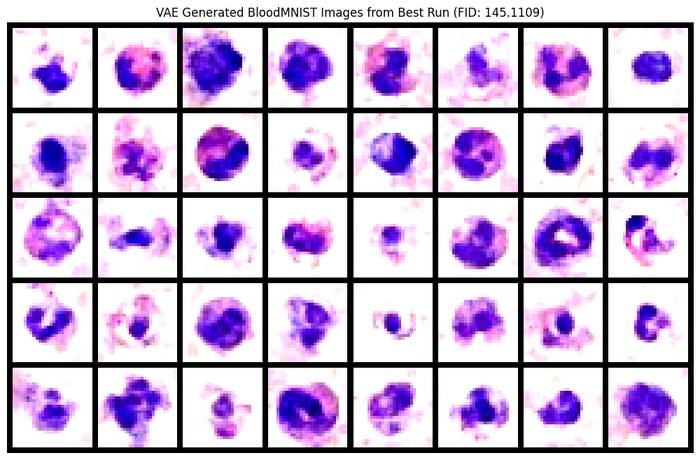

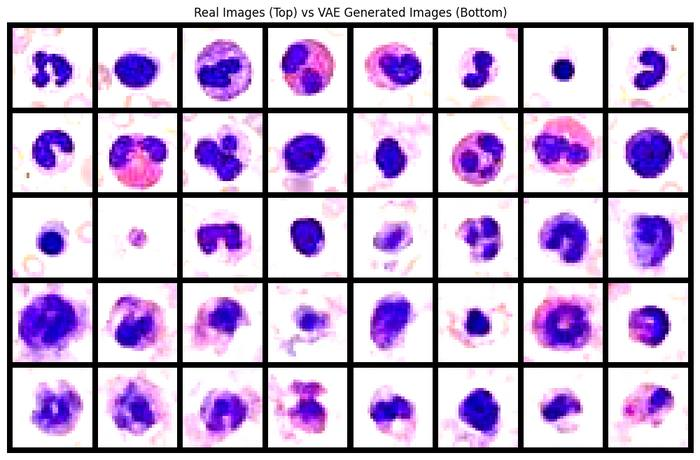